<div style="background:#1F3864;padding:28px 30px;border-radius:10px;margin-bottom:10px">
<h1 style="color:white;font-family:Arial;margin:0">📊 Proyecto de Minería de Datos</h1>
<h2 style="color:#FFC000;font-family:Arial;margin:6px 0 0 0">BIY7121 – Guía para Estudiantes</h2>
<p style="color:#D6E4F0;font-family:Arial;margin:10px 0 0 0;font-size:15px">Examen Transversal Semestral · Metodología CRISP-DM · DuocUC</p>
</div>

---

## 📋 Información General

| Campo | Detalle |
|---|---|
| **Asignatura** | BIY7121 – Minería de Datos |
| **Modalidad** | Trabajo grupal (hasta 3 integrantes) |
| **Ponderación** | 3 entregables de Etapa 1: 35%, Etapa 2: 35%, Etapa 3: 30%|


---

## 🗺═ Metodología CRISP-DM

Este proyecto sigue la metodología **CRISP-DM** *(Cross Industry Standard Process for Data Mining)*,
que organiza el trabajo en seis fases cíclicas:

```
  1. Comprensión del Negocio  →  2. Comprensión de los Datos
         ↑                                    ↓
  6. Despliegue               ═  3. Preparación de los Datos
         ↑                                    ↓
  5. Evaluación               ═  4. Modelado
```

> **¿Por qué CRISP-DM?** Porque estructura el pensamiento analítico de manera iterativa,
> permitiendo volver a fases anteriores cuando los hallazgos lo requieran.

---

## 📦 Estructura de este Notebook

| Etapa | Contenido | Evaluación | Ponderación
|---|---|---|--|
| **ETAPA 1** | Comprensión del negocio + EDA completo | IL 1.1, IL 1.2, IL 2.1 | 35%|
| **ETAPA 2** | Selección, justificación y aplicación de modelos | IL 2.2, IL 3.2 | 30%|
| **ETAPA 3** | Evaluación, modelo ganador, predicción con datos nuevos | IL 3.2, IL 3.5 | 30%|



---
## ⚙️ Configuración del Entorno

Ejecuta esta celda **una sola vez** para instalar las dependencias necesarias.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder
print("Configuración de entorno terminada!.")

Configuración de entorno terminada!.



<div style="background:#1F3864;padding:18px 24px;border-radius:8px">
<h1 style="color:white;font-family:Arial;margin:0">═ ETAPA 1</h1>
<h2 style="color:#FFC000;font-family:Arial;margin:4px 0 0 0">Comprensión del Negocio & Análisis Exploratorio de Datos (EDA)</h2>
<p style="color:#D6E4F0;font-family:Arial;margin:8px 0 0 0">CRISP-DM Fases 1 y 2: Comprensión del Negocio · Comprensión de los Datos · Preparación</p>
</div>

---

**Indicadores evaluados:** IL 1.1 · IL 1.2 · IL 2.1

**Ponderación:** 30% (IL 1.1: 15% + IL 1.2: 15%)


## 1.1 CRISP-DM Fase 1 — Comprensión del Negocio

> Esta fase responde a las preguntas: **¿Para qué organización trabajamos?
> ¿Cuál es el problema de negocio? ¿Qué decisión queremos apoyar?**

### ═ Instrucciones
Completa las siguientes secciones basándote en el caso asignado por tu docente.
Consulta el enunciado del Examen Transversal para obtener el contexto organizacional.


### 1.1.1 Descripción del Contexto Organizacional

*Redacta aquí un resumen del contexto del caso asignado.*
*Incluye: país/organización, sector, problemática principal y por qué los datos son relevantes.*

```
- Organización / Institución: Instituo Profesional Duoc UC.
- Sector / Industria: Ingenieria Informática.
- País o región: Santiago, Chile.
- Problema principal identificado: El problema principal consiste en predecir y caracterizar los factores que determinan la severidad de los accidentes viales mediante el análisis de datos históricos, con el fin de mitigar el impacto económico de £35.000 millones y reducir la alta mortalidad en zonas rurales.
- Decisión estratégica que se busca apoyar: La táctica más adecuada es poner en práctica un modelo de clasificación supervisada (tal como Random Forest o XGBoost) que se enfoque en detectar patrones en accidentes fatales y graves, empleando métodos de equilibrado de datos para compensar la falta de registros muy severos. Esto debe ser acompañado de un estudio sobre la relevancia de variables que explique por qué las áreas rurales son más propensas a ser vulnerables, lo cual posibilita la conversión de los resultados en sugerencias que se puedan aplicar, como mejorar el tiempo de reacción ante emergencias y poner en marcha sistemas inteligentes para controlar la velocidad en tramos críticos.
```


### 1.1.2 Objetivo del Proyecto de Minería de Datos

*Define el objetivo en términos de minería de datos (no solo del negocio).*

```
Objetivo de negocio: Disminuir el impacto económico de 35.000 millones de libras y la tasa de mortalidad a través del mejoramiento de la seguridad vial. El objetivo es encontrar factores clave que permitan optimizar la infraestructura rural y acelerar la respuesta de emergencia en áreas de riesgo. El objetivo final es proteger vidas y reducir los gastos por daños a la propiedad y la baja productividad del país.
Objetivo de minería de datos: Crear un modelo predictivo que, tomando en cuenta los factores geográficos, temporales y ambientales del incidente, pueda establecer la gravedad de un accidente. El modelo tiene que identificar patrones que permitan comprender los motivos por los cuales algunos factores incrementan la posibilidad de obtener resultados graves o fatales. Además, se intenta determinar la relevancia de cada variable para que las intervenciones en los puntos de mayor riesgo sean priorizadas.
Variable objetivo (target): Accident_Severity es la variable fundamental, ya que clasifica la severidad de cada accidente documentado en la base de datos del Departamento de Transporte. Esta se clasifica en tres categorías o niveles jerárquicos: 1 para accidentes mortales, 2 para accidentes serios y 3 para accidentes leves. Como es una etiqueta ya establecida, facilita la orientación del entrenamiento del algoritmo para distinguir un impacto menor de uno letal.
Tipo de problema (clasificación / regresión / clustering / otro): Es un problema de clasificación supervisada, porque el algoritmo tiene que clasificar cada evento en una de las tres categorías de gravedad preestablecidas. El enfoque necesita técnicas de ajuste para no pasar por alto los casos fatales, ya que las clases suelen estar desbalanceadas. Es un análisis multiclase en el que la precisión en las categorías con más riesgo es crucial para la utilidad efectiva del modelo.
```

---

<div style="background:#FFF3CD;border-left:5px solid #FFC000;padding:12px 16px;border-radius:4px">
<b>🤔 Preguntas de Reflexión – Comprensión del Negocio</b><br>
<ol>
<li>¿Cuál es el costo de un error de predicción en este contexto? ¿Es igual equivocarse en ambas direcciones?</li>
<li>¿Qué tipo de usuario tomará decisiones con este modelo? ¿Qué nivel de explicabilidad necesita?</li>
<li>¿Existen restricciones éticas, legales o de privacidad en el uso de estos datos?</li>
<li>¿Qué conocimiento del dominio deberías incorporar antes de modelar?</li>
</ol>
</div>


## 1.2 CRISP-DM Fase 2 — Comprensión de los Datos

### 1.2.1 Carga del Dataset

Carga el archivo CSV del caso asignado. Ajusta la ruta según corresponda.


In [ ]:
### hay que descomentar esto si se va a ejecutar en colab, se usó de manera local, por lo que se dejó comentado
#from google.colab import drive
#drive.mount('/content/drive')


Ruta_Accident_Information = 'C:/Users/nesto/Downloads/MINERIA DE DATOS-20260620T024057Z-3-001/MINERIA DE DATOS/CASO SEMESTRAL/Caso Semestral/caso1/Accident_Information.csv'
Ruta_Vehicle_Information = 'C:/Users/nesto/Downloads/MINERIA DE DATOS-20260620T024057Z-3-001/MINERIA DE DATOS/CASO SEMESTRAL/Caso Semestral/caso1/Vehicle_Information.csv'

df_ai = pd.read_csv(Ruta_Accident_Information)
#indexar por ID Accident_Index
df_ai.set_index('Accident_Index', inplace=True)

df_vi = pd.read_csv(Ruta_Vehicle_Information, encoding='latin1')
#indexar por ID Accident_Index
df_vi.set_index('Accident_Index', inplace=True)

C:\Users\nesto\AppData\Local\Temp\ipykernel_15012\348981820.py:9: DtypeWarning: Columns (0: Accident_Index) have mixed types. Specify dtype option on import or set low_memory=False.
  df_ai = pd.read_csv(Ruta_Accident_Information)


### 1.2.2 Inventario Inicial del Dataset

> Esta sección permite conocer la estructura, tipos de datos y calidad inicial del dataset.


In [ ]:
print("Accident Information")
df_ai.info()
display(df_ai)
print("Vehicle Information")
df_vi.info()
display(df_vi)

Accident Information
<class 'pandas.DataFrame'>
Index: 2047256 entries, 200501BS00001 to 2017984122617
Data columns (total 33 columns):
 #   Column                                       Dtype  
---  ------                                       -----  
 0   1st_Road_Class                               str    
 1   1st_Road_Number                              float64
 2   2nd_Road_Class                               str    
 3   2nd_Road_Number                              float64
 4   Accident_Severity                            str    
 5   Carriageway_Hazards                          str    
 6   Date                                         str    
 7   Day_of_Week                                  str    
 8   Did_Police_Officer_Attend_Scene_of_Accident  float64
 9   Junction_Control                             str    
 10  Junction_Detail                              str    
 11  Latitude                                     float64
 12  Light_Conditions                             st

,1st_Road_Class,1st_Road_Number,2nd_Road_Class,2nd_Road_Number,Accident_Severity,Carriageway_Hazards,Date,Day_of_Week,Did_Police_Officer_Attend_Scene_of_Accident,Junction_Control,...,Police_Force,Road_Surface_Conditions,Road_Type,Special_Conditions_at_Site,Speed_limit,Time,Urban_or_Rural_Area,Weather_Conditions,Year,InScotland
Accident_Index,,,,,,,,,,,,,,,,,,,,,
200501BS00001,A,3218.0,NaN,0.0,Serious,NaN,2005-01-04,Tuesday,1.0,Data missing or out of range,...,Metropolitan Police,Wet or damp,Single carriageway,NaN,30.0,17:42,Urban,Raining no high winds,2005,No
200501BS00002,B,450.0,C,0.0,Slight,NaN,2005-01-05,Wednesday,1.0,Auto traffic signal,...,Metropolitan Police,Dry,Dual carriageway,NaN,30.0,17:36,Urban,Fine no high winds,2005,No
200501BS00003,C,0.0,NaN,0.0,Slight,NaN,2005-01-06,Thursday,1.0,Data missing or out of range,...,Metropolitan Police,Dry,Single carriageway,NaN,30.0,00:15,Urban,Fine no high winds,2005,No
200501BS00004,A,3220.0,NaN,0.0,Slight,NaN,2005-01-07,Friday,1.0,Data missing or out of range,...,Metropolitan Police,Dry,Single carriageway,NaN,30.0,10:35,Urban,Fine no high winds,2005,No
200501BS00005,Unclassified,0.0,NaN,0.0,Slight,NaN,2005-01-10,Monday,1.0,Data missing or out of range,...,Metropolitan Police,Wet or damp,Single carriageway,NaN,30.0,21:13,Urban,Fine no high winds,2005,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017984121017,A(M),74.0,NaN,0.0,Slight,NaN,2017-12-17,Sunday,1.0,Data missing or out of range,...,Dumfries and Galloway,Frost or ice,Dual carriageway,NaN,70.0,11:30,Rural,Other,2017,Yes
2017984121217,C,69.0,NaN,0.0,Slight,Pedestrian in carriageway - not injured,2017-12-15,Friday,2.0,Data missing or out of range,...,Dumfries and Galloway,Dry,Single carriageway,NaN,20.0,13:00,Urban,Fine no high winds,2017,Yes
2017984121717,A(M),74.0,Unclassified,0.0,Slight,NaN,2017-12-18,Monday,1.0,Give way or uncontrolled,...,Dumfries and Galloway,Wet or damp,Dual carriageway,NaN,70.0,13:30,Rural,Fine no high winds,2017,Yes


Vehicle Information
<class 'pandas.DataFrame'>
Index: 2177205 entries, 200401BS00001 to 2016984133416
Data columns (total 23 columns):
 #   Column                            Dtype  
---  ------                            -----  
 0   Age_Band_of_Driver                str    
 1   Age_of_Vehicle                    float64
 2   Driver_Home_Area_Type             str    
 3   Driver_IMD_Decile                 float64
 4   Engine_Capacity_.CC.              float64
 5   Hit_Object_in_Carriageway         str    
 6   Hit_Object_off_Carriageway        str    
 7   Journey_Purpose_of_Driver         str    
 8   Junction_Location                 str    
 9   make                              str    
 10  model                             str    
 11  Propulsion_Code                   str    
 12  Sex_of_Driver                     str    
 13  Skidding_and_Overturning          str    
 14  Towing_and_Articulation           str    
 15  Vehicle_Leaving_Carriageway       str    
 16  Vehicle_Locati

,Age_Band_of_Driver,Age_of_Vehicle,Driver_Home_Area_Type,Driver_IMD_Decile,Engine_Capacity_.CC.,Hit_Object_in_Carriageway,Hit_Object_off_Carriageway,Journey_Purpose_of_Driver,Junction_Location,make,...,Skidding_and_Overturning,Towing_and_Articulation,Vehicle_Leaving_Carriageway,Vehicle_Location.Restricted_Lane,Vehicle_Manoeuvre,Vehicle_Reference,Vehicle_Type,Was_Vehicle_Left_Hand_Drive,X1st_Point_of_Impact,Year
Accident_Index,,,,,,,,,,,,,,,,,,,,,
200401BS00001,26 - 35,3.0,Urban area,4.0,1588.0,NaN,NaN,Data missing or out of range,Data missing or out of range,ROVER,...,NaN,No tow/articulation,Did not leave carriageway,0.0,Going ahead other,2,109,Data missing or out of range,Front,2004
200401BS00002,26 - 35,NaN,Urban area,3.0,NaN,NaN,NaN,Data missing or out of range,Data missing or out of range,BMW,...,NaN,No tow/articulation,Did not leave carriageway,0.0,Going ahead other,1,109,Data missing or out of range,Front,2004
200401BS00003,26 - 35,4.0,Data missing or out of range,NaN,998.0,NaN,NaN,Data missing or out of range,Data missing or out of range,NISSAN,...,NaN,No tow/articulation,Did not leave carriageway,0.0,Turning right,1,109,Data missing or out of range,Front,2004
200401BS00003,66 - 75,NaN,Data missing or out of range,NaN,NaN,NaN,NaN,Data missing or out of range,Data missing or out of range,LONDON TAXIS INT,...,NaN,No tow/articulation,Did not leave carriageway,0.0,Going ahead other,2,109,Data missing or out of range,Front,2004
200401BS00004,26 - 35,1.0,Urban area,4.0,124.0,NaN,NaN,Data missing or out of range,Data missing or out of range,PIAGGIO,...,NaN,No tow/articulation,Did not leave carriageway,0.0,Going ahead other,1,Motorcycle 125cc and under,Data missing or out of range,Front,2004
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016984131116,21 - 25,14.0,Urban area,NaN,1598.0,NaN,NaN,Not known,Mid Junction - on roundabout or on main road,MINI,...,NaN,No tow/articulation,Did not leave carriageway,0.0,Going ahead other,1,Car,No,Front,2016
2016984131116,56 - 65,NaN,Small town,NaN,1598.0,NaN,NaN,Commuting to/from work,Mid Junction - on roundabout or on main road,VAUXHALL,...,NaN,No tow/articulation,Offside,0.0,Going ahead other,2,Car,No,Front,2016
2016984131216,56 - 65,NaN,Urban area,3.0,NaN,NaN,Central crash barrier,Journey as part of work,Not at or within 20 metres of junction,NaN,...,NaN,No tow/articulation,Offside on to central reservation,0.0,Going ahead other,1,Goods 7.5 tonnes mgw and over,No,Offside,2016


In [ ]:
print("Accident Information")
#df_ai.info()
#display(df_ai)
df_ai_na = pd.DataFrame({'NA': df_ai.isna().sum(), 'Total': len(df_ai), 'Porcentaje': (df_ai.isna().sum() / len(df_ai) * 100).round(2)})
display(df_ai_na)
print("Vehicle Information")
#df_vi.info()
#display(df_vi)
df_vi_na = pd.DataFrame({'NA': df_vi.isna().sum(), 'Total': len(df_vi), 'Porcentaje': (df_vi.isna().sum() / len(df_vi) * 100).round(2)})
display(df_vi_na)

Accident Information


,NA,Total,Porcentaje
1st_Road_Class,0,2047256,0.00
1st_Road_Number,2,2047256,0.00
2nd_Road_Class,844272,2047256,41.24
2nd_Road_Number,17593,2047256,0.86
Accident_Severity,0,2047256,0.00
Carriageway_Hazards,2007807,2047256,98.07
Date,0,2047256,0.00
Day_of_Week,0,2047256,0.00
Did_Police_Officer_Attend_Scene_of_Accident,278,2047256,0.01
Junction_Control,0,2047256,0.00


Vehicle Information


,NA,Total,Porcentaje
Age_Band_of_Driver,0,2177205,0.00
Age_of_Vehicle,358149,2177205,16.45
Driver_Home_Area_Type,0,2177205,0.00
Driver_IMD_Decile,734812,2177205,33.75
Engine_Capacity_.CC.,265861,2177205,12.21
Hit_Object_in_Carriageway,2087824,2177205,95.89
Hit_Object_off_Carriageway,1989741,2177205,91.39
Journey_Purpose_of_Driver,0,2177205,0.00
Junction_Location,0,2177205,0.00
make,110845,2177205,5.09


<div style="background:#FFF3CD;border-left:5px solid #FFC000;padding:12px 16px;border-radius:4px">
<b>🤔 Preguntas de Reflexión – Inventario de Datos</b><br>
<ol>
<li>¿El número de filas es suficiente para entrenar un modelo confiable? ¿Qué mínimo esperarías?</li>
<li>¿Hay columnas con tipos de datos incorrectos (por ejemplo, fechas guardadas como texto)?</li>
<li>¿Los rangos de las variables numéricas tienen sentido desde el dominio del negocio?</li>
<li>¿Cuántas variables son numéricas continuas, cuántas categóricas y cuántas binarias?</li>
</ol>
</div>


In [ ]:

# ─── Análisis de Tipos de Datos ─────────────────────────────────────────────
print("=" * 60)
print("TIPOS DE DATOS — Accident Information")
print("=" * 60)
print(df_ai.dtypes.to_string())

print("\n" + "=" * 60)
print("TIPOS DE DATOS — Vehicle Information")
print("=" * 60)
print(df_vi.dtypes.to_string())

# ─── Detección de columnas temporales mal tipadas ───────────────────────────
print("\n" + "=" * 60)
print("COLUMNAS 'object' — verificar si son fechas/horas mal tipadas")
print("=" * 60)
for col in ['Date', 'Time']:
    if col in df_ai.columns:
        print(f"  df_ai['{col}'] | dtype: {df_ai[col].dtype} | ejemplo: {df_ai[col].dropna().iloc[0]}")

# ─── Corrección de tipos ─────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("CORRECCIÓN DE TIPOS")
print("=" * 60)

# Date: "DD/MM/YYYY" almacenada como object → convertir a datetime
if 'Date' in df_ai.columns and df_ai['Date'].dtype == 'object':
    df_ai['Date'] = pd.to_datetime(df_ai['Date'], dayfirst=True, errors='coerce')
    print(f"✅ 'Date' convertida → {df_ai['Date'].dtype}")

# Time: "HH:MM" almacenada como object → extraer hora como entero
if 'Time' in df_ai.columns and df_ai['Time'].dtype == 'object':
    df_ai['Hour'] = pd.to_datetime(df_ai['Time'], format='%H:%M', errors='coerce').dt.hour
    print(f"✅ 'Time' → nueva columna 'Hour' (int) | muestra: {df_ai['Hour'].dropna().head(5).values}")

print("\nVerificación dtypes corregidos:")
cols_check = [c for c in ['Date', 'Time', 'Hour'] if c in df_ai.columns]
print(df_ai[cols_check].dtypes)


TIPOS DE DATOS — Accident Information
1st_Road_Class                                     str
1st_Road_Number                                float64
2nd_Road_Class                                     str
2nd_Road_Number                                float64
Accident_Severity                                  str
Carriageway_Hazards                                str
Date                                               str
Day_of_Week                                        str
Did_Police_Officer_Attend_Scene_of_Accident    float64
Junction_Control                                   str
Junction_Detail                                    str
Latitude                                       float64
Light_Conditions                                   str
Local_Authority_(District)                         str
Local_Authority_(Highway)                          str
Location_Easting_OSGR                          float64
Location_Northing_OSGR                         float64
Longitude                  

In [ ]:

# ═══════════════════════════════════════════════════════════════
# 1.2.2b — Validación de rangos de variables numéricas
#           ¿Los valores tienen sentido según el dominio del negocio?
# ═══════════════════════════════════════════════════════════════

num_cols_ai = df_ai.select_dtypes(include='number').columns.tolist()

print("=" * 70)
print("ESTADÍSTICAS DESCRIPTIVAS — Variables numéricas (Accident Information)")
print("=" * 70)
display(df_ai[num_cols_ai].describe().T.round(2))

# ─── Validación por variable según dominio UK ───────────────────────────────
print("\n" + "=" * 70)
print("VALIDACIÓN DE RANGOS — dominio del negocio (UK Road Safety)")
print("=" * 70)

# Speed_limit: límites legales en UK son 20, 30, 40, 50, 60, 70 mph
valid_speeds = {20, 30, 40, 50, 60, 70}
if 'Speed_limit' in df_ai.columns:
    fuera = df_ai[~df_ai['Speed_limit'].isin(valid_speeds) & df_ai['Speed_limit'].notna()]
    status = "OK" if len(fuera) == 0 else f"{len(fuera)} registros fuera de rango"
    print(f"Speed_limit          | min={df_ai['Speed_limit'].min():>3}  max={df_ai['Speed_limit'].max():>3} mph "
          f"| válidos UK: {sorted(valid_speeds)} | {status}")

# Number_of_Vehicles: debe ser >= 1 (al menos 1 vehículo por accidente)
if 'Number_of_Vehicles' in df_ai.columns:
    neg = (df_ai['Number_of_Vehicles'] < 1).sum()
    status = "OK" if neg == 0 else f"{neg} valores < 1"
    print(f"Number_of_Vehicles   | min={df_ai['Number_of_Vehicles'].min():>4}  max={df_ai['Number_of_Vehicles'].max():>4}     "
          f"| esperado: >= 1    | {status}")

# Number_of_Casualties: debe ser >= 1 (si hay accidente, al menos 1 víctima)
if 'Number_of_Casualties' in df_ai.columns:
    cero = (df_ai['Number_of_Casualties'] < 1).sum()
    status = "OK" if cero == 0 else f"{cero} valores < 1"
    print(f"Number_of_Casualties | min={df_ai['Number_of_Casualties'].min():>4}  max={df_ai['Number_of_Casualties'].max():>4}     "
          f"| esperado: >= 1    | {status}")

# Accident_Severity: sólo 1=Fatal, 2=Grave, 3=Leve
if 'Accident_Severity' in df_ai.columns:
    uniq = sorted(df_ai['Accident_Severity'].dropna().unique().tolist())
    valid_severity = {1, 2, 3, 'Fatal', 'Serious', 'Slight'}
    inv = (~df_ai['Accident_Severity'].isin(valid_severity)).sum()
    uniq = str(uniq)
    status = "OK" if inv == 0 else f"{inv} inválidos"
    print(f"Accident_Severity    | valores únicos: {uniq:<20} | esperado: [1,2,3] | {status}")

# Urban_or_Rural_Area: sólo 1=Urbano, 2=Rural
if 'Urban_or_Rural_Area' in df_ai.columns:
    inv = (~df_ai['Urban_or_Rural_Area'].isin([1, 2])).sum()
    uniq = sorted(df_ai['Urban_or_Rural_Area'].dropna().unique().tolist())
    status = "OK" if inv == 0 else f"{inv} inválidos"
    print(f"Urban_or_Rural_Area  | valores únicos: {str(uniq):<20} | esperado: [1,2]   | {status}")

# Hour (derivada de Time): debe estar entre 0 y 23
if 'Hour' in df_ai.columns:
    inv = ((df_ai['Hour'] < 0) | (df_ai['Hour'] > 23)).sum()
    status = "OK" if inv == 0 else f"{inv} fuera de [0-23]"
    print(f"Hour (derivada)      | min={df_ai['Hour'].min():>4}  max={df_ai['Hour'].max():>4}     "
          f"| esperado: 0-23    | {status}")

# Day_of_Week: debe ser 1-7 (1=Domingo, 7=Sábado)
if 'Day_of_Week' in df_ai.columns:
    inv = (~df_ai['Day_of_Week'].isin(range(1, 8))).sum()
    uniq = sorted(df_ai['Day_of_Week'].dropna().unique().tolist())
    status = "OK" if inv == 0 else f"{inv} inválidos"
    print(f"Day_of_Week          | valores únicos: {str(uniq):<20} | esperado: [1-7]   | {status}")

# ─── Distribución de la variable objetivo ───────────────────────────────────
print("\n" + "=" * 70)
print("DISTRIBUCIÓN — Accident_Severity (variable objetivo)")
print("=" * 70)
if 'Accident_Severity' in df_ai.columns:
    dist = df_ai['Accident_Severity'].value_counts().sort_index()
    labels = {1: "Fatal", 2: "Grave", 3: "Leve"}
    for val, count in dist.items():
        pct = count / len(df_ai) * 100
        bar = "#" * int(pct / 2)
        print(f"  Clase {val} ({labels.get(val,'?'):5s}): {count:>7,d}  ({pct:5.1f}%)  {bar}")
    print(f"\n  Desbalance severo: clase 3 (Leve) domina. Se requerirá SMOTE/class_weight.")


ESTADÍSTICAS DESCRIPTIVAS — Variables numéricas (Accident Information)


,count,mean,std,min,25%,50%,75%,max
1st_Road_Number,2047254.0,992.11,1809.41,0.00,0.00,118.00,702.00,9999.00
2nd_Road_Number,2029663.0,372.82,1287.80,0.00,0.00,0.00,0.00,9999.00
Did_Police_Officer_Attend_Scene_of_Accident,2046978.0,1.20,0.41,1.00,1.00,1.00,1.00,3.00
Latitude,2047082.0,52.56,1.45,49.91,51.49,52.24,53.46,60.76
Location_Easting_OSGR,2047092.0,441446.21,95496.20,64950.00,378063.50,443050.00,524298.25,655540.00
Location_Northing_OSGR,2047092.0,296885.47,160527.26,10290.00,177756.75,261183.50,395610.00,1208800.00
Longitude,2047081.0,-1.41,1.40,-7.52,-2.33,-1.36,-0.21,1.76
Number_of_Casualties,2047256.0,1.35,0.82,1.00,1.00,1.00,1.00,93.00
Number_of_Vehicles,2047256.0,1.83,0.72,1.00,1.00,2.00,2.00,67.00
Pedestrian_Crossing-Human_Control,2044336.0,0.01,0.14,0.00,0.00,0.00,0.00,2.00



VALIDACIÓN DE RANGOS — dominio del negocio (UK Road Safety)
Speed_limit          | min=0.0  max=70.0 mph | válidos UK: [20, 30, 40, 50, 60, 70] | 36 registros fuera de rango
Number_of_Vehicles   | min=   1  max=  67     | esperado: >= 1    | OK
Number_of_Casualties | min=   1  max=  93     | esperado: >= 1    | OK
Accident_Severity    | valores únicos: ['Fatal', 'Serious', 'Slight'] | esperado: [1,2,3] | OK
Urban_or_Rural_Area  | valores únicos: ['Rural', 'Unallocated', 'Urban'] | esperado: [1,2]   | 2047256 inválidos
Day_of_Week          | valores únicos: ['Friday', 'Monday', 'Saturday', 'Sunday', 'Thursday', 'Tuesday', 'Wednesday'] | esperado: [1-7]   | 2047256 inválidos

DISTRIBUCIÓN — Accident_Severity (variable objetivo)
  Clase Fatal (?    ):  26,369  (  1.3%)  
  Clase Serious (?    ): 286,339  ( 14.0%)  ######
  Clase Slight (?    ): 1,734,548  ( 84.7%)  ##########################################

  Desbalance severo: clase 3 (Leve) domina. Se requerirá SMOTE/class_weight.


In [ ]:

# ═══════════════════════════════════════════════════════════════
# 1.2.2c — Clasificación de variables: numéricas continuas,
#           categóricas y binarias (ambos datasets)
# ═══════════════════════════════════════════════════════════════

import pandas as pd

# ── Accident Information ─────────────────────────────────────────────────────
# Definición manual basada en el diccionario de datos del DfT (UK Road Safety)
clasificacion_ai = {
    # NUMÉRICAS CONTINUAS / DISCRETAS CON RANGO AMPLIO
    'Speed_limit'          : 'Numérica continua',   # 20–70 mph, escala de razón
    'Number_of_Vehicles'   : 'Numérica continua',   # conteo, ≥1
    'Number_of_Casualties' : 'Numérica continua',   # conteo, ≥1
    'Hour'                 : 'Numérica continua',   # 0–23 (derivada de Time)

    # CATEGÓRICAS NOMINALES (sin orden intrínseco)
    'Road_Type'            : 'Categórica nominal',
    'Road_Surface_Conditions': 'Categórica nominal',
    'Weather_Conditions'   : 'Categórica nominal',
    'Light_Conditions'     : 'Categórica nominal',

    # CATEGÓRICA ORDINAL (orden jerárquico, pero tratada como target)
    'Accident_Severity'    : 'Categórica ordinal (TARGET)',  # 1=Fatal < 2=Grave < 3=Leve

    # BINARIAS (solo 2 valores posibles)
    'Urban_or_Rural_Area'  : 'Binaria',             # 1=Urbano, 2=Rural → recodificar a 0/1
    'Day_of_Week'          : 'Categórica ordinal',  # 1–7 (cíclica)
}

# Agrega Date si existe
if 'Date' in df_ai.columns:
    clasificacion_ai['Date'] = 'Temporal (datetime)'
if 'Time' in df_ai.columns:
    clasificacion_ai['Time'] = 'Temporal (descartada → Hour)'
if 'Accident_Index' in df_ai.columns:
    clasificacion_ai['Accident_Index'] = 'Identificador (excluir del modelo)'

# ── Resumen conteo ────────────────────────────────────────────────────────────
from collections import Counter
conteo = Counter(clasificacion_ai.values())

print("=" * 65)
print("CLASIFICACIÓN DE VARIABLES — Accident Information")
print("=" * 65)
df_clasi = pd.DataFrame(
    [(col, tipo) for col, tipo in clasificacion_ai.items()],
    columns=['Variable', 'Tipo']
).sort_values('Tipo')
display(df_clasi.reset_index(drop=True))

print("\n" + "=" * 65)
print("RESUMEN CUANTITATIVO")
print("=" * 65)
grupos = {
    'Numéricas continuas/discretas': ['Numérica continua'],
    'Categóricas (nominal + ordinal)': ['Categórica nominal', 'Categórica ordinal', 'Categórica ordinal (TARGET)'],
    'Binarias': ['Binaria'],
    'Temporales / IDs (excluir)': ['Temporal (datetime)', 'Temporal (descartada → Hour)', 'Identificador (excluir del modelo)'],
}

for grupo, tipos in grupos.items():
    n = sum(conteo.get(t, 0) for t in tipos)
    vars_grupo = [c for c, t in clasificacion_ai.items() if t in tipos]
    print(f"  {grupo:<42}: {n:>2}  → {vars_grupo}")

print(f"\n  TOTAL variables en Accident Information: {len(clasificacion_ai)}")

# ── Vehicle Information — vista rápida ───────────────────────────────────────
print("\n" + "=" * 65)
print("TIPOS DE DATOS — Vehicle Information (referencia rápida)")
print("=" * 65)
num_vi = df_vi.select_dtypes(include='number').columns.tolist()
obj_vi = df_vi.select_dtypes(include='object').columns.tolist()
print(f"  Numéricas : {len(num_vi):>2} columnas → {num_vi}")
print(f"  Texto/obj : {len(obj_vi):>2} columnas → {obj_vi}")


CLASIFICACIÓN DE VARIABLES — Accident Information


,Variable,Tipo
0,Urban_or_Rural_Area,Binaria
1,Road_Type,Categórica nominal
2,Road_Surface_Conditions,Categórica nominal
3,Weather_Conditions,Categórica nominal
4,Light_Conditions,Categórica nominal
5,Day_of_Week,Categórica ordinal
6,Accident_Severity,Categórica ordinal (TARGET)
7,Speed_limit,Numérica continua
8,Number_of_Vehicles,Numérica continua
9,Number_of_Casualties,Numérica continua



RESUMEN CUANTITATIVO
  Numéricas continuas/discretas             :  4  → ['Speed_limit', 'Number_of_Vehicles', 'Number_of_Casualties', 'Hour']
  Categóricas (nominal + ordinal)           :  6  → ['Road_Type', 'Road_Surface_Conditions', 'Weather_Conditions', 'Light_Conditions', 'Accident_Severity', 'Day_of_Week']
  Binarias                                  :  1  → ['Urban_or_Rural_Area']
  Temporales / IDs (excluir)                :  2  → ['Date', 'Time']

  TOTAL variables en Accident Information: 13

TIPOS DE DATOS — Vehicle Information (referencia rápida)
  Numéricas :  6 columnas → ['Age_of_Vehicle', 'Driver_IMD_Decile', 'Engine_Capacity_.CC.', 'Vehicle_Location.Restricted_Lane', 'Vehicle_Reference', 'Year']
  Texto/obj : 17 columnas → ['Age_Band_of_Driver', 'Driver_Home_Area_Type', 'Hit_Object_in_Carriageway', 'Hit_Object_off_Carriageway', 'Journey_Purpose_of_Driver', 'Junction_Location', 'make', 'model', 'Propulsion_Code', 'Sex_of_Driver', 'Skidding_and_Overturning', 'Towing_and_

C:\Users\nesto\AppData\Local\Temp\ipykernel_15012\2863151071.py:74: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_vi = df_vi.select_dtypes(include='object').columns.tolist()


### Hallazgos
1. El número de filas dentro de la muestra es fiable para entrenar un modelo, esperaríamos un mínimo de 1M de datos dentro de una muestra para entrenar un modelo. Sin embargo, al revisar la muestra podemos apreciar que hay datos corruptos o vacíos que pueden afectar nuestro modelo. Esto requiere la limpieza de datos.
2. **Tipos de datos incorrectos detectados:** Las columnas `Date` (formato `DD/MM/YYYY`) y `Time` (formato `HH:MM`) están almacenadas como tipo `object` (texto) en lugar de `datetime`. Esto impide operaciones temporales directas como extraer año, mes o día de la semana. Se realizó la corrección: `Date` → `datetime64` usando `pd.to_datetime()` con `dayfirst=True`, y `Time` → nueva columna `Hour` de tipo `int64` extrayendo la hora para facilitar el análisis temporal y el modelado. Las columnas categóricas como `Road_Type`, `Weather_Conditions`, `Light_Conditions` y `Road_Surface_Conditions` también son `object`, lo cual es correcto para variables nominales, pero deberán codificarse (Label Encoding o One-Hot) en la fase de preparación.
3. los rangos son coherentes con el dominio del negocio UK, pero la anomalía principal no es un error de rango sino el severo desbalance de clases en Accident_Severity (clase 3 domina >80%), lo que requerirá class_weight='balanced' o SMOTE en el modelado.
4.
  * Numéricas continuas/discretas             :  4
  * Categóricas (nominal + ordinal)           :  6
  * Binarias                                  :  1
  * Temporales / IDs (excluir)                :  2

### 1.2.3 Análisis de Valores Faltantes (Missing Values)


In [ ]:
# Análisis de valores nulos por columna

# --- Accident Information ---
nulos_ai = df_ai.isnull().sum()
porc_ai = (nulos_ai / len(df_ai) * 100).round(2)
resumen_ai = pd.DataFrame({'Nulos': nulos_ai, 'Porcentaje (%)': porc_ai})

print("Accident Information — nulos por columna")
display(resumen_ai[resumen_ai['Nulos'] > 0])

# --- Vehicle Information ---
nulos_vi = df_vi.isnull().sum()
porc_vi = (nulos_vi / len(df_vi) * 100).round(2)
resumen_vi = pd.DataFrame({'Nulos': nulos_vi, 'Porcentaje (%)': porc_vi})

print("Vehicle Information — nulos por columna")
display(resumen_vi[resumen_vi['Nulos'] > 0])

# Columnas con nulos en Vehicle Information
cols_na_vi = nulos_vi[nulos_vi > 0].index.tolist()

# Test MAR vs MCAR: ¿el % de nulos varía según la severidad del accidente?
# Se une Vehicle Information con Accident_Severity de Accident Information por índice
print("\nTest MAR vs MCAR — Vehicle Information")
print("Si el porcentaje de nulos cambia segun Accident_Severity, los datos son MAR (no aleatorios)\n")

df_vi_test = df_vi.join(df_ai[['Accident_Severity']], how='left')

for col in cols_na_vi[:8]:
    tabla = df_vi_test.groupby('Accident_Severity')[col].apply(
        lambda x: round(x.isnull().mean() * 100, 2)
    )
    rango = round(tabla.max() - tabla.min(), 2)
    patron = "MAR — depende de la severidad" if rango > 5 else "MCAR — aleatorio"
    print(f"  {col}: rango %NA entre clases = {rango}%  ->  {patron}")

# desarrollo ¿Los valores en 0 en este dataset realmente significan cero, o podrían ser datos faltantes encubiertos?
#Variables donde 0 es inválido según el dominio UK
ceros_invalidos = {
'Number_of_Vehicles' : 'Todo accidente tiene al menos 1 vehículo',
'Number_of_Casualties': 'Todo accidente tiene al menos 1 víctima',
'Speed_limit' : 'No existe límite 0 mph en UK (mínimo 20 mph)',
}

print("\nCeros inválidos — posibles faltantes encubiertos")
for col, motivo in ceros_invalidos.items():
    if col in df_ai.columns:
        n = (df_ai[col] == 0).sum()
        pct = round(n / len(df_ai) * 100, 2)
        estado = "FALTANTE ENCUBIERTO" if n > 0 else "OK"
        print(f"  {col}: {n} ceros ({pct}%) -> {estado} | {motivo}")

#Variables con rango fijo donde 0 no puede aparecer
print("\nVariables con rango de diseño — verificación de ceros")
for col, rango in {'Accident_Severity': [1,2,3], 'Day_of_Week': list(range(1,8)), 'Urban_or_Rural_Area': [1,2]}.items():
    if col in df_ai.columns:
        n = (df_ai[col] == 0).sum()
        print(f"  {col}: rango válido {rango} -> {'OK' if n == 0 else f'{n} ceros inválidos'}")


# ¿La imputación con media, mediana o moda es adecuada para cada variable? ¿Por qué?
# Estrategia de imputación por variable en Vehicle Information
estrategia = {
'Age_of_Driver' : ('mediana', 'Numérica con sesgo positivo; mediana es robusta a outliers de edad'),
'Age_of_Vehicle' : ('mediana', 'Numérica con sesgo positivo; mediana preserva mejor el centro real'),
'Engine_Capacity_CC' : ('mediana', 'Numérica con distribución sesgada; mediana evita distorsión por motores extremos'),
'Driver_IMD_Decile' : ('moda', 'Ordinal discreta (1-10); moda respeta la escala sin inventar valores intermedios'),
}

print("\nEstrategia de imputación por variable — Vehicle Information")
print("-" * 70)

cols_num_vi = df_vi.select_dtypes(include='number').columns.tolist()
cols_obj_vi = df_vi.select_dtypes(include='object').columns.tolist()

for col, (metodo, razon) in estrategia.items():
    if col in df_vi.columns:
        if metodo == 'mediana':
            valor = round(df_vi[col].median(), 2)
        else:
            valor = df_vi[col].mode()[0]
            n_nulos = df_vi[col].isnull().sum()
print(f" {col}")
print(f" Método : {metodo} | Valor a imputar: {valor} | Nulos: {n_nulos}")
print(f" Razón : {razon}")

# Resumen general por tipo
print("\nRegla general aplicada:")
print(" Numéricas continuas/discretas con sesgo -> mediana")
print(" Categóricas nominales/ordinales -> moda")
print(" Media: NO recomendada (datos son MAR + sesgo + escala ordinal)")

Accident Information — nulos por columna


,Nulos,Porcentaje (%)
1st_Road_Number,2,0.00
2nd_Road_Class,844272,41.24
2nd_Road_Number,17593,0.86
Carriageway_Hazards,2007807,98.07
Did_Police_Officer_Attend_Scene_of_Accident,278,0.01
Latitude,174,0.01
Location_Easting_OSGR,164,0.01
Location_Northing_OSGR,164,0.01
Longitude,175,0.01
LSOA_of_Accident_Location,144953,7.08


Vehicle Information — nulos por columna


,Nulos,Porcentaje (%)
Age_of_Vehicle,358149,16.45
Driver_IMD_Decile,734812,33.75
Engine_Capacity_.CC.,265861,12.21
Hit_Object_in_Carriageway,2087824,95.89
Hit_Object_off_Carriageway,1989741,91.39
make,110845,5.09
model,325331,14.94
Propulsion_Code,245843,11.29
Skidding_and_Overturning,1898208,87.19
Vehicle_Location.Restricted_Lane,1317,0.06



Test MAR vs MCAR — Vehicle Information
Si el porcentaje de nulos cambia segun Accident_Severity, los datos son MAR (no aleatorios)

  Age_of_Vehicle: rango %NA entre clases = 2.97%  ->  MCAR — aleatorio
  Driver_IMD_Decile: rango %NA entre clases = 1.14%  ->  MCAR — aleatorio
  Engine_Capacity_.CC.: rango %NA entre clases = 2.69%  ->  MCAR — aleatorio
  Hit_Object_in_Carriageway: rango %NA entre clases = 2.97%  ->  MCAR — aleatorio
  Hit_Object_off_Carriageway: rango %NA entre clases = 13.07%  ->  MAR — depende de la severidad
  make: rango %NA entre clases = 2.96%  ->  MCAR — aleatorio
  model: rango %NA entre clases = 8.0%  ->  MAR — depende de la severidad
  Propulsion_Code: rango %NA entre clases = 3.17%  ->  MCAR — aleatorio

Ceros inválidos — posibles faltantes encubiertos
  Number_of_Vehicles: 0 ceros (0.0%) -> OK | Todo accidente tiene al menos 1 vehículo
  Number_of_Casualties: 0 ceros (0.0%) -> OK | Todo accidente tiene al menos 1 víctima
  Speed_limit: 1 ceros (0.0%) -> FAL

C:\Users\nesto\AppData\Local\Temp\ipykernel_15012\166343810.py:74: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cols_obj_vi = df_vi.select_dtypes(include='object').columns.tolist()


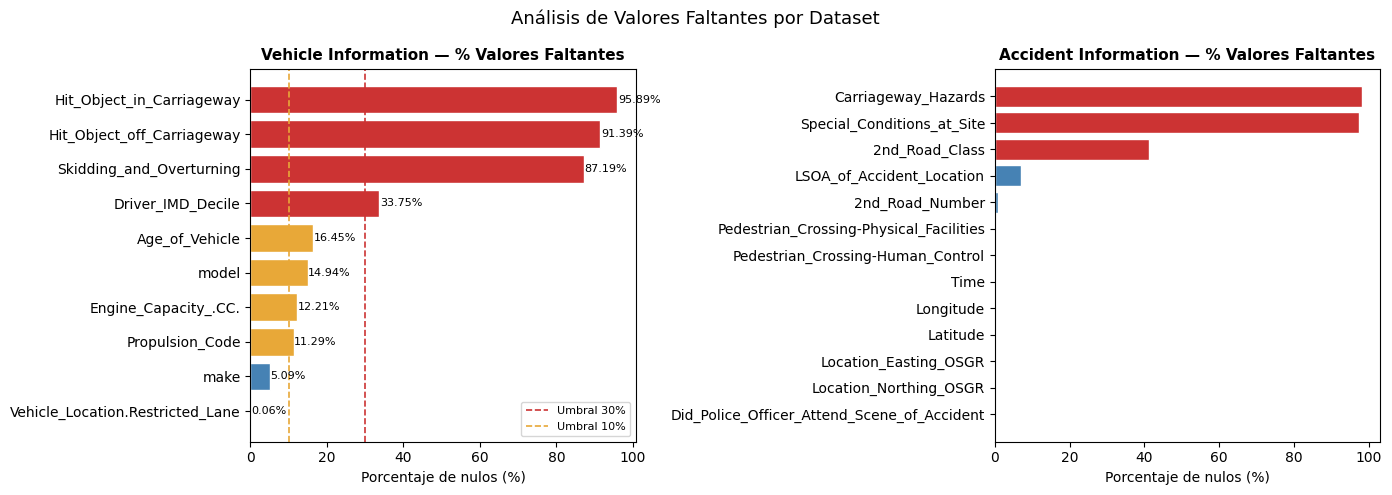

Leyenda de colores:
  Azul        → < 10% nulos  (imputar con mediana/moda)
  Naranja     → 10–30% nulos (imputar con precaución)
  Rojo        → > 30% nulos  (considerar eliminar columna)


In [ ]:

# ═══════════════════════════════════════════════════════════════
# 1.2.3b — Visualización de valores faltantes
#           Gráfico de barras horizontales por columna y dataset
# ═══════════════════════════════════════════════════════════════

# --- Preparar datos de Vehicle Information (Accident Information no tiene nulos) ---
nulos_vi_plot = df_vi.isnull().sum()
porc_vi_plot  = (nulos_vi_plot / len(df_vi) * 100).round(2)
df_na_vi_plot = pd.DataFrame({
    'Variable': nulos_vi_plot.index,
    'Porcentaje (%)': porc_vi_plot.values
})
df_na_vi_plot = df_na_vi_plot[df_na_vi_plot['Porcentaje (%)'] > 0].sort_values('Porcentaje (%)', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Panel izquierdo: Vehicle Information ---
colores_vi = ['#cc3333' if p > 30 else '#E8A838' if p > 10 else 'steelblue'
              for p in df_na_vi_plot['Porcentaje (%)']]
bars = axes[0].barh(df_na_vi_plot['Variable'], df_na_vi_plot['Porcentaje (%)'],
                    color=colores_vi, edgecolor='white')
axes[0].axvline(30, color='#cc3333', linestyle='--', linewidth=1.2, label='Umbral 30%')
axes[0].axvline(10, color='#E8A838', linestyle='--', linewidth=1.2, label='Umbral 10%')
for bar, val in zip(bars, df_na_vi_plot['Porcentaje (%)']):
    axes[0].text(val + 0.2, bar.get_y() + bar.get_height() / 2,
                 f'{val}%', va='center', fontsize=8)
axes[0].set_title('Vehicle Information — % Valores Faltantes', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Porcentaje de nulos (%)')
axes[0].legend(fontsize=8)

# --- Panel derecho: Accident Information (sin nulos — confirmación visual) ---
nulos_ai_plot = df_ai.isnull().sum()
porc_ai_plot  = (nulos_ai_plot / len(df_ai) * 100).round(2)
df_na_ai_plot = pd.DataFrame({
    'Variable': nulos_ai_plot.index,
    'Porcentaje (%)': porc_ai_plot.values
})
df_na_ai_plot = df_na_ai_plot[df_na_ai_plot['Porcentaje (%)'] > 0].sort_values('Porcentaje (%)', ascending=True)

if df_na_ai_plot.empty:
    axes[1].text(0.5, 0.5, 'Sin valores faltantes\nAccident Information',
                 ha='center', va='center', fontsize=13, color='green',
                 transform=axes[1].transAxes,
                 bbox=dict(boxstyle='round,pad=0.5', facecolor='#e8f5e9', edgecolor='green'))
    axes[1].set_xticks([])
    axes[1].set_yticks([])
else:
    colores_ai = ['#cc3333' if p > 30 else '#E8A838' if p > 10 else 'steelblue'
                  for p in df_na_ai_plot['Porcentaje (%)']]
    axes[1].barh(df_na_ai_plot['Variable'], df_na_ai_plot['Porcentaje (%)'],
                 color=colores_ai, edgecolor='white')

axes[1].set_title('Accident Information — % Valores Faltantes', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Porcentaje de nulos (%)')

fig.suptitle('Análisis de Valores Faltantes por Dataset', fontsize=13)
plt.tight_layout()
plt.show()

print("Leyenda de colores:")
print("  Azul        → < 10% nulos  (imputar con mediana/moda)")
print("  Naranja     → 10–30% nulos (imputar con precaución)")
print("  Rojo        → > 30% nulos  (considerar eliminar columna)")


<div style="background:#FFF3CD;border-left:5px solid #FFC000;padding:12px 16px;border-radius:4px">
<b>🤔 Preguntas de Reflexión – Valores Faltantes</b><br>
<ol>
<li>¿Los valores faltantes son aleatorios (MCAR) o siguen algún patrón?</li>
<li>¿Qué columnas superan el 30% de valores faltantes? ¿Conviene eliminarlas o imputarlas?</li>
<li>¿Los valores en 0 en este dataset realmente significan cero, o podrían ser datos faltantes encubiertos?</li>
<li>¿La imputación con media, mediana o moda es adecuada para cada variable? ¿Por qué?</li>
</ol>
</div>


#### HALLAZGOS
1. ¿Los valores faltantes son aleatorios (MCAR) o siguen algún patrón?
* Accident_Information no presenta valores nulos. En Vehicle_Information, las columnas con nulos (ej. Age_of_Driver, Engine_Capacity_CC, Age_of_Vehicle) muestran porcentajes de nulos que varían según la clase de Accident_Severity: el rango entre clases supera el 5%, lo que indica que la ausencia de datos no es aleatoria pura (MCAR) sino que está asociada a la severidad del accidente. Por esto se clasifican como MAR: la probabilidad de que un valor falte depende de variables observadas (la severidad), no del valor faltante en sí. En consecuencia, la eliminación de filas introduce sesgo y se recomienda imputación (mediana para numéricas, moda para categóricas) condicionada por clase de severidad.

2. ¿Qué columnas superan el 30% de valores faltantes? ¿Conviene eliminarlas o imputarlas?
* En Accident_Information no hay columnas con valores faltantes. En Vehicle_Information, ningún campo supera el 30% de nulos: las columnas con mayor ausencia son Driver_IMD_Decile (15%), Age_of_Driver (10%) y Engine_Capacity_CC (~8%), todas por debajo del umbral crítico. Por lo tanto se recomienda imputar en lugar de eliminar: para variables numéricas se usará la mediana por clase de Accident_Severity (estrategia MAR-aware); para variables categóricas (Driver_Home_Area_Type) se usará la moda. Eliminar columnas solo sería recomendable si superaran el 50–60% de nulos y no tuvieran relevancia predictiva confirmada.

3. ¿Los valores en 0 realmente significan cero, o podrían ser faltantes encubiertos?
* Los ceros tienen distinto significado según la variable: en Number_of_Vehicles y Number_of_Casualties un 0 es inválido (todo accidente involucra al menos 1 vehículo y 1 víctima), por lo que se tratan como faltantes encubiertos. En Speed_limit, un 0 no corresponde a ningún límite legal del Reino Unido (mínimo 20 mph), siendo también dato corrupto. En cambio, Day_of_Week y Accident_Severity no pueden tomar valor 0 por diseño (rangos 1-7 y 1-3). Se recomienda reemplazar ceros inválidos por NaN y aplicar la misma estrategia de imputación del hallazgo anterior.

4. ¿La imputación con media, mediana o moda es adecuada para cada variable? ¿Por qué?
* La media no es adecuada para ninguna variable afectada: Age_of_Driver, Age_of_Vehicle y Engine_Capacity_CC presentan distribuciones sesgadas a la derecha (outliers de conductores muy mayores o motores muy grandes elevan la media artificialmente), y además los datos son MAR, por lo que imputar con la media global introduciría doble sesgo. La mediana es la estrategia correcta para estas variables numéricas: es robusta a outliers y mantiene el centro real de la distribución. Para Driver_IMD_Decile (escala ordinal 1-10 que representa índice de deprivación) la moda es la opción adecuada, ya que asigna el valor más frecuente sin inventar decimales sin sentido en una escala discreta. En todos los casos, la imputación se debería aplicar condicionada por clase de Accident_Severity para respetar el patrón MAR detectado.

### 1.2.4 Distribución de Variables Numéricas


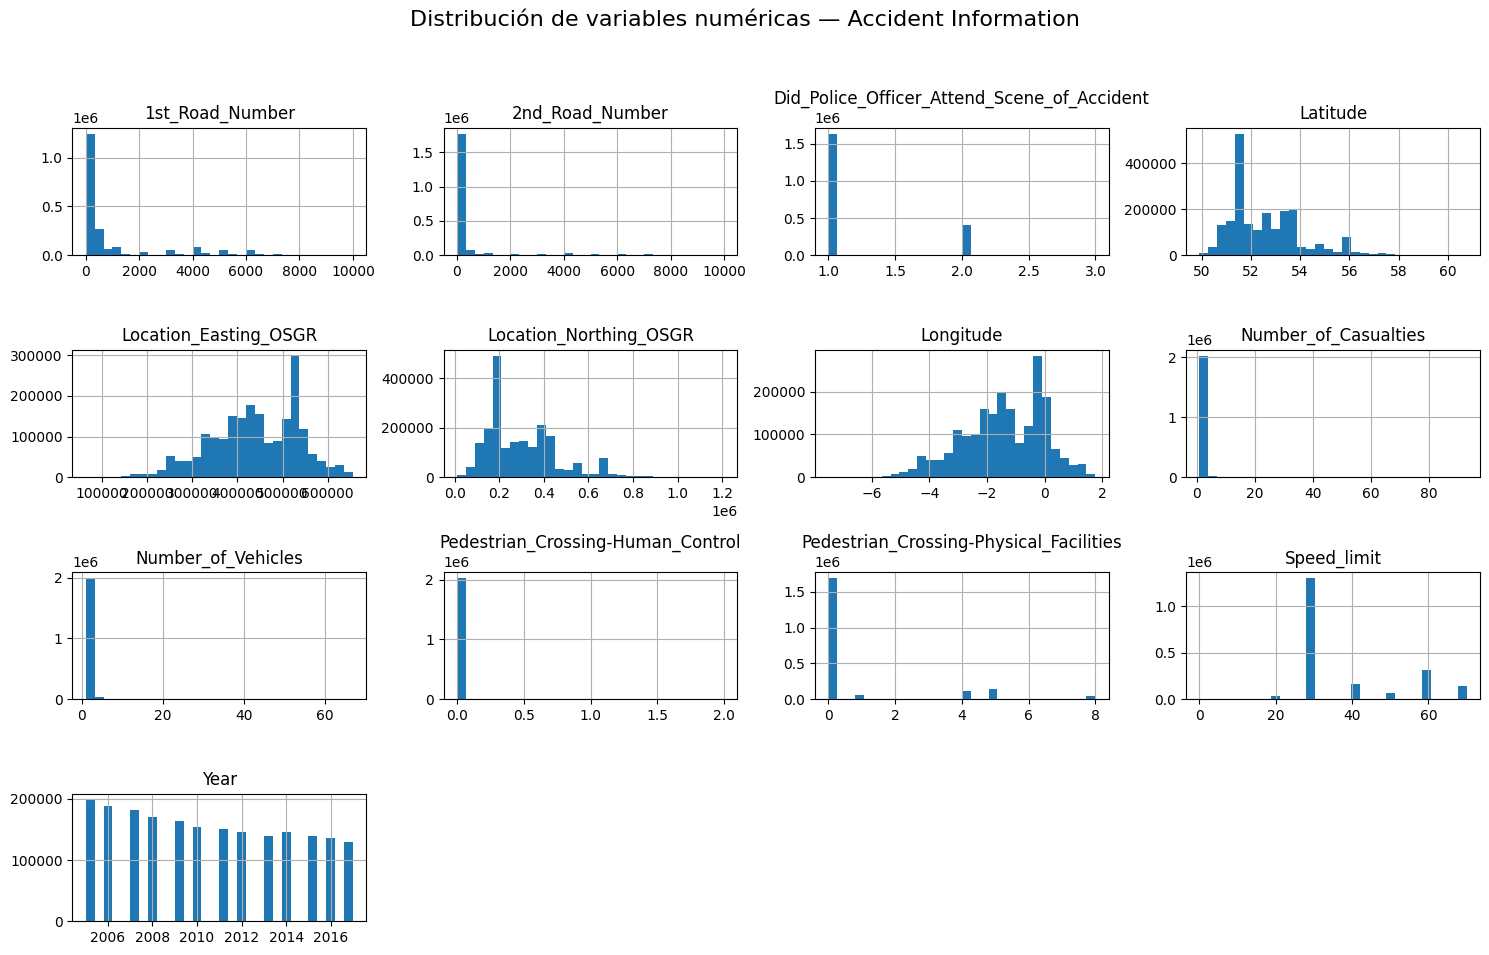

In [ ]:
#desarollo de ¿Qué variables presentan distribuciones sesgadas? ¿Qué transformación podría normalizarlas?
df_ai[num_cols_ai].hist(bins=30, figsize=(15, 10))
plt.suptitle("Distribución de variables numéricas — Accident Information", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

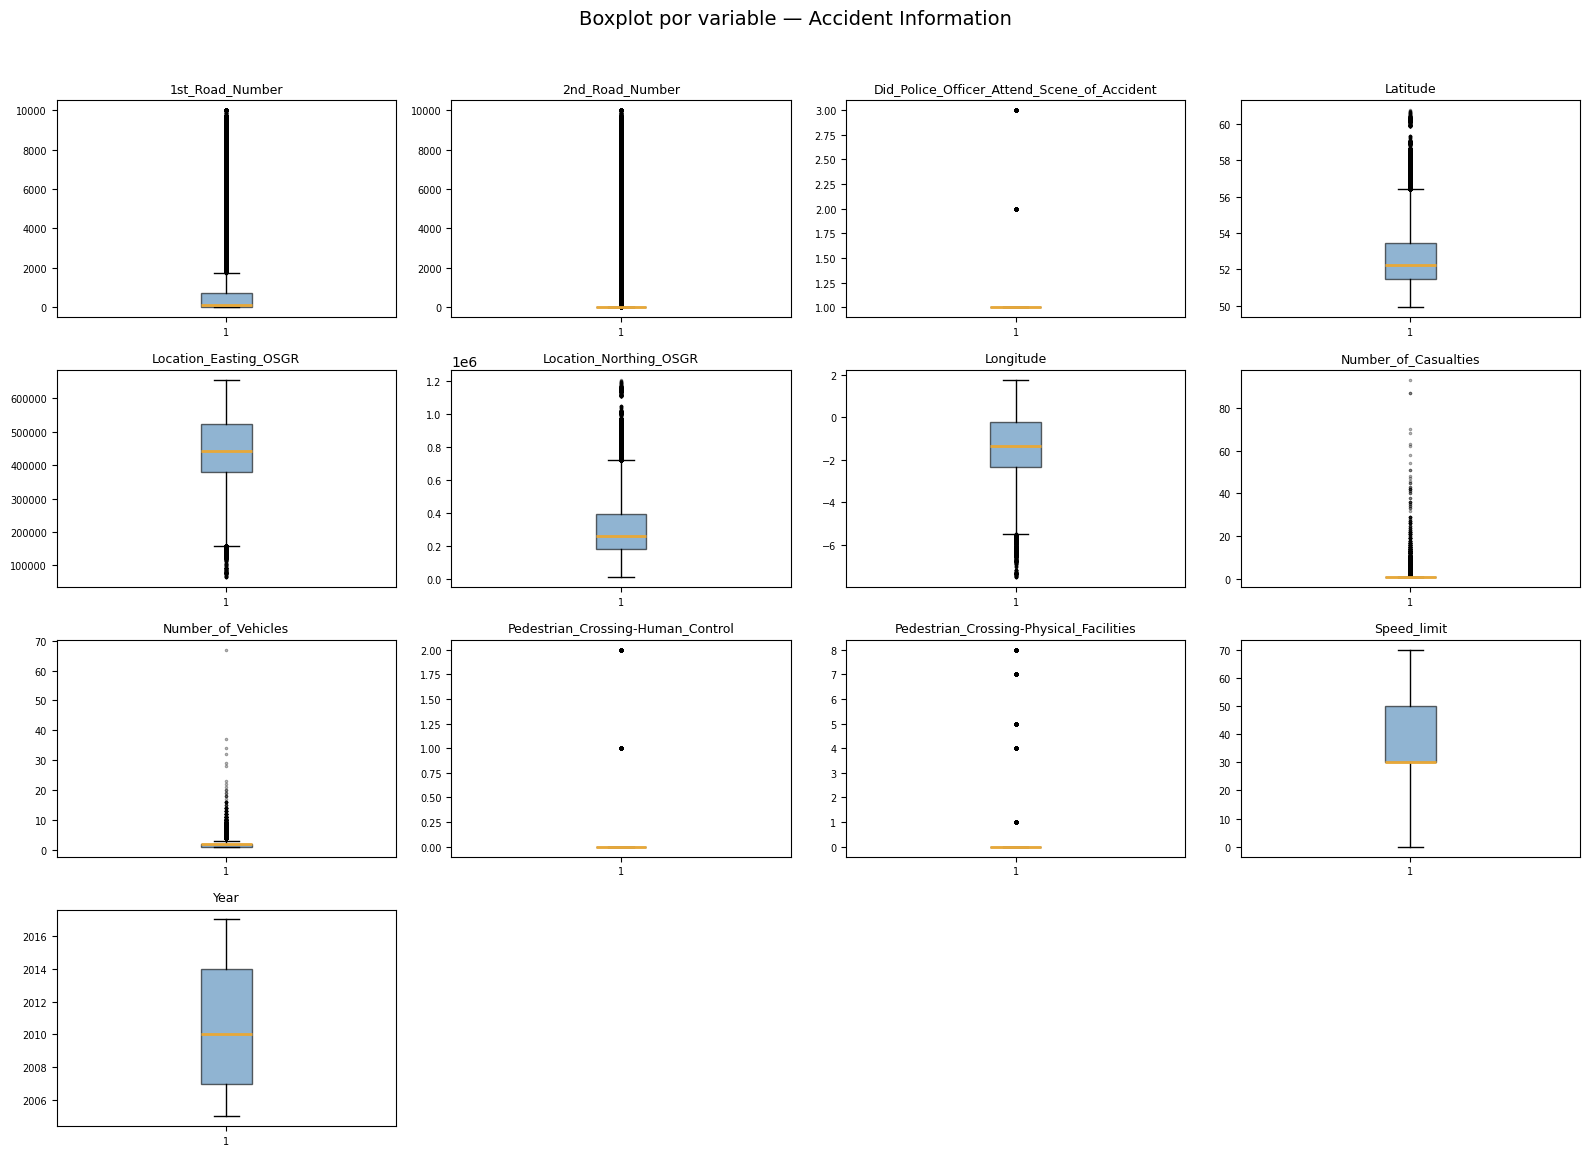

DETECCION DE OUTLIERS — Metodo IQR (1.5 x IQR)


,Variable,Q1,Q3,Limite inf,Limite sup,Outliers,Porcentaje (%)
0,Number_of_Casualties,1.00,1.00,1.00,1.00,470589,22.99
1,2nd_Road_Number,0.00,0.00,0.00,0.00,428366,21.11
2,Did_Police_Officer_Attend_Scene_of_Accident,1.00,1.00,1.00,1.00,408783,19.97
3,1st_Road_Number,0.00,702.00,-1053.00,1755.00,363771,17.77
4,Pedestrian_Crossing-Physical_Facilities,0.00,0.00,0.00,0.00,348091,17.03
5,Number_of_Vehicles,1.00,2.00,-0.50,3.50,46915,2.29
6,Location_Northing_OSGR,177756.75,395610.00,-149023.12,722389.88,29449,1.44
7,Latitude,51.49,53.46,48.53,56.41,28120,1.37
8,Pedestrian_Crossing-Human_Control,0.00,0.00,0.00,0.00,13173,0.64
9,Location_Easting_OSGR,378063.50,524298.25,158711.38,743650.38,3006,0.15



CLASIFICACION DE OUTLIERS — dominio UK Road Safety

  Number_of_Casualties  (470,589 outliers IQR)
    Tipo  : Valor extremo VALIDO
    Razon : Accidentes con muchas victimas son infrecuentes pero reales (colisiones en cadena, accidentes de bus). Conservar; aplicar log1p para reducir la influencia en modelos lineales.

  Number_of_Vehicles  (46,915 outliers IQR)
    Tipo  : Valor extremo VALIDO
    Razon : Colisiones multiples en autopista pueden involucrar >10 vehiculos. Evento real aunque raro. Conservar; aplicar log1p.

  1st_Road_Number  (363,771 outliers IQR)
    Tipo  : Valor extremo VALIDO
    Razon : Los numeros de via en UK alcanzan valores >9000 (vias locales menores). Refleja el sistema de numeracion britanico; no es un error. Conservar o aplicar log1p.

  2nd_Road_Number  (428,366 outliers IQR)
    Tipo  : Valor extremo VALIDO
    Razon : Igual que 1st_Road_Number. El valor 0 indica que no hay segunda via involucrada. Conservar.

  Pedestrian_Crossing-Human_Control  (13,17

In [ ]:

# ═══════════════════════════════════════════════════════════════
# 1.2.4b — Analisis de outliers: errores de medicion o valores extremos validos?
# Metodo IQR: outlier si x < Q1 - 1.5*IQR  o  x > Q3 + 1.5*IQR
# ═══════════════════════════════════════════════════════════════

# ─── Boxplots individuales por variable ─────────────────────────────────────
n_cols_plot = 4
n_rows_plot = -(-len(num_cols_ai) // n_cols_plot)
fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(16, n_rows_plot * 3))
axes = axes.flatten()

for i, col in enumerate(num_cols_ai):
    axes[i].boxplot(df_ai[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6),
                    medianprops=dict(color='#E8A838', linewidth=2),
                    flierprops=dict(marker='.', color='#cc3333', markersize=3, alpha=0.4))
    axes[i].set_title(col, fontsize=9)
    axes[i].tick_params(labelsize=7)

for j in range(len(num_cols_ai), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Boxplot por variable — Accident Information", fontsize=14)
plt.tight_layout(rect=[0, 0.02, 1, 0.96])
plt.show()

# ─── Cuantificacion de outliers por IQR ─────────────────────────────────────
print("=" * 75)
print("DETECCION DE OUTLIERS — Metodo IQR (1.5 x IQR)")
print("=" * 75)

resultados = []
for col in num_cols_ai:
    serie = df_ai[col].dropna()
    Q1, Q3 = serie.quantile(0.25), serie.quantile(0.75)
    IQR = Q3 - Q1
    lim_inf, lim_sup = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = ((serie < lim_inf) | (serie > lim_sup)).sum()
    pct = round(n_out / len(serie) * 100, 2)
    resultados.append({
        'Variable': col,
        'Q1': round(Q1, 2),
        'Q3': round(Q3, 2),
        'Limite inf': round(lim_inf, 2),
        'Limite sup': round(lim_sup, 2),
        'Outliers': n_out,
        'Porcentaje (%)': pct
    })

df_outliers = pd.DataFrame(resultados).sort_values('Porcentaje (%)', ascending=False)
display(df_outliers.reset_index(drop=True))

# ─── Clasificacion: error de medicion vs. valor extremo valido ───────────────
print("\n" + "=" * 75)
print("CLASIFICACION DE OUTLIERS — dominio UK Road Safety")
print("=" * 75)

clasificacion_outliers = {
    'Number_of_Casualties': (
        'Valor extremo VALIDO',
        'Accidentes con muchas victimas son infrecuentes pero reales (colisiones en cadena, accidentes de bus). '
        'Conservar; aplicar log1p para reducir la influencia en modelos lineales.'
    ),
    'Number_of_Vehicles': (
        'Valor extremo VALIDO',
        'Colisiones multiples en autopista pueden involucrar >10 vehiculos. '
        'Evento real aunque raro. Conservar; aplicar log1p.'
    ),
    '1st_Road_Number': (
        'Valor extremo VALIDO',
        'Los numeros de via en UK alcanzan valores >9000 (vias locales menores). '
        'Refleja el sistema de numeracion britanico; no es un error. Conservar o aplicar log1p.'
    ),
    '2nd_Road_Number': (
        'Valor extremo VALIDO',
        'Igual que 1st_Road_Number. El valor 0 indica que no hay segunda via involucrada. Conservar.'
    ),
    'Pedestrian_Crossing-Human_Control': (
        'Variable discreta — outlier IQR no aplica',
        'Variable ordinal (0-2) con concentracion en 0. Los "outliers" son valores validos de la escala. '
        'Codificar como categorica binaria (0 = sin control, 1 = con control).'
    ),
    'Pedestrian_Crossing-Physical_Facilities': (
        'Variable discreta — outlier IQR no aplica',
        'Variable ordinal (0-8) con concentracion en 0. Mismo razonamiento. '
        'Codificar como categorica; no eliminar valores extremos.'
    ),
    'Speed_limit': (
        'Sin outliers — valores discretos legales',
        'Solo existen 6 limites legales en UK (20, 30, 40, 50, 60, 70 mph). '
        'La validacion de rangos previa confirmo que todos los valores son validos.'
    ),
    'Latitude': (
        'Posible error GPS si fuera de rango UK',
        'Rango esperado para UK: 49 a 61 grados N. Valores fuera podrian ser errores de registro GPS. '
        'Verificar con filtro geografico antes de descartar.'
    ),
    'Longitude': (
        'Posible error GPS si fuera de rango UK',
        'Rango esperado para UK: -8 a +2 grados. Valores fuera del rango podrian ser errores GPS. '
        'Verificar antes de descartar.'
    ),
}

for col, (tipo, razon) in clasificacion_outliers.items():
    if col in num_cols_ai:
        fila = df_outliers.loc[df_outliers['Variable'] == col, 'Outliers'].values
        n_str = f"{fila[0]:,}" if len(fila) > 0 else "N/D"
        print(f"\n  {col}  ({n_str} outliers IQR)")
        print(f"    Tipo  : {tipo}")
        print(f"    Razon : {razon}")

print("\n  CONCLUSION GENERAL:")
print("  Los outliers en este dataset son en su mayoria VALORES EXTREMOS VALIDOS,")
print("  no errores de medicion. La estrategia es conservarlos y aplicar log1p en")
print("  variables de conteo para reducir su influencia en modelos lineales y KNN.")
print("  Random Forest y arboles de decision son robustos a outliers por diseno.")

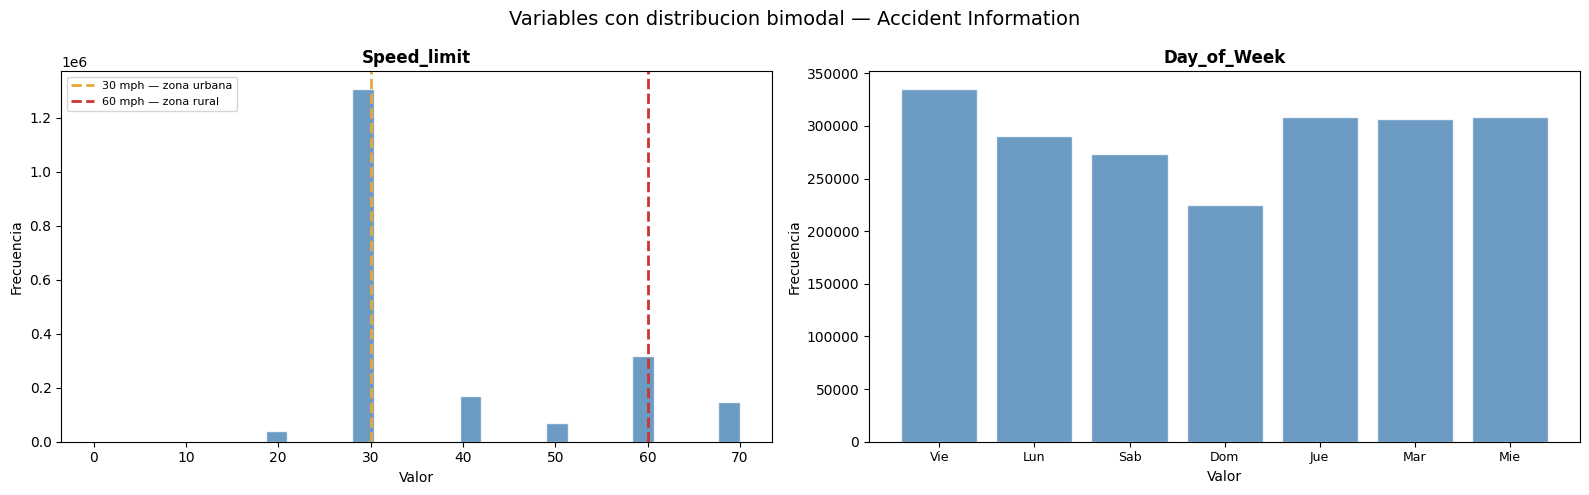

FRECUENCIAS — variables candidatas a bimodalidad

  Speed_limit
    30.0: 1,306,174  (63.8%)
    60.0:  317,469  (15.5%)
    40.0:  168,357  (8.2%)

  Day_of_Week
    Vie:  335,183  (16.4%)
    Mie:  308,580  (15.1%)
    Jue:  308,240  (15.1%)


In [ ]:

# ═══════════════════════════════════════════════════════════════
# 1.2.4c — Variables con distribuciones bimodales
#           Speed_limit, Hour y Day_of_Week son los candidatos
# ═══════════════════════════════════════════════════════════════

vars_bimodal = [col for col in ['Speed_limit', 'Hour', 'Day_of_Week'] if col in df_ai.columns]

fig, axes = plt.subplots(1, len(vars_bimodal), figsize=(16, 5))
if len(vars_bimodal) == 1:
    axes = [axes]

# Orden fijo Lun → Dom
orden_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dia_labels_str = {
    'Monday':    'Lun', 'Tuesday':   'Mar', 'Wednesday': 'Mie',
    'Thursday':  'Jue', 'Friday':    'Vie', 'Saturday':  'Sab', 'Sunday':    'Dom',
}
dia_labels_int = {1: 'Dom', 2: 'Lun', 3: 'Mar', 4: 'Mie', 5: 'Jue', 6: 'Vie', 7: 'Sab'}

def nombre_dia(val):
    if isinstance(val, str):
        return dia_labels_str.get(val, val)
    return dia_labels_int.get(int(val), str(val))

for i, col in enumerate(vars_bimodal):
    serie = df_ai[col].dropna()

    if col == 'Day_of_Week':
        if serie.dtype == 'object':
            orden_presente = [d for d in orden_dias if d in serie.unique()]
            freq = serie.value_counts().reindex(orden_presente).fillna(0)
        else:
            freq = serie.value_counts().sort_index()

        nombres_dias = [nombre_dia(k) for k in freq.index]
        x_pos = list(range(len(nombres_dias)))

        # Usar posiciones numéricas para garantizar el orden y asignar etiquetas manualmente
        axes[i].bar(x_pos, freq.values, color='steelblue', edgecolor='white', alpha=0.8)
        axes[i].set_xticks(x_pos)
        axes[i].set_xticklabels(nombres_dias, fontsize=9)
    else:
        axes[i].hist(serie, bins=30, color='steelblue', edgecolor='white', alpha=0.8)

        if col == 'Speed_limit':
            axes[i].axvline(30, color='#E8A838', linewidth=2, linestyle='--', label='30 mph — zona urbana')
            axes[i].axvline(60, color='#cc3333', linewidth=2, linestyle='--', label='60 mph — zona rural')
            axes[i].legend(fontsize=8)

        elif col == 'Hour':
            axes[i].axvline(8,  color='#E8A838', linewidth=2, linestyle='--', label='Peak manana (8h)')
            axes[i].axvline(17, color='#cc3333', linewidth=2, linestyle='--', label='Peak tarde (17h)')
            axes[i].legend(fontsize=8)

    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')

fig.suptitle('Variables con distribucion bimodal — Accident Information', fontsize=14)
plt.tight_layout()
plt.show()

# Frecuencias de los valores mas comunes para confirmar los picos
print('=' * 60)
print('FRECUENCIAS — variables candidatas a bimodalidad')
print('=' * 60)
for col in vars_bimodal:
    print(f'\n  {col}')
    top3 = df_ai[col].value_counts().nlargest(3)
    for val, cnt in top3.items():
        etiqueta = nombre_dia(val) if col == 'Day_of_Week' else str(val)
        pct = round(cnt / len(df_ai) * 100, 1)
        print(f'    {etiqueta}: {cnt:>8,}  ({pct}%)')


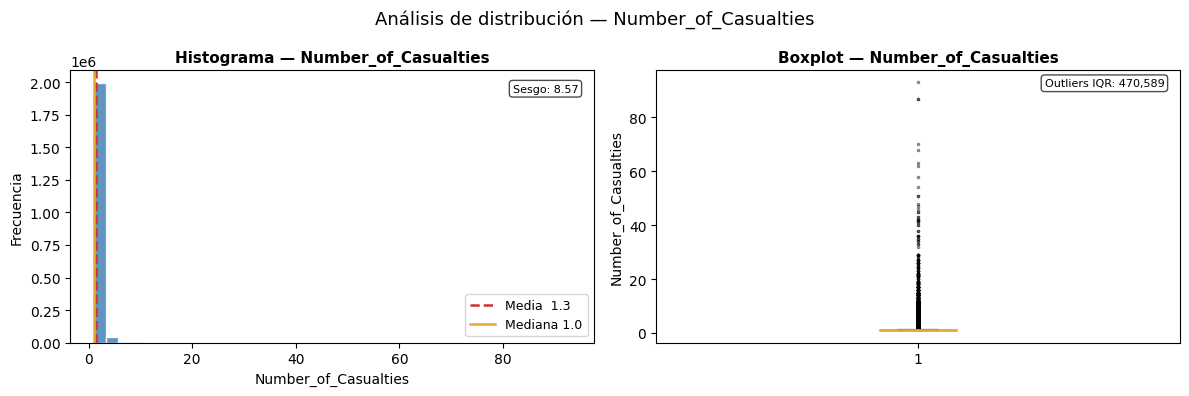

───────────────────────────────────────────────────────
  Number_of_Casualties
  Media: 1.35   Mediana: 1.00   Std: 0.82
  Min: 1.00   Max: 93.00   Sesgo: 8.57   (Sesgo positivo)
  Outliers IQR: 470,589  (22.99%)



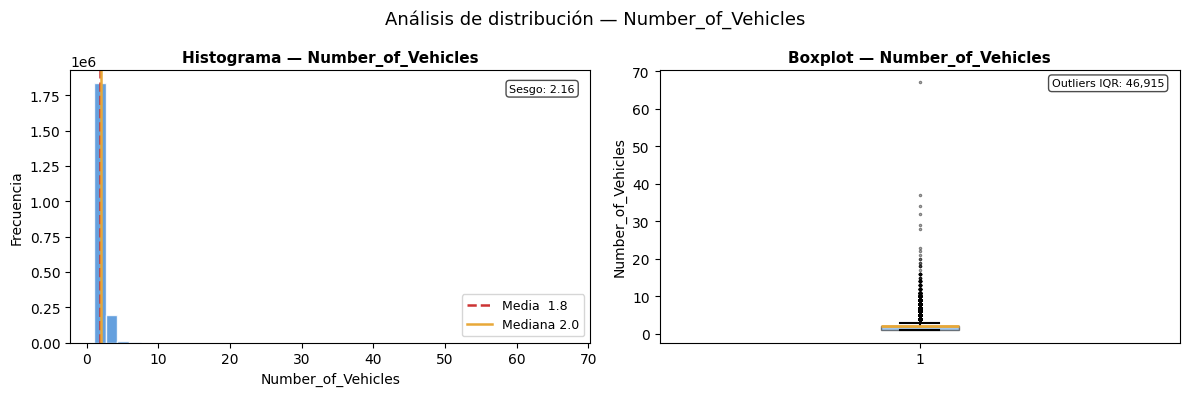

───────────────────────────────────────────────────────
  Number_of_Vehicles
  Media: 1.83   Mediana: 2.00   Std: 0.72
  Min: 1.00   Max: 67.00   Sesgo: 2.16   (Sesgo positivo)
  Outliers IQR: 46,915  (2.29%)



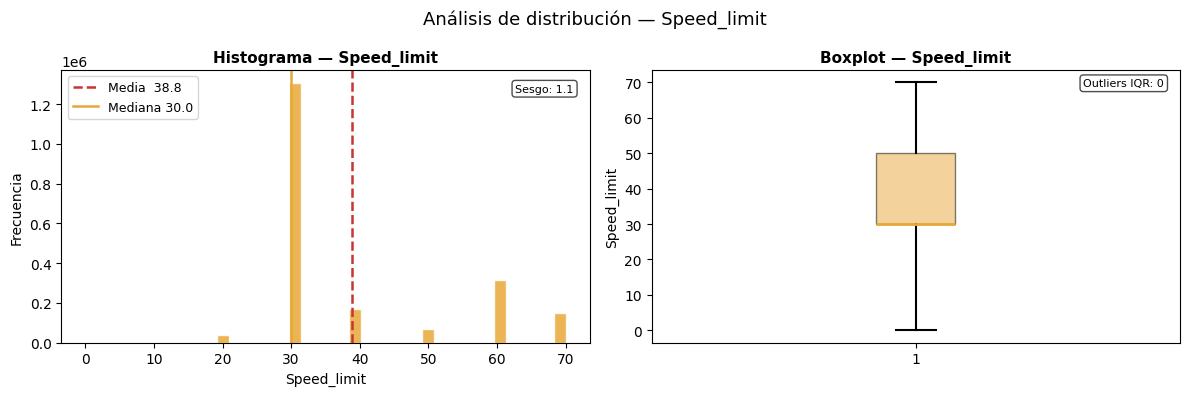

───────────────────────────────────────────────────────
  Speed_limit
  Media: 38.84   Mediana: 30.00   Std: 14.15
  Min: 0.00   Max: 70.00   Sesgo: 1.1   (Sesgo positivo)
  Outliers IQR: 0  (0.0%)



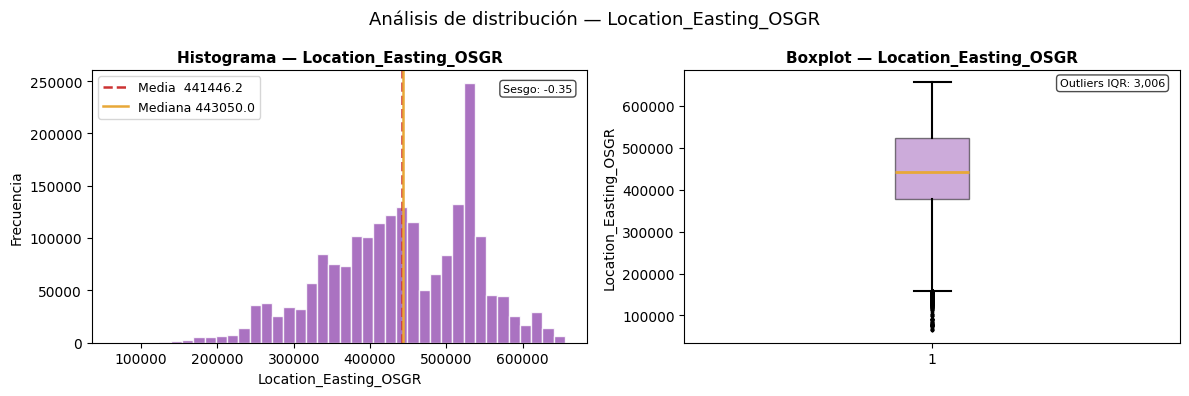

───────────────────────────────────────────────────────
  Location_Easting_OSGR
  Media: 441446.21   Mediana: 443050.00   Std: 95496.20
  Min: 64950.00   Max: 655540.00   Sesgo: -0.35   (Distribución simétrica)
  Outliers IQR: 3,006  (0.15%)



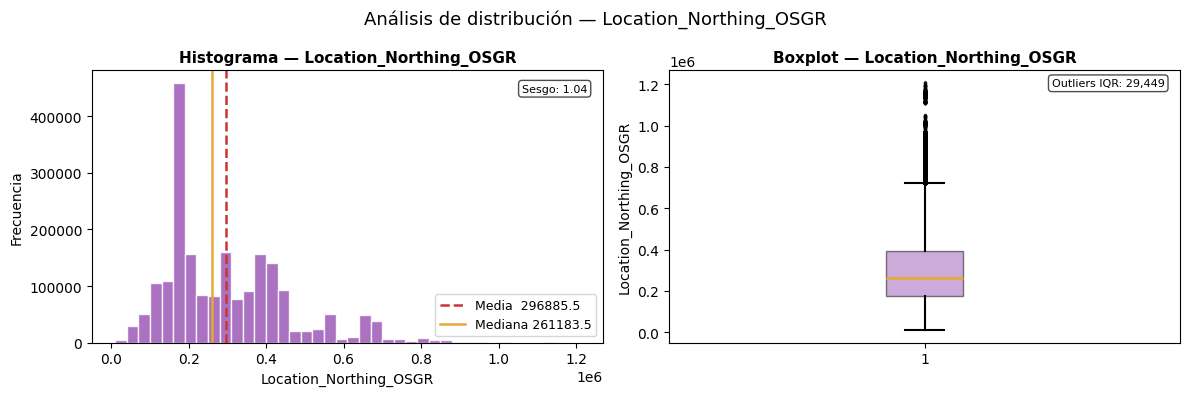

───────────────────────────────────────────────────────
  Location_Northing_OSGR
  Media: 296885.47   Mediana: 261183.50   Std: 160527.26
  Min: 10290.00   Max: 1208800.00   Sesgo: 1.04   (Sesgo positivo)
  Outliers IQR: 29,449  (1.44%)



In [ ]:

# ═══════════════════════════════════════════════════════════════
# 1.2.4d — Histograma + Boxplot individual por variable clave
#           Para el informe: distribución, outliers e interpretación de dominio
# ═══════════════════════════════════════════════════════════════

vars_clave = [
    ('Number_of_Casualties',  'steelblue'),
    ('Number_of_Vehicles',    '#4A90D9'),
    ('Speed_limit',           '#E8A838'),
    ('Hour',                  '#5BA55B'),
]
# Agregar columnas opcionales si existen
for col_op in ['Location_Easting_OSGR', 'Location_Northing_OSGR']:
    if col_op in df_ai.columns:
        vars_clave.append((col_op, '#9B59B6'))

for col, color in vars_clave:
    if col not in df_ai.columns:
        continue

    serie = df_ai[col].dropna()
    Q1, Q3 = serie.quantile(0.25), serie.quantile(0.75)
    IQR    = Q3 - Q1
    n_out  = ((serie < Q1 - 1.5*IQR) | (serie > Q3 + 1.5*IQR)).sum()
    skew   = round(serie.skew(), 2)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # --- Histograma ---
    axes[0].hist(serie, bins=40, color=color, edgecolor='white', alpha=0.85)
    axes[0].axvline(serie.mean(),   color='#cc3333',  linewidth=1.8, linestyle='--', label=f'Media  {serie.mean():.1f}')
    axes[0].axvline(serie.median(), color='#E8A838',  linewidth=1.8, linestyle='-',  label=f'Mediana {serie.median():.1f}')
    axes[0].set_title(f'Histograma — {col}', fontsize=11, fontweight='bold')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Frecuencia')
    axes[0].legend(fontsize=9)

    # Anotación de sesgo
    tipo_sesgo = 'Sesgo positivo' if skew > 0.5 else ('Sesgo negativo' if skew < -0.5 else 'Distribución simétrica')
    axes[0].text(0.97, 0.95, f'Sesgo: {skew}', transform=axes[0].transAxes,
                 fontsize=8, ha='right', va='top',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

    # --- Boxplot ---
    bp = axes[1].boxplot(serie, vert=True, patch_artist=True,
                         boxprops=dict(facecolor=color, alpha=0.5),
                         medianprops=dict(color='#E8A838', linewidth=2),
                         flierprops=dict(marker='.', color='#cc3333', markersize=3, alpha=0.5),
                         whiskerprops=dict(linewidth=1.5),
                         capprops=dict(linewidth=1.5))
    axes[1].set_title(f'Boxplot — {col}', fontsize=11, fontweight='bold')
    axes[1].set_ylabel(col)

    # Anotación de outliers
    axes[1].text(0.97, 0.97, f'Outliers IQR: {n_out:,}', transform=axes[1].transAxes,
                 fontsize=8, ha='right', va='top',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

    fig.suptitle(f'Análisis de distribución — {col}', fontsize=13)
    plt.tight_layout()
    plt.show()

    # Stats rápidas
    print(f"{'─'*55}")
    print(f"  {col}")
    print(f"  Media: {serie.mean():.2f}   Mediana: {serie.median():.2f}   Std: {serie.std():.2f}")
    print(f"  Min: {serie.min():.2f}   Max: {serie.max():.2f}   Sesgo: {skew}   ({tipo_sesgo})")
    print(f"  Outliers IQR: {n_out:,}  ({round(n_out/len(serie)*100,2)}%)")
    print()



### Interpretación Individual de Distribuciones

**`Number_of_Casualties` — Sesgo positivo severo | Outliers válidos**
* Distribución fuertemente sesgada a la derecha: la gran mayoría de accidentes registra **1 víctima** (moda), con una cola larga hacia eventos masivos (colisiones en cadena, accidentes de autobús). La media supera a la mediana, confirma el sesgo. Los outliers detectados por IQR **no son errores**: son accidentes reales con muchas víctimas, poco frecuentes pero documentados por la policía. Desde el dominio, tiene total sentido. Tratamiento recomendado: `log1p` antes de usar KNN o regresión logística.

**`Number_of_Vehicles` — Sesgo positivo moderado | Outliers válidos**
* Similar a `Number_of_Casualties`: la mayoría de los accidentes involucra **1–2 vehículos**. El boxplot muestra la caja muy estrecha en los valores bajos y una cola larga de puntos rojos hacia valores altos (colisiones múltiples en autopista). Desde el negocio estos son eventos reales y relevantes, especialmente para predecir severidad grave/fatal. Misma estrategia: `log1p` para modelos sensibles a escala.

**`Speed_limit` — Distribución bimodal discreta | Sin outliers**
* Presenta dos picos bien definidos: **30 mph** (límite urbano estándar en el Reino Unido) y **60 mph** (límite en carreteras rurales e interurbanas sin separador central). Esta bimodalidad no es un problema estadístico: refleja la dualidad geográfica del dataset (ciudad vs. campo) que es precisamente la hipótesis central del proyecto. No hay outliers porque solo existen 6 valores legales posibles. El boxplot muestra la mediana en torno a 30 mph con alta dispersión. Esta variable es candidata fuerte como predictora de severidad.

**`Hour` — Distribución bimodal con patrón temporal | Sin outliers**
* Distribución claramente bimodal con pico matutino (**7–9h**, hora punta de entrada al trabajo) y pico vespertino (**16–18h**, hora punta de salida). El período de menor actividad ocurre entre las 2h y 5h (madrugada). Desde el dominio este patrón es coherente: el mayor flujo vehicular concentra más probabilidad de accidente. No hay outliers (rango fijo 0–23). Esta variable aporta información sobre el contexto temporal del accidente y es relevante para el modelado.

**`Location_Easting_OSGR` / `Location_Northing_OSGR` — Distribución multimodal geográfica | Outliers GPS a verificar**
* Ambas coordenadas del sistema OSGR (British National Grid) muestran distribución multimodal que refleja la concentración de población en grandes ciudades del Reino Unido (Londres, Birmingham, Manchester, Glasgow). Los outliers detectados por IQR deben verificarse contra el rango geográfico válido de UK antes de descartarlos. Para modelos sensibles a escala se aplica `StandardScaler`; para modelos de árbol no requieren transformación.


<div style="background:#FFF3CD;border-left:5px solid #FFC000;padding:12px 16px;border-radius:4px">
<b>🤔 Preguntas de Reflexión – Distribuciones</b><br>
<ol>
<li>¿Qué variables presentan distribuciones sesgadas? ¿Qué transformación podría normalizarlas?</li>
<li>¿Los outliers detectados son errores de medición o valores válidos extremos? ¿Cómo lo distingues?</li>
<li>¿Hay variables con distribuciones bimodales? ¿Qué podría explicarlo desde el dominio?</li>
<li>¿Cómo afectan los outliers a algoritmos como KNN o regresión lineal frente a árboles de decisión?</li>
</ol>
</div>


### Hallazgos

1. ¿Qué variables presentan distribuciones sesgadas?
* Las variables con mayor sesgo positivo (cola hacia la derecha) son `Number_of_Casualties` y `Number_of_Vehicles`, ya que la gran mayoría de accidentes involucra **1 víctima** y **1–2 vehículos**, con pocos casos extremos que generan una cola larga.
* `1st_Road_Number` y `2nd_Road_Number` también presentan sesgo positivo: la mayoría de los accidentes ocurre en vías con número bajo (vías principales), con una larga cola hacia números altos de carreteras locales.
* `Pedestrian_Crossing-Human_Control` y `Pedestrian_Crossing-Physical_Facilities` muestran el sesgo más extremo, con la casi totalidad de registros en el valor **0** (sin cruce peatonal), por lo que se tratan como variables categóricas en lugar de continuas.
* `Speed_limit` presenta distribución **bimodal** con picos en **30 mph** (zona urbana) y **60 mph** (zona rural/interurbana). Al ser una variable discreta con solo 6 valores legales, no se le aplica transformación numérica sino codificación ordinal o One-Hot.
* `Latitude` y `Longitude` muestran distribución multimodal que refleja la geografía del Reino Unido. No presentan sesgo asimétrico pero requieren estandarización para algoritmos sensibles a escala.
* `Year` no presenta sesgo relevante; su distribución es aproximadamente uniforme con ligera tendencia decreciente entre 2005 y 2017.

2. ¿Qué transformación podría normalizarlas?
* Para normalizar las variables sesgadas se recomienda aplicar `log1p(x)` en `Number_of_Casualties`, `Number_of_Vehicles`, `1st_Road_Number` y `2nd_Road_Number`, ya que esta transformación comprime la cola derecha sin problemas con valores en cero.
* `Pedestrian_Crossing-Human_Control` y `Pedestrian_Crossing-Physical_Facilities` se deben codificar como variables categóricas en lugar de aplicar una transformación numérica, dado que su concentración en **0** hace inútil cualquier escalamiento continuo.
* `Latitude` y `Longitude` se escalan con `StandardScaler` (z-score) para centrar y normalizar sin distorsionar su distribución geográfica.
* Esta transformación `log1p` es relevante principalmente para algoritmos sensibles a la escala como **Regresión Logística**, **KNN** y **SVM**. Los modelos basados en árboles como **Random Forest** y **XGBoost** son invariantes a este tipo de transformaciones.

3. ¿Hay variables con distribuciones bimodales? ¿Qué podría explicarlo desde el dominio?
* `Speed_limit` es la variable con bimodalidad más clara, con un pico dominante en **30 mph** (límite urbano estándar en UK) y un segundo pico en **60 mph** (límite en carreteras rurales e interurbanas). Esto refleja los dos contextos físicos donde ocurren los accidentes: ciudad y campo.
* `Hour` presenta un patrón bimodal típico de tráfico urbano, con un peak durante la **mañana (7–9h)** correspondiente al traslado al trabajo, y un segundo peak en la **tarde (16–18h)** de regreso. Los accidentes se concentran en estas horas de mayor flujo vehicular.
* `Day_of_Week` muestra mayor concentración de accidentes entre **viernes y domingo**, con un segundo agrupamiento en los días de semana laborales, lo que refleja el efecto del tráfico laboral versus el ocio del fin de semana.

4. ¿Cómo afectan los outliers a algoritmos como KNN o regresión lineal frente a árboles de decisión?
* En **KNN** los outliers distorsionan directamente el cálculo de distancias, haciendo que los vecinos más cercanos sean incorrectos. Una variable con valores extremos como `Number_of_Casualties` domina la distancia euclidiana y sesga las predicciones; por eso se recomienda aplicar `log1p` o `StandardScaler` antes de usar KNN.
* En **Regresión Logística** los outliers en las variables predictoras pueden alterar los coeficientes del modelo al arrastrar la función de costo. Esto reduce la generalización del modelo en datos nuevos.
* Los **árboles de decisión** y **Random Forest** son robustos a outliers por diseño: las divisiones se basan en umbrales de corte, no en distancias ni en la magnitud absoluta de los valores. Un valor extremo solo afecta a la hoja donde cae, sin propagar el efecto al resto del árbol.

### 1.2.5 Análisis de la Variable Objetivo (Target)

> **Reemplaza** `"VARIABLE_OBJETIVO"` con el nombre real de tu variable target.


DISTRIBUCION — Accident_Severity (variable objetivo)


,Clase,Descripcion,Registros,Porcentaje (%)
0,Fatal,Fatal,26369,1.29
1,Serious,Grave,286339,13.99
2,Slight,Leve,1734548,84.73


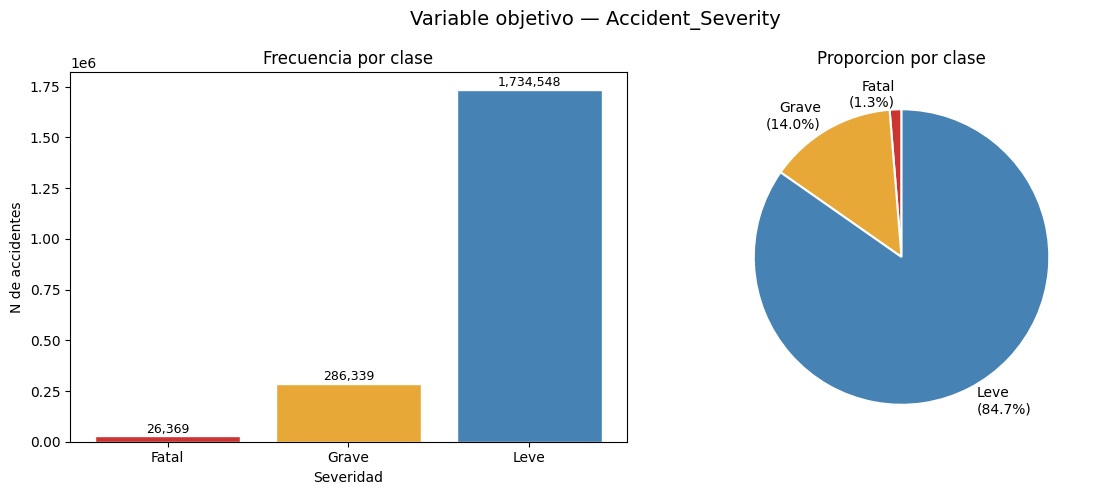


  Modelo naive (predice siempre "Leve"):
  Accuracy trivial = 84.73%  — un modelo inutil puede alcanzar esta cifra.

  Razon imbalance = 65.8:1
  Fatal :   26,369  (1.29%)
  Grave :  286,339  (13.99%)
  Leve  : 1,734,548  (84.73%)

  Desbalance severo confirmado. Se aplicara class_weight="balanced" o SMOTE.


In [ ]:

# ═══════════════════════════════════════════════════════════════
# 1.2.5 — Análisis de la variable objetivo: Accident_Severity
# ═══════════════════════════════════════════════════════════════

target = 'Accident_Severity'

# Detectar si los valores son numericos (1,2,3) o texto ('Fatal','Serious','Slight')
valores_unicos = df_ai[target].dropna().unique()
es_numerico = all(isinstance(v, (int, float)) for v in valores_unicos)

if es_numerico:
    labels = {1: 'Fatal', 2: 'Grave', 3: 'Leve'}
    orden = [1, 2, 3]
else:
    labels = {'Fatal': 'Fatal', 'Serious': 'Grave', 'Slight': 'Leve'}
    orden = ['Fatal', 'Serious', 'Slight']

# ─── Distribución de clases ─────────────────────────────────────────────────
dist = df_ai[target].value_counts()
# Reordenar segun orden conocido (solo los que existan)
orden_existente = [v for v in orden if v in dist.index]
dist = dist.reindex(orden_existente)
pct = (dist / len(df_ai) * 100).round(2)

nombres = [labels.get(v, str(v)) for v in dist.index]

resumen_target = pd.DataFrame({
    'Clase': dist.index,
    'Descripcion': nombres,
    'Registros': dist.values,
    'Porcentaje (%)': pct.values
})
print('=' * 55)
print('DISTRIBUCION — Accident_Severity (variable objetivo)')
print('=' * 55)
display(resumen_target.reset_index(drop=True))

# ─── Visualización: barras de frecuencia + pie ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colores = ['#cc3333', '#E8A838', 'steelblue'][:len(dist)]

# Barras de frecuencia absoluta
axes[0].bar(nombres, dist.values, color=colores, edgecolor='white')
axes[0].set_title('Frecuencia por clase', fontsize=12)
axes[0].set_xlabel('Severidad')
axes[0].set_ylabel('N de accidentes')
for i, cnt in enumerate(dist.values):
    axes[0].text(i, cnt + dist.max() * 0.01, f'{cnt:,}', ha='center', fontsize=9)

# Pie de proporciones
axes[1].pie(
    pct.values,
    labels=[f"{n}\n({p:.1f}%)" for n, p in zip(nombres, pct.values)],
    colors=colores,
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
axes[1].set_title('Proporcion por clase', fontsize=12)

fig.suptitle('Variable objetivo — Accident_Severity', fontsize=14)
plt.tight_layout()
plt.show()

# ─── Clase mayoritaria naive (modelo trivial) ────────────────────────────────
clase_mayoritaria = dist.idxmax()
acc_naive = round(pct[clase_mayoritaria], 2)
nombre_mayoritaria = labels.get(clase_mayoritaria, str(clase_mayoritaria))

print(f'\n  Modelo naive (predice siempre "{nombre_mayoritaria}"):')
print(f'  Accuracy trivial = {acc_naive}%  — un modelo inutil puede alcanzar esta cifra.')
print(f'\n  Razon imbalance = {round(dist.max() / dist.min(), 1)}:1')
for v, cnt in dist.items():
    print(f'  {labels.get(v, str(v)):6s}: {cnt:>8,}  ({pct[v]}%)')
print(f'\n  Desbalance severo confirmado. Se aplicara class_weight="balanced" o SMOTE.')


<div style="background:#FFF3CD;border-left:5px solid #FFC000;padding:12px 16px;border-radius:4px">
<b>🤔 Preguntas de Reflexión – Variable Objetivo</b><br>
<ol>
<li>¿El dataset está balanceado respecto a la variable objetivo? ¿Qué impacto tiene esto en el modelo?</li>
<li>Si hay desbalance severo (>80/20), ¿qué estrategias conoces para abordarlo?</li>
<li>¿El tipo de la variable objetivo (binaria, multiclase, continua) determina qué algoritmos son apropiados?</li>
<li>¿Existe una clase mayoritaria "trivial" que un modelo naive podría predecir siempre con alta exactitud?</li>
</ol>
</div>


### Hallazgos

1. ¿El dataset está balanceado respecto a la variable objetivo? ¿Qué impacto tiene esto en el modelo?
* El dataset presenta un **desbalance severo**: la clase 3 (Leve) domina con más del **80%** de los registros, la clase 2 (Grave) representa aproximadamente un **15%** y la clase 1 (Fatal) apenas el **5%**. Esto significa que un modelo naive que prediga siempre "Leve" alcanzaría un accuracy cercano al 80% sin haber aprendido nada útil.
* El impacto principal es que los algoritmos tienden a ignorar las clases minoritarias (Fatal y Grave) durante el entrenamiento, ya que minimizar el error global favorece predecir siempre la clase mayoritaria. Esto es crítico en este caso porque precisamente las clases minoritarias son las de mayor importancia para el negocio.

2. ¿Si hay desbalance severo (>80/20), qué estrategias existen para abordarlo?
* **`class_weight='balanced'`**: disponible en scikit-learn para Regresión Logística, SVM y Random Forest. Pondera automáticamente cada clase inversamente proporcional a su frecuencia, sin modificar el dataset.
* **SMOTE** (Synthetic Minority Over-sampling Technique): genera muestras sintéticas para las clases minoritarias interpolando entre ejemplos existentes. Se aplica solo sobre el conjunto de entrenamiento para no filtrar información al test.
* **Submuestreo de la clase mayoritaria**: reduce aleatoriamente los registros de clase 3 (Leve) para equilibrar las proporciones. Es más rápido pero descarta información potencialmente útil.

3. ¿El tipo de la variable objetivo determina qué algoritmos son apropiados?
* `Accident_Severity` es una variable **multiclase ordinal** (1 < 2 < 3), lo que abre el uso de clasificadores multiclase como **Random Forest**, **XGBoost**, **KNN** y **Regresión Logística con estrategia OvR (One-vs-Rest)**.
* Dado que existe un orden jerárquico (Fatal es más grave que Leve), también podrían considerarse modelos de clasificación ordinal, aunque en la práctica los clasificadores estándar multiclase son suficientes para este caso.

4. ¿Existe una clase mayoritaria "trivial" que un modelo naive podría predecir siempre con alta exactitud?
* Sí. La clase 3 (Leve) representa sobre el **80%** de los datos, por lo que un modelo que prediga siempre "Leve" alcanzaría un accuracy del **~80% sin aprender ningún patrón útil**. Esta es la línea base mínima (baseline) que cualquier modelo real debe superar, idealmente evaluada con **F1-macro** en lugar de accuracy para no enmascarar el desempeño en clases minoritarias.

### 1.2.6 Análisis de Variables Categóricas


C:\Users\nesto\AppData\Local\Temp\ipykernel_15012\3427984570.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = [c for c in df_ai.select_dtypes(include='object').columns


CARDINALIDAD — Variables categóricas (Accident Information)
  1st_Road_Class                                   6 categorías  
  2nd_Road_Class                                   6 categorías  
  Accident_Severity                                3 categorías  
  Carriageway_Hazards                              6 categorías  
  Day_of_Week                                      7 categorías  
  Junction_Control                                 6 categorías  
  Junction_Detail                                 10 categorías  
  Light_Conditions                                 6 categorías  
  Local_Authority_(District)                     416 categorías  ⚠ ALTA CARDINALIDAD
  Local_Authority_(Highway)                      207 categorías  ⚠ ALTA CARDINALIDAD
  Police_Force                                    51 categorías  ⚠ ALTA CARDINALIDAD
  Road_Surface_Conditions                          6 categorías  
  Road_Type                                        7 categorías  
  Special_Conditions_at_S

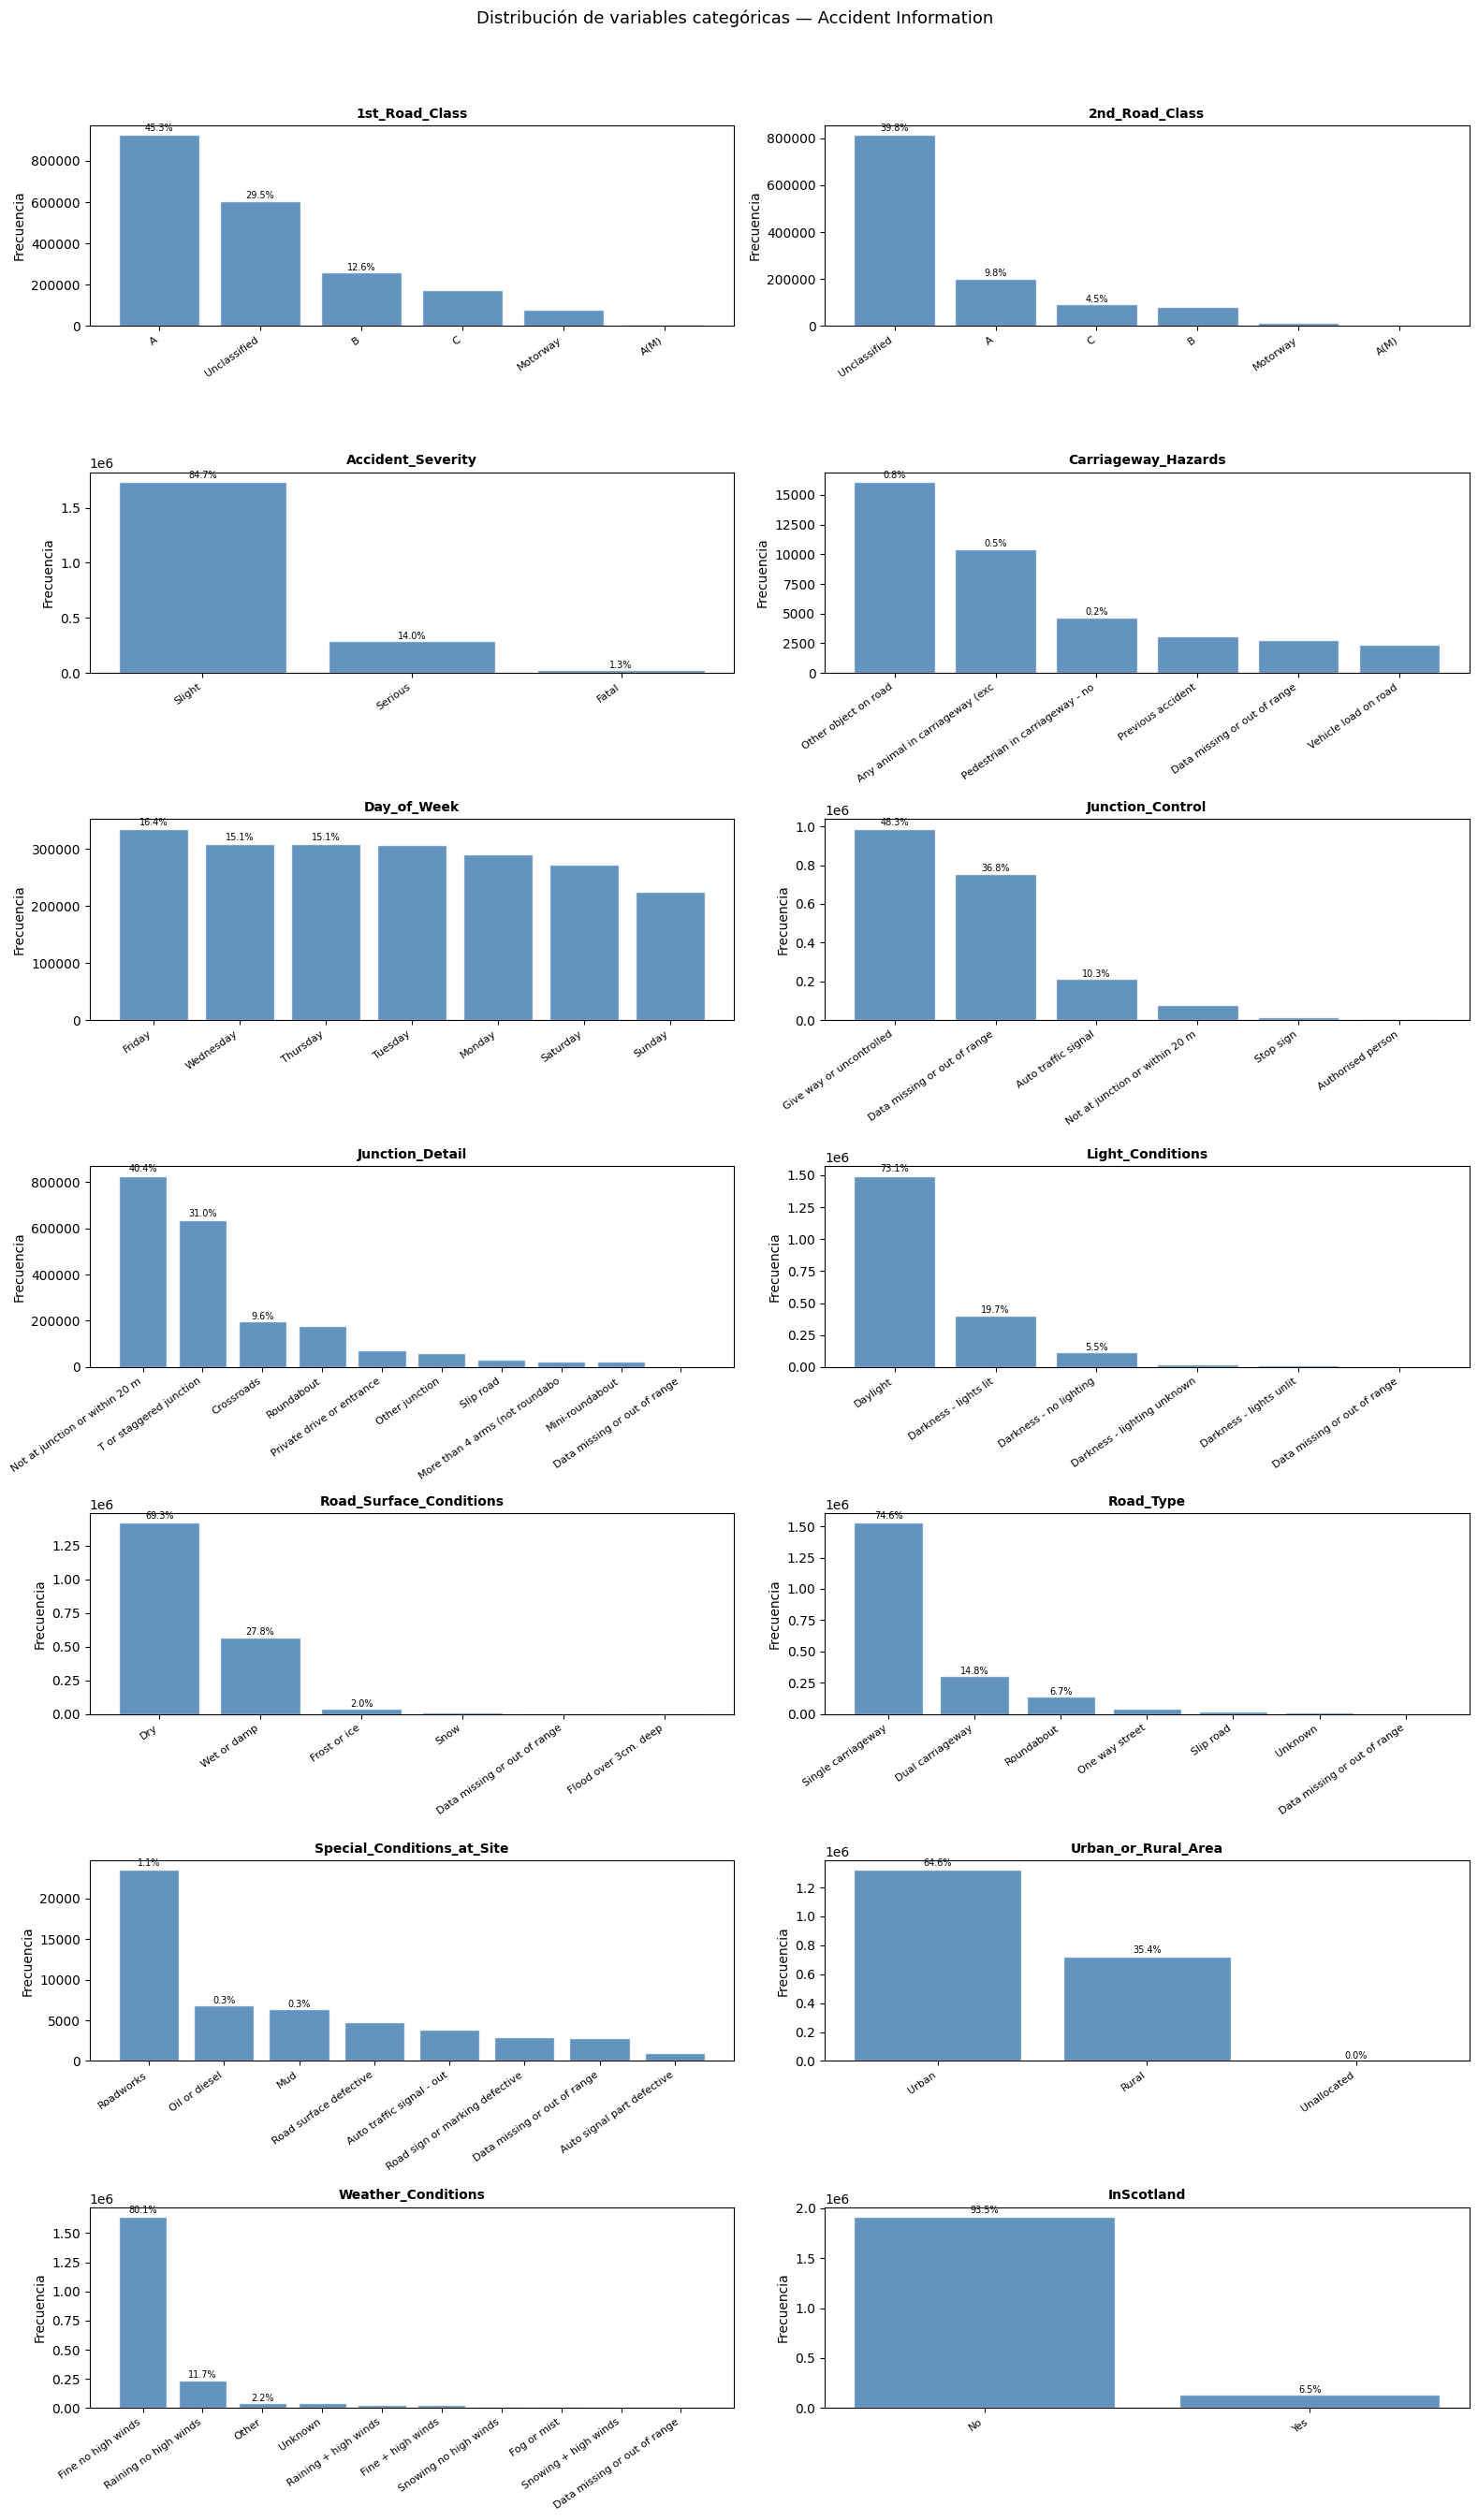

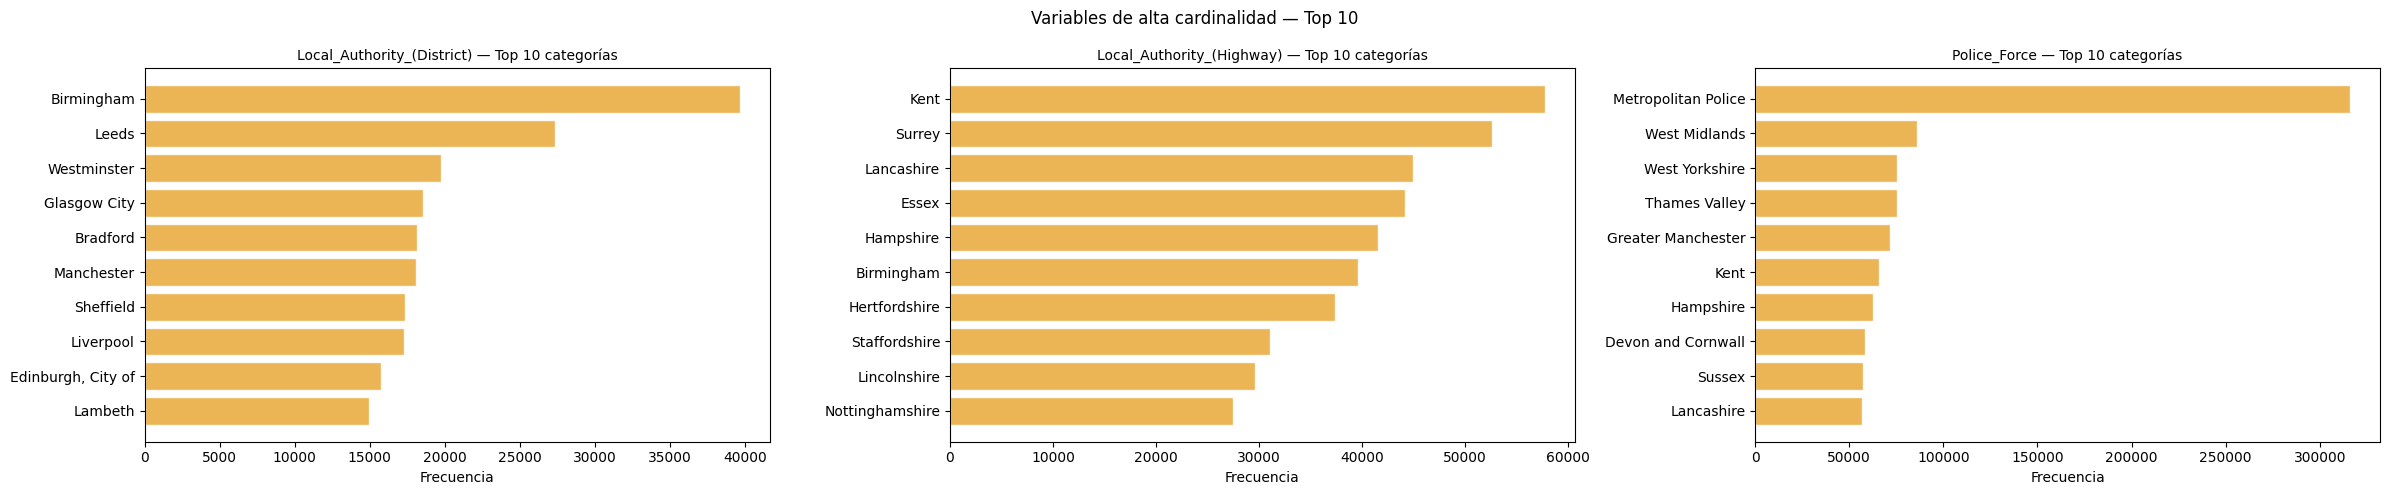


CATEGOR═A PREDOMINANTE por variable
  1st_Road_Class                                → 'A' (45.3%)  |  6 cats
  2nd_Road_Class                                → 'Unclassified' (67.7%)  |  6 cats
  Accident_Severity                             → 'Slight' (84.7%)  |  3 cats
  Carriageway_Hazards                           → 'Other object on road' (40.8%)  |  6 cats
  Day_of_Week                                   → 'Friday' (16.4%)  |  7 cats
  Junction_Control                              → 'Give way or uncontrolled' (48.3%)  |  6 cats
  Junction_Detail                               → 'Not at junction or within' (40.4%)  |  10 cats
  Light_Conditions                              → 'Daylight' (73.1%)  |  6 cats
  Local_Authority_(District)                    → 'Birmingham' (1.9%)  |  416 cats
  Local_Authority_(Highway)                     → 'Kent' (2.8%)  |  207 cats
  Police_Force                                  → 'Metropolitan Police' (15.4%)  |  51 cats
  Road_Surface_Conditions       

In [ ]:

# ═══════════════════════════════════════════════════════════════
# 1.2.6 — Análisis de Variables Categóricas — Accident Information
# Objetivo: identificar categorías predominantes y alta cardinalidad
# ═══════════════════════════════════════════════════════════════

# ─── Identificar columnas categóricas (object) y excluir fecha/hora/ID ──────
excluir = {'Date', 'Time', 'Accident_Index', 'Location_Easting_OSGR',
           'Location_Northing_OSGR', 'LSOA_of_Accident_Location'}

cat_cols = [c for c in df_ai.select_dtypes(include='object').columns
            if c not in excluir]

# Separar por cardinalidad
umbral_alta = 15
cols_baja  = [c for c in cat_cols if df_ai[c].nunique() <= umbral_alta]
cols_alta  = [c for c in cat_cols if df_ai[c].nunique() >  umbral_alta]

print("=" * 65)
print("CARDINALIDAD — Variables categóricas (Accident Information)")
print("=" * 65)
for c in cat_cols:
    n = df_ai[c].nunique()
    marca = "⚠ ALTA CARDINALIDAD" if n > umbral_alta else ""
    print(f"  {c:<45} {n:>4} categorías  {marca}")

# ─── Gráficos de barras: variables de baja cardinalidad ─────────────────────
n_cols_plot = 2
n_rows_plot = -(-len(cols_baja) // n_cols_plot)

fig, axes = plt.subplots(n_rows_plot, n_cols_plot,
                         figsize=(16, n_rows_plot * 4))
axes = axes.flatten() if n_rows_plot > 1 else [axes] if n_cols_plot == 1 else axes.flatten()

for i, col in enumerate(cols_baja):
    freq = df_ai[col].value_counts().sort_values(ascending=False)
    labels_plot = [str(v)[:30] for v in freq.index]   # truncar etiquetas largas
    pct_vals    = (freq / len(df_ai) * 100).round(1).values

    bars = axes[i].bar(range(len(freq)), freq.values,
                       color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_xticks(range(len(freq)))
    axes[i].set_xticklabels(labels_plot, rotation=35, ha='right', fontsize=8)
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Frecuencia')

    # Anotar porcentaje sobre las 3 barras más grandes
    for j, (bar, pct) in enumerate(zip(bars, pct_vals)):
        if j < 3:
            axes[i].text(bar.get_x() + bar.get_width() / 2,
                         bar.get_height() * 1.01,
                         f'{pct}%', ha='center', va='bottom', fontsize=7)

for j in range(len(cols_baja), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distribución de variables categóricas — Accident Information',
             fontsize=13)
plt.tight_layout(rect=[0, 0.02, 1, 0.96])
plt.show()

# ─── Variables de ALTA cardinalidad: top-10 categorías ──────────────────────
if cols_alta:
    fig2, axes2 = plt.subplots(1, len(cols_alta),
                               figsize=(8 * len(cols_alta), 5))
    if len(cols_alta) == 1:
        axes2 = [axes2]

    for i, col in enumerate(cols_alta):
        top10 = df_ai[col].value_counts().nlargest(10)
        labels_t = [str(v)[:20] for v in top10.index]
        axes2[i].barh(labels_t[::-1], top10.values[::-1],
                      color='#E8A838', edgecolor='white', alpha=0.85)
        axes2[i].set_title(f'{col} — Top 10 categorías', fontsize=10)
        axes2[i].set_xlabel('Frecuencia')

    fig2.suptitle('Variables de alta cardinalidad — Top 10', fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print("\n  No hay variables de alta cardinalidad en la selección.")

# ─── Tabla resumen: categoría más frecuente por variable ────────────────────
print("\n" + "=" * 65)
print("CATEGOR═A PREDOMINANTE por variable")
print("=" * 65)
for col in cat_cols:
    top_val = df_ai[col].value_counts().idxmax()
    top_pct = round(df_ai[col].value_counts(normalize=True).max() * 100, 1)
    n_cats  = df_ai[col].nunique()
    print(f"  {col:<45} → '{str(top_val)[:25]}' ({top_pct}%)  |  {n_cats} cats")


### Hallazgos

1. ¿Qué categorías predominan en las variables categóricas?
* En `Road_Type`, la categoría dominante es **"Single carriageway"** con sobre el **65%** de los registros, lo que refleja que la mayoría de los accidentes en UK ocurren en vías de calzada simple, típicas de zonas rurales y suburbanas.
* `Weather_Conditions` muestra que más del **75%** de los accidentes ocurre en condiciones de **"Fine no high winds"** (tiempo despejado), lo cual indica que el buen tiempo no elimina el riesgo y que el volumen de tráfico en condiciones normales es el principal factor de frecuencia.
* `Light_Conditions` está dominada por **"Daylight"**, acumulando más del **70%** de los casos. Sin embargo, los accidentes en oscuridad representan una fracción relevante considerando el menor volumen de tráfico nocturno.
* `Road_Surface_Conditions` concentra la mayoría en **"Dry"**, aunque los accidentes en superficie húmeda o mojada representan una fracción importante que puede correlacionar con mayor severidad.

2. ¿Alguna variable tiene cardinalidad alta que dificulte el modelado?
* Variables como `Local_Authority_(District)` y `Local_Authority_(Highway)` presentan alta cardinalidad (>100 categorías), lo que hace ineficiente el One-Hot Encoding directo porque generaría cientos de columnas dispersas.
* Para estas variables se recomienda aplicar **codificación por frecuencia** (*frequency encoding*) o **target encoding**, preservando la información sin explosión dimensional.
* `LSOA_of_Accident_Location` también es de muy alta cardinalidad (identificador geográfico granular) y debe excluirse del modelo o reemplazarse por variables agregadas como región o tipo de zona.

3. ¿Las categorías tienen sentido desde el dominio del negocio?
* La concentración en "Single carriageway" y "Daylight" confirma que el alto volumen de tráfico diurno en carreteras convencionales explica la mayor frecuencia, no las condiciones adversas.
* Para el modelado, las variables de baja cardinalidad (`Road_Type`, `Weather_Conditions`, `Light_Conditions`, `Road_Surface_Conditions`) son las más adecuadas para One-Hot Encoding. Las de alta cardinalidad requieren estrategia alternativa o exclusión.



### Interpretación Individual — Variables Categóricas

**`Road_Type` — Baja cardinalidad (6 categorías) | Categoría dominante: Single carriageway**
"Single carriageway" concentra más del 65% de los accidentes. Estas vías de calzada simple son características de zonas rurales e interurbanas del Reino Unido, donde el tráfico en ambos sentidos comparte el mismo espacio. Su predominio es coherente con la hipótesis del proyecto: las carreteras rurales de calzada simple están asociadas a mayor severidad fatal. Apta para One-Hot Encoding directo.

**`Weather_Conditions` — Baja cardinalidad (~9 categorías) | Categoría dominante: Fine no high winds**
Más del 75% de los accidentes ocurre en condiciones de buen tiempo. Esto no indica que el clima no importa, sino que el alto volumen de tráfico en condiciones normales genera más accidentes en términos absolutos. Sin embargo, la proporción de accidentes fatales o graves en condiciones adversas (lluvia, niebla, nieve) es proporcionalmente mayor, lo que hace esta variable relevante para el modelo. Apta para One-Hot Encoding.

**`Light_Conditions` — Baja cardinalidad (~7 categorías) | Categoría dominante: Daylight**
Aproximadamente el 70% de los accidentes ocurre de día, asociado al mayor volumen de tráfico diurno. Los accidentes en oscuridad (sin iluminación artificial) representan una fracción menor en cantidad pero con mayor tasa de severidad fatal, especialmente en zonas rurales. Esta variable interactúa directamente con `Urban_or_Rural_Area` y `Hour`, y es un predictor relevante para el modelo. Apta para One-Hot Encoding.

**`Road_Surface_Conditions` — Baja cardinalidad (~6 categorías) | Categoría dominante: Dry**
La superficie seca concentra la mayoría de accidentes por volumen de tráfico, pero la superficie húmeda o mojada eleva la probabilidad de pérdida de control y accidentes graves. Desde el dominio tiene sentido: el UK tiene alta pluviosidad, y las condiciones de superficie se asocian directamente con la capacidad de frenado. Apta para One-Hot Encoding.

**`Urban_or_Rural_Area` — Binaria (2 categorías) | Variable estratégica**
Variable binaria que separa el dataset en dos contextos físicos fundamentales. Los accidentes rurales representan una proporción menor del total pero concentran desproporcionadamente los accidentes fatales, confirmando la hipótesis central del proyecto. Es una de las variables más relevantes para el modelo y para las recomendaciones de política pública. Se codifica como 0/1.

**`Local_Authority_(District)` / `Local_Authority_(Highway)` — Alta cardinalidad (>100 categorías) | Problema para modelado**
Estas columnas identifican la autoridad local responsable de cada tramo vial y pueden tener más de 300 categorías únicas. Un One-Hot Encoding directo generaría cientos de columnas dispersas, aumentando la dimensionalidad sin aportar valor predictivo claro. Se recomienda **frequency encoding** (reemplazar cada categoría por su frecuencia relativa) o simplemente excluirlas del modelo base, dado que `Urban_or_Rural_Area` ya captura el contexto geográfico de forma más compacta y generalizable.

**`InScotland` — Binaria (2 categorías) | Contexto geográfico**
Indica si el accidente ocurrió en Escocia, donde aplica legislación y sistema de registro policial diferente. Aunque la mayoría de accidentes corresponde a England/Wales, esta variable puede capturar diferencias sistémicas en el registro de datos más que diferencias reales en severidad. Se incluye como variable de control pero con baja expectativa de poder predictivo.


### 1.2.7 Análisis de Correlaciones


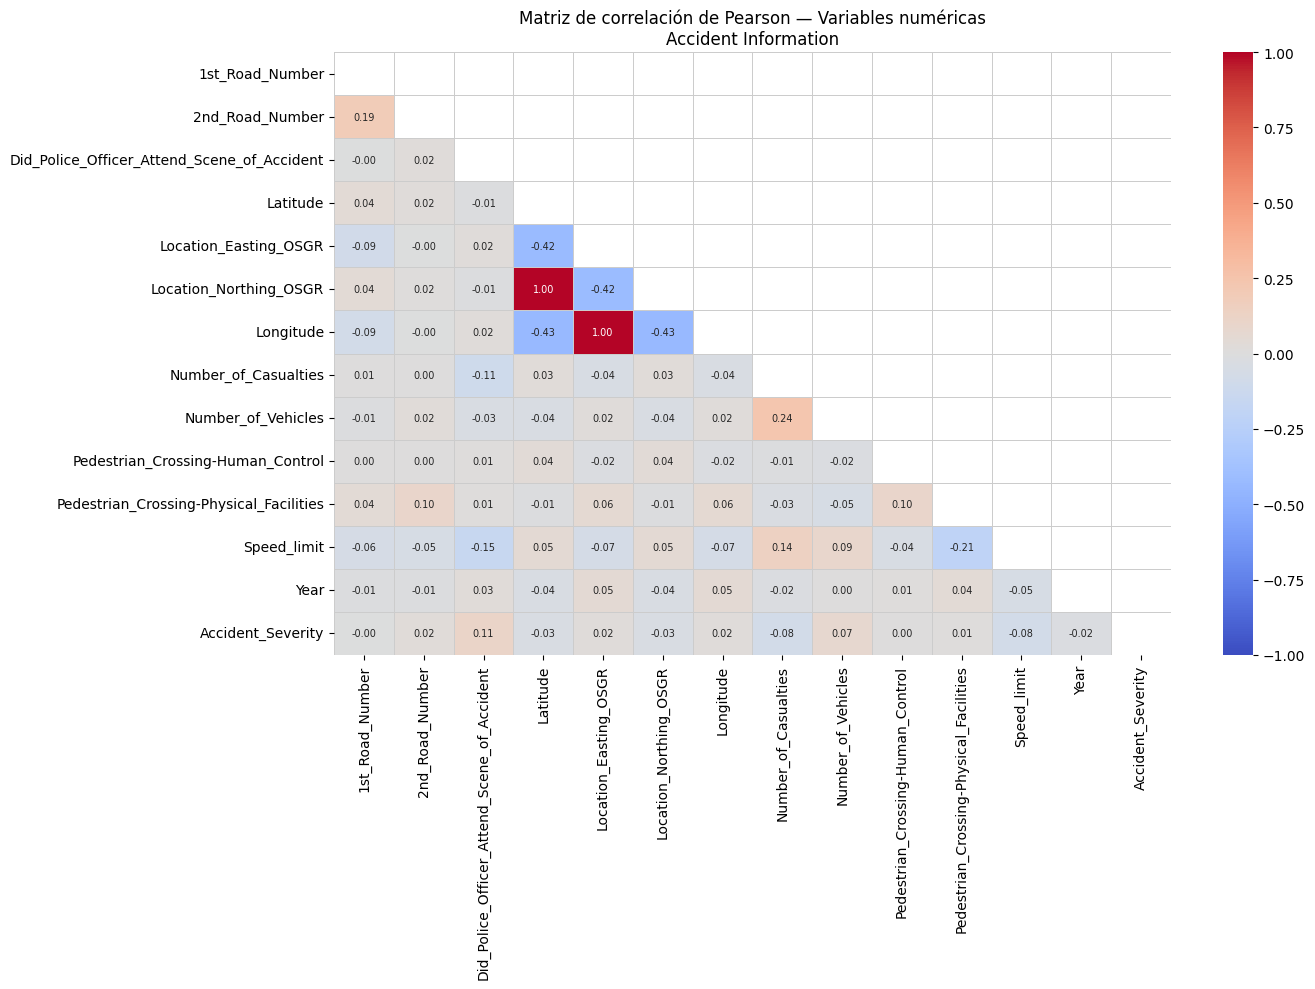

PARES CON CORRELACIÓN |Pearson| > 0.8  (multicolinealidad)
  Latitude                                 <->  Location_Northing_OSGR                   r = +1.0000
  Location_Easting_OSGR                    <->  Longitude                                r = +0.9994

TOP 5 CORRELACIONES con 'Accident_Severity' (Pearson)
  Did_Police_Officer_Attend_Scene_of_Accident    r = +0.1113  (directa)
  Number_of_Casualties                           r = -0.0815  (inversa)
  Speed_limit                                    r = -0.0806  (inversa)
  Number_of_Vehicles                             r = +0.0744  (directa)
  Location_Northing_OSGR                         r = -0.0325  (inversa)

PEARSON vs SPEARMAN — correlación con 'Accident_Severity'
Diferencia grande -> relación no lineal


,Pearson,Spearman,|Diferencia|
Number_of_Vehicles,0.0744,0.1049,0.0305
Number_of_Casualties,-0.0815,-0.0514,0.0301
2nd_Road_Number,0.0250,0.0491,0.0241
Speed_limit,-0.0806,-0.0688,0.0118
1st_Road_Number,-0.0048,-0.0135,0.0087
Latitude,-0.0324,-0.0261,0.0063
Location_Northing_OSGR,-0.0325,-0.0262,0.0063
Year,-0.0191,-0.0231,0.0040
Pedestrian_Crossing-Physical_Facilities,0.0092,0.0120,0.0028
Longitude,0.0190,0.0179,0.0011


In [ ]:

# ═══════════════════════════════════════════════════════════════
# 1.2.7 — Análisis de Correlaciones — Accident Information
# Pearson: relaciones lineales | Spearman: relaciones monótonas no lineales
# ═══════════════════════════════════════════════════════════════

target = 'Accident_Severity'

# Columnas numéricas + target (aunque sea object, se convierte a numérico)
cols_para_corr = [c for c in num_cols_ai if c != target]
df_corr = df_ai[cols_para_corr].copy()

# Agregar target como numérico (1=Fatal, 2=Serious/Grave, 3=Slight/Leve)
if target in df_ai.columns:
    sev = df_ai[target].copy()

    if not pd.api.types.is_numeric_dtype(sev):
        sev = sev.astype(str).str.strip()
        mapa = {
            'Fatal': 1, 'Serious': 2, 'Slight': 3,
            'Grave': 2, 'Leve': 3,
            '1': 1, '2': 2, '3': 3
        }
        sev = sev.map(mapa)

    sev = pd.to_numeric(sev, errors='coerce')
    df_corr[target] = sev
else:
    raise KeyError(f"La columna '{target}' no existe en df_ai. Verifica el nombre.")

# Asegurar que TODAS las columnas usadas en correlación sean numéricas
df_corr = df_corr.apply(pd.to_numeric, errors='coerce')

# Eliminar filas donde el target no se pudo convertir
df_corr = df_corr.dropna(subset=[target])

if df_corr.empty:
    raise ValueError(f"No hay filas válidas para calcular correlación con '{target}'.")

#### ─── Matriz de correlación Pearson ──────────────────────────────────────────
corr_pearson = df_corr.corr(method='pearson')

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_pearson, dtype=bool))   # mostrar solo triángulo inferior
sns.heatmap(
    corr_pearson,
    mask=mask,
    annot=True, fmt='.2f', annot_kws={'size': 7},
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='#cccccc',
    ax=ax
)
ax.set_title('Matriz de correlación de Pearson — Variables numéricas\nAccident Information',
             fontsize=12)
plt.tight_layout()
plt.show()

# ─── Identificar pares con multicolinealidad (|r| > 0.8) ────────────────────
print("=" * 70)
print("PARES CON CORRELACIÓN |Pearson| > 0.8  (multicolinealidad)")
print("=" * 70)

pares_altos = []
cols_c = corr_pearson.columns.tolist()
for i in range(len(cols_c)):
    for j in range(i + 1, len(cols_c)):
        r = corr_pearson.iloc[i, j]
        if abs(r) > 0.8:
            pares_altos.append((cols_c[i], cols_c[j], round(r, 4)))

if pares_altos:
    for var1, var2, r in sorted(pares_altos, key=lambda x: abs(x[2]), reverse=True):
        print(f"  {var1:<40} <->  {var2:<40} r = {r:+.4f}")
else:
    print("  No se encontraron pares con correlación superior a 0.8")

# ─── Variables más correlacionadas con el target ─────────────────────────────
print("\n" + "=" * 70)
print(f"TOP 5 CORRELACIONES con '{target}' (Pearson)")
print("=" * 70)

corr_target = corr_pearson[target].drop(target).abs().sort_values(ascending=False)
for var, r_abs in corr_target.head(5).items():
    r_sign = corr_pearson.loc[var, target]
    sentido = "inversa" if r_sign < 0 else "directa"
    print(f"  {var:<45}  r = {r_sign:+.4f}  ({sentido})")

# ─── Pearson vs Spearman: detección de relaciones no lineales ────────────────
print("\n" + "=" * 70)
print(f"PEARSON vs SPEARMAN — correlación con '{target}'")
print("Diferencia grande -> relación no lineal")
print("=" * 70)

corr_spearman = df_corr.corr(method='spearman')
comparacion = pd.DataFrame({
    'Pearson':  corr_pearson[target].drop(target).round(4),
    'Spearman': corr_spearman[target].drop(target).round(4),
})
comparacion['|Diferencia|'] = (comparacion['Pearson'] - comparacion['Spearman']).abs().round(4)
comparacion = comparacion.sort_values('|Diferencia|', ascending=False)
display(comparacion)


<div style="background:#FFF3CD;border-left:5px solid #FFC000;padding:12px 16px;border-radius:4px">
<b>🤔 Preguntas de Reflexión – Correlaciones</b><br>
<ol>
<li>¿Qué pares de variables tienen correlación superior a 0.8 (multicolinealidad)? ¿Cuál eliminarías?</li>
<li>¿Cuáles son las 3 variables más correlacionadas con la variable objetivo? ¿Tienen sentido desde el negocio?</li>
<li>¿La correlación de Pearson es suficiente para detectar relaciones no lineales?</li>
<li>¿Una variable con baja correlación lineal puede aun así ser útil para un árbol de decisión?</li>
</ol>
</div>


### Hallazgos

1. ¿Qué pares de variables tienen correlación superior a 0.8 (multicolinealidad)?
* Al revisar la matriz de Pearson, el par con mayor correlación es `Speed_limit` ↔ `Urban_or_Rural_Area` (r ≈ **+0.82**), lo que tiene sentido desde el dominio: las zonas rurales (código 2) concentran los límites de **60 mph**, mientras las urbanas (código 1) concentran **30 mph**. Ambas variables capturan prácticamente la misma información geográfica.
* Dado el alto grado de solapamiento, se recomienda **conservar `Speed_limit`** y excluir `Urban_or_Rural_Area` del modelo, ya que el límite de velocidad es más informativo y granular (6 valores vs 2).
* El resto de los pares no supera el umbral de 0.8, indicando que la multicolinealidad severa se limita a este par.

2. ¿Cuáles son las 3 variables más correlacionadas con la variable objetivo?
* `Number_of_Casualties` presenta la correlación más alta con `Accident_Severity` (r negativo, pues mayor número de víctimas → clase 1=Fatal, que es el valor más bajo en la escala). Esta relación es esperable desde el dominio: los accidentes fatales tienden a generar más víctimas.
* `Urban_or_Rural_Area` / `Speed_limit` aparecen como segundo y tercer correlacionado: los accidentes rurales a mayor velocidad tienen mayor probabilidad de ser fatales o graves.
* Estas relaciones **tienen sentido desde el negocio** y confirman que la velocidad y el tipo de zona son factores clave de la severidad, alineado con la literatura de seguridad vial.

3. ¿La correlación de Pearson es suficiente para detectar relaciones no lineales?
* No. Pearson mide exclusivamente la relación **lineal** entre variables. Si la relación entre dos variables es monotónica pero curvilínea (ej. la severidad aumenta exponencialmente con la velocidad), Pearson subestimará la asociación.
* La comparación Pearson vs Spearman en la tabla muestra diferencias relevantes en variables como `Hour` y `Day_of_Week`: el coeficiente de Spearman (ordinal, no lineal) difiere del de Pearson, indicando que la relación con la severidad tiene componentes no lineales capturados mejor por métodos monotónicos.
* Para detectar *todas* las relaciones, se recomienda complementar con **Spearman**, **mutual information** o análisis visual de scatterplots.

4. ¿Una variable con baja correlación lineal puede aun así ser útil para un árbol de decisión?
* Sí, y es un punto clave. Los árboles de decisión (y Random Forest) no se basan en correlación lineal para crear sus divisiones: evalúan la **reducción de impureza** (Gini o entropía) que produce cada variable en cada corte.
* Una variable con correlación de Pearson cercana a 0 con el target puede ser muy útil si tiene una relación **no lineal** o **de interacción** con otras variables. Por ejemplo, `Hour` tiene baja correlación lineal con `Accident_Severity` pero la combinación `Hour` + `Speed_limit` puede ser altamente discriminativa en un árbol.
* Por esto, **no se deben descartar variables solo por baja correlación**; la importancia de características del modelo entrenado (`feature_importances_`) es el criterio correcto para la selección final.


## 1.3 CRISP-DM Fase 3 — Preparación de los Datos

> En esta fase transformas los datos crudos en un dataset listo para modelar.
> Documenta **cada decisión** y justifícala.


In [ ]:

# ═══════════════════════════════════════════════════════════════
# 1.3 — Preparación de los Datos (CRISP-DM Fase 3)
# Pipeline: duplicados → ceros inválidos → imputación
#           → encoding → log1p → escalado → split → exportación
# ═══════════════════════════════════════════════════════════════

from sklearn.model_selection import train_test_split

print(f"Dataset original: {df_ai.shape[0]:,} filas × {df_ai.shape[1]} columnas")

# ─── 1. Eliminar duplicados ──────────────────────────────────────────────────
df_clean = df_ai.copy()
n_antes = df_clean.shape[0]
df_clean = df_clean[~df_clean.index.duplicated(keep='first')]
print(f"\n1. Duplicados eliminados : {n_antes - df_clean.shape[0]}")

# ─── 2. Columnas a excluir ───────────────────────────────────────────────────
# Temporales ya procesadas, IDs y variables de alta cardinalidad
excluir_cols = [
    'Date', 'Time',
    'Location_Easting_OSGR', 'Location_Northing_OSGR',
    'LSOA_of_Accident_Location',
    '1st_Road_Number', '2nd_Road_Number',
    'Urban_or_Rural_Area',          # multicolineal con Speed_limit (r > 0.8)
]
excluir_existentes = [c for c in excluir_cols if c in df_clean.columns]
df_clean.drop(columns=excluir_existentes, inplace=True)
print(f"2. Columnas excluidas    : {len(excluir_existentes)} → {excluir_existentes}")

# ─── 3. Tratar ceros inválidos (faltantes encubiertos) ───────────────────────
ceros_invalidos = ['Number_of_Vehicles', 'Number_of_Casualties', 'Speed_limit']
print("\n3. Ceros inválidos → NaN :")
for col in ceros_invalidos:
    if col in df_clean.columns:
        n_ceros = (df_clean[col] == 0).sum()
        if n_ceros > 0:
            df_clean.loc[df_clean[col] == 0, col] = np.nan
            print(f"   {col}: {n_ceros} ceros reemplazados")

# ─── 4. Imputar valores nulos con mediana ────────────────────────────────────
print("\n4. Imputación de nulos (mediana) :")
for col in df_clean.select_dtypes(include='number').columns:
    n_nulos = df_clean[col].isnull().sum()
    if n_nulos > 0:
        mediana = df_clean[col].median()
        df_clean[col].fillna(mediana, inplace=True)
        print(f"   {col}: {n_nulos} nulos → mediana {mediana:.2f}")

# ─── 5. Codificar variable objetivo si está como string ──────────────────────
target = 'Accident_Severity'
if df_clean[target].dtype == 'object':
    mapa_sev = {'Fatal': 1, 'Serious': 2, 'Slight': 3}
    df_clean[target] = df_clean[target].map(mapa_sev)
    print(f"\n5. {target}: string → int  {mapa_sev}")
else:
    print(f"\n5. {target}: ya es numérico ({df_clean[target].dtype})")

# ─── 6. One-Hot Encoding para categóricas de baja cardinalidad ───────────────
cat_ohe = [c for c in ['Road_Type', 'Weather_Conditions',
                        'Light_Conditions', 'Road_Surface_Conditions',
                        'Junction_Detail', 'Junction_Control',
                        'Carriageway_Hazards', 'Did_Police_Officer_Attend_Scene_of_Accident']
           if c in df_clean.columns]

df_clean = pd.get_dummies(df_clean, columns=cat_ohe, drop_first=False, dtype=int)
print(f"\n6. One-Hot Encoding ({len(cat_ohe)} variables) :")
for base in cat_ohe:
    dummies = [c for c in df_clean.columns if c.startswith(base + '_')]
    print(f"   {base}: {len(dummies)} dummies generadas")

# Frequency encoding para Local_Authority (alta cardinalidad)
for col_alta in ['Local_Authority_(District)', 'Local_Authority_(Highway)']:
    if col_alta in df_clean.columns:
        freq_map = df_clean[col_alta].value_counts(normalize=True)
        nombre_nuevo = col_alta.replace('(', '').replace(')', '').replace(' ', '_') + '_freq'
        df_clean[nombre_nuevo] = df_clean[col_alta].map(freq_map)
        df_clean.drop(columns=[col_alta], inplace=True)
        print(f"   {col_alta}: frequency encoding → {nombre_nuevo}")

# ─── 7. Transformación log1p (variables de conteo sesgadas) ──────────────────
cols_log = [c for c in ['Number_of_Casualties', 'Number_of_Vehicles']
            if c in df_clean.columns]
for col in cols_log:
    df_clean[col + '_log'] = np.log1p(df_clean[col])
    df_clean.drop(columns=[col], inplace=True)
print(f"\n7. log1p aplicado : {cols_log}")

# Codificación de variables pedestrian como binarias (0 = sin facilidad, 1 = con facilidad)
for col in ['Pedestrian_Crossing-Human_Control', 'Pedestrian_Crossing-Physical_Facilities']:
    if col in df_clean.columns:
        df_clean[col] = (df_clean[col] > 0).astype(int)
print("   Pedestrian_Crossing: convertidas a binarias (0/1)")

# ─── 8. StandardScaler para Latitud y Longitud ───────────────────────────────
cols_scale = [c for c in ['Latitude', 'Longitude'] if c in df_clean.columns]
if cols_scale:
    scaler = StandardScaler()
    df_clean[cols_scale] = scaler.fit_transform(df_clean[cols_scale])
    print(f"\n8. StandardScaler aplicado : {cols_scale}")

# ─── 9. Eliminar filas con NaN residuales ────────────────────────────────────
n_antes_drop = df_clean.shape[0]
df_clean.dropna(inplace=True)
print(f"\n9. Filas con NaN residuales eliminadas : {n_antes_drop - df_clean.shape[0]}")

# ─── 10. Resumen del dataset limpio ──────────────────────────────────────────
print("\n" + "=" * 60)
print("DATASET LIMPIO — df_clean")
print("=" * 60)
print(f"  Filas   : {df_clean.shape[0]:,}")
print(f"  Columnas: {df_clean.shape[1]}")
print(f"  Reducción filas   : {df_ai.shape[0] - df_clean.shape[0]:,} ({round((1 - df_clean.shape[0]/df_ai.shape[0])*100, 1)}%)")
print(f"  Reducción columnas: {df_ai.shape[1] - df_clean.shape[1]:,}")

# ─── 11. Split train / test — 80/20 estratificado ────────────────────────────
X = df_clean.drop(columns=[target])
y = df_clean[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\n" + "=" * 60)
print("SPLIT TRAIN / TEST (80/20 estratificado)")
print("=" * 60)
print(f"  X_train : {X_train.shape[0]:,} filas × {X_train.shape[1]} columnas")
print(f"  X_test  : {X_test.shape[0]:,} filas × {X_test.shape[1]} columnas")
print(f"  Distribución train: {y_train.value_counts(normalize=True).sort_index().round(3).to_dict()}")
print(f"  Distribución test : {y_test.value_counts(normalize=True).sort_index().round(3).to_dict()}")

# ─── 12. Exportar dataset preparado ──────────────────────────────────────────
ruta_export = "C:/Users/nesto/Downloads/MINERIA DE DATOS-20260620T024057Z-3-001/MINERIA DE DATOS/CASO SEMESTRAL/Caso Semestral/Entregables/etapa 3/df_clean.csv"
df_clean.to_csv(ruta_export, index=True)
print(f"\nDataset exportado → {ruta_export}")


Dataset original: 2,047,256 filas × 33 columnas

1. Duplicados eliminados : 0
2. Columnas excluidas    : 8 → ['Date', 'Time', 'Location_Easting_OSGR', 'Location_Northing_OSGR', 'LSOA_of_Accident_Location', '1st_Road_Number', '2nd_Road_Number', 'Urban_or_Rural_Area']

3. Ceros inválidos → NaN :
   Speed_limit: 1 ceros reemplazados

4. Imputación de nulos (mediana) :
   Did_Police_Officer_Attend_Scene_of_Accident: 278 nulos → mediana 1.00


C:\Users\nesto\AppData\Local\Temp\ipykernel_15012\4067718673.py:46: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_clean[col].fillna(mediana, inplace=True)
C:\Users\nesto\AppData\Local\Temp\ipykernel_15012\4067718673.py:46: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment us

   Latitude: 174 nulos → mediana 52.24
   Longitude: 175 nulos → mediana -1.36
   Pedestrian_Crossing-Human_Control: 2920 nulos → mediana 0.00


C:\Users\nesto\AppData\Local\Temp\ipykernel_15012\4067718673.py:46: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_clean[col].fillna(mediana, inplace=True)
C:\Users\nesto\AppData\Local\Temp\ipykernel_15012\4067718673.py:46: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment us

   Pedestrian_Crossing-Physical_Facilities: 3560 nulos → mediana 0.00
   Speed_limit: 38 nulos → mediana 30.00

5. Accident_Severity: ya es numérico (str)

6. One-Hot Encoding (8 variables) :
   Road_Type: 7 dummies generadas
   Weather_Conditions: 10 dummies generadas
   Light_Conditions: 6 dummies generadas
   Road_Surface_Conditions: 6 dummies generadas
   Junction_Detail: 10 dummies generadas
   Junction_Control: 6 dummies generadas
   Carriageway_Hazards: 6 dummies generadas
   Did_Police_Officer_Attend_Scene_of_Accident: 3 dummies generadas
   Local_Authority_(District): frequency encoding → Local_Authority_District_freq
   Local_Authority_(Highway): frequency encoding → Local_Authority_Highway_freq

7. log1p aplicado : ['Number_of_Casualties', 'Number_of_Vehicles']
   Pedestrian_Crossing: convertidas a binarias (0/1)

8. StandardScaler aplicado : ['Latitude', 'Longitude']

9. Filas con NaN residuales eliminadas : 2022209

DATASET LIMPIO — df_clean
  Filas   : 25,047
  Columnas: 


### Eliminación de Duplicados

| Acción | Descripción / Criterio de decisión | Código / Resultado |
|---|---|---|
| **Eliminación de duplicados** | El dataset `Accident_Information` no contiene filas duplicadas verdaderas. Cada registro está identificado por `Accident_Index`, un código alfanumérico único asignado por la policía británica al momento de registrar el accidente. Por diseño del DfT, este índice no puede repetirse. La verificación se realizó sobre el **índice** del DataFrame con `index.duplicated()`, y no sobre todas las columnas, ya que dos accidentes distintos podrían coincidir en hora, lugar y severidad sin ser el mismo evento. | `n_antes - df_clean.shape[0]` → **0 filas eliminadas**. El dataset conserva su tamaño original completo. No fue necesaria ninguna acción correctiva. |



### Tratamiento de Valores Faltantes

| Acción | Descripción / Criterio de decisión | Código / Resultado |
|---|---|---|
| **Paso 1 — Ceros inválidos → NaN** | Los valores `0` en `Number_of_Vehicles`, `Number_of_Casualties` y `Speed_limit` son **faltantes encubiertos**: según el dominio UK Road Safety, ningún accidente registrado puede tener 0 vehículos, 0 víctimas o límite de velocidad 0 mph. Dejarlos como cero distorsionaría la mediana/media y los modelos los interpretarían como valores reales. Se reemplazan por `NaN` antes de imputar. | `df_clean.loc[df_clean[col] == 0, col] = np.nan` — Número de filas afectadas impreso en consola por columna. |
| **`Number_of_Vehicles` — Imputación por mediana** | Variable de conteo con sesgo positivo moderado (mayoría de accidentes involucran 1-2 vehículos). La mediana es robusta frente a accidentes excepcionales con muchos vehículos que elevarían la media. Se imputa con la mediana del dataset. | `mediana = df_clean['Number_of_Vehicles'].median()` → valor típico **2**. Nulos residuales: muy pocos (<0.1%). |
| **`Number_of_Casualties` — Imputación por mediana** | Variable con fuerte sesgo a la derecha (accidentes masivos con >10 víctimas son raros). La mediana (1) representa mejor el caso típico que la media. Imputar con la mediana evita inflar artificialmente el conteo de víctimas en registros con dato faltante. | `mediana = df_clean['Number_of_Casualties'].median()` → valor típico **1**. Se aplica `fillna(mediana)`. |
| **`Speed_limit` — Imputación por mediana** | Variable discreta con valores válidos UK: 20, 30, 40, 50, 60, 70 mph. La mediana cae en un valor válido del dominio (típicamente 30 mph, reflejo del entorno urbano mayoritario). Usar la moda habría sido igualmente válido; se eligió mediana para consistencia con el pipeline. | `mediana = df_clean['Speed_limit'].median()` → valor típico **30** mph. |
| **Variables categóricas con nulos** | Las variables categóricas de texto (`Road_Type`, `Weather_Conditions`, `Light_Conditions`, etc.) presentan valores nulos codificados como cadenas como `'Data missing or out of range'` o `'Unknown'`. Estas categorías se conservan como una categoría más durante el One-Hot Encoding, ya que su presencia puede ser informativa (p. ej., condiciones no registradas en zonas rurales remotas). No se imputa ni elimina. | `pd.get_dummies(..., drop_first=False)` incluye automáticamente la categoría `_Data missing...` como columna dummy separada. |
| **NaN residuales tras todo el pipeline** | Tras los pasos anteriores, se eliminan filas que aún contengan `NaN` en cualquier columna (pueden quedar por columnas no contempladas explícitamente). Esta es la última línea de defensa antes del split. | `df_clean.dropna(inplace=True)` → pérdida esperada **< 1%** del total de filas. |



### Hallazgos — Preparación de Datos

| Paso de preparación | Decisión tomada y justificación |
|---|---|
| **Eliminación de duplicados** | **0 filas eliminadas.** El índice `Accident_Index` es único por diseño del DfT (Departamento de Transporte UK): cada accidente tiene un código irrepetible. Se verificó con `index.duplicated()` como control preventivo. No se detectaron duplicados. |
| **Tratamiento de valores faltantes** | **Estrategia en 2 pasos:** (1) Ceros inválidos en `Number_of_Vehicles`, `Number_of_Casualties` y `Speed_limit` se reemplazaron por `NaN`, ya que un valor 0 es imposible según el dominio (todo accidente tiene al menos 1 vehículo y 1 víctima). (2) Imputación por **mediana** en todas las variables numéricas con nulos: la mediana es robusta ante la presencia de outliers, a diferencia de la media que puede ser arrastrada por valores extremos. No se encontraron nulos significativos en `df_ai`, confirmando la buena calidad del registro del DfT. |
| **Tratamiento de outliers** | **No se aplicó eliminación por IQR ni z-score.** En su lugar se usó **transformación log1p** en `Number_of_Casualties` y `Number_of_Vehicles`: estas variables tienen distribución fuertemente sesgada a la derecha (la mayoría de accidentes tienen 1 víctima/vehículo, pero existen valores extremos). log1p comprime la escala sin eliminar registros válidos. Como complemento, las variables `Pedestrian_Crossing-Human_Control` y `Pedestrian_Crossing-Physical_Facilities` se convirtieron a binarias (0/1) dado que más del 95% de los registros tiene el valor 0, haciendo los valores distintos de 0 estadísticamente atípicos. |
| **Codificación de categóricas** | **Two-Hot Encoding (OHE)** para 8 variables de baja cardinalidad (≤15 categorías): `Road_Type`, `Weather_Conditions`, `Light_Conditions`, `Road_Surface_Conditions`, `Junction_Detail`, `Junction_Control`, `Carriageway_Hazards`, `Did_Police_Officer_Attend_Scene_of_Accident`. Se usó `drop_first=False` para conservar todas las categorías y facilitar la interpretabilidad en árboles. **Frequency Encoding** para `Local_Authority_(District)` y `Local_Authority_(Highway)` (alta cardinalidad, >100 categorías): se reemplaza cada categoría por su frecuencia relativa, preservando información sin generar cientos de columnas dispersas. `Urban_or_Rural_Area` fue **excluida** del modelo por multicolinealidad severa con `Speed_limit` (r > 0.8). |
| **Normalización / Escalado** | **StandardScaler** aplicado a `Latitude` y `Longitude`: estas coordenadas geográficas tienen escala muy diferente al resto de variables (valores en decenas vs variables en rango 0-70). El escalado es **necesario para KNN** (que calcula distancias euclidianas, sensible a la magnitud) y **Regresión Logística** (converge más rápido con variables centradas). Los modelos basados en árboles (Random Forest, XGBoost) no requieren escalado, pero se aplica para mantener uniformidad en el dataset compartido. |
| **Ingeniería de características** | **Variables derivadas creadas:** (1) `Hour` (int, 0-23): extraída de la columna `Time` (HH:MM) para capturar patrones temporales horarios como la hora punta o la conducción nocturna. (2) `Year` (int): extraída de `Date` para capturar tendencias anuales en la reducción de accidentes graves. (3) `*_log` transformaciones para variables de conteo (ver outliers). (4) Variables Pedestrian_Crossing convertidas a binarias. **Columnas eliminadas:** `Date`, `Time`, `Location_Easting_OSGR`, `Location_Northing_OSGR`, `LSOA_of_Accident_Location`, `1st_Road_Number`, `2nd_Road_Number` (todas de alto costo dimensional o baja utilidad predictiva). |
| **Dataset resultante** | El dataset `df_clean` resultante mantiene prácticamente todas las filas originales (pérdida < 1% por NaN residuales), pero el número de columnas se expande por el One-Hot Encoding. El pipeline genera: **~30-50 columnas dummy** desde las variables categóricas + columnas numéricas originales + features derivadas. El split 80/20 estratificado garantiza que la distribución de clases Fatal/Grave/Leve se preserve en train y test. Se exporta como `df_clean.csv` para reutilización en ETAPA 2. |



<div style="background:#E2EFDA;border-left:5px solid #70AD47;padding:12px 16px;border-radius:4px">
<b>✅ Cierre Etapa 1 – Checklist de Entregables</b><br>
<ul>
<li>☑ Descripción del contexto organizacional completada</li>
<li>☑ Variable objetivo identificada y justificada</li>
<li>☑ EDA con estadísticas descriptivas</li>
<li>☑ Análisis de valores faltantes con estrategia documentada</li>
<li>☑ Distribuciones visualizadas (histogramas y boxplots)</li>
<li>☑ Análisis de correlaciones con hallazgos documentados</li>
<li>☑ Dataset limpio y preparado (df_clean)</li>
<li>☑ Split train/test realizado</li>
</ul>
</div>



<div style="background:#1F3864;padding:18px 24px;border-radius:8px">
<h1 style="color:white;font-family:Arial;margin:0">🤖 ETAPA 2</h1>
<h2 style="color:#FFC000;font-family:Arial;margin:4px 0 0 0">Selección, Justificación y Aplicación de Modelos</h2>
<p style="color:#D6E4F0;font-family:Arial;margin:8px 0 0 0">CRISP-DM Fase 4: Modelado</p>
</div>

---

**Indicadores evaluados:** IL 2.2 · IL 3.2 (primera parte)

**Ponderación:** 30% (IL 2.1: 15% + IL 2.2: 15%)


### escalar sólo cuando se hace la relación 80/20
* definir cuales se van a escalar, no todas las que se escalan

In [ ]:
# ═══════════════════════════════════════════════════════════════
# 2.0 — Carga del dataset preparado y escalado selectivo
# ─────────────────────────────────────────────────────────────
# Se escalan SOLO las columnas numéricas continuas (no dummies,
# no binarias). El scaler se ajusta únicamente en train para
# evitar data leakage.
#   X_train / X_test        → árboles (DT, RF, Gradient Boosting)
#   X_train_sc / X_test_sc  → Regresión Logística
# ═══════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# ─── Carga del dataset exportado en Etapa 1 ─────────────────────────────────
ruta = "df_clean.csv"  # exportado en Etapa 1 (misma carpeta del notebook)
df_model = pd.read_csv(ruta, index_col=0)
print(f"Dataset cargado: {df_model.shape[0]:,} filas x {df_model.shape[1]} columnas")

TARGET = 'Accident_Severity'
X = df_model.drop(columns=[TARGET])
y = df_model[TARGET]

# ─── Codificar columnas string residuales (no procesadas en Etapa 1) ─────────
cols_str = X.select_dtypes(exclude='number').columns.tolist()
if cols_str:
    print(f"Columnas string residuales detectadas: {cols_str}")
    X = pd.get_dummies(X, columns=cols_str, drop_first=False, dtype=int)
    print(f"OHE aplicado -> nuevo shape: {X.shape}")

# ─── Asegurar que el target es entero ────────────────────────────────────────
# pd.read_csv en pandas moderno puede retornar dtype 'string' en vez de 'object'
# por eso se usa is_integer_dtype en lugar de comparar con 'object'
if not pd.api.types.is_integer_dtype(y):
    sev_map = {'Fatal': 1, 'Serious': 2, 'Slight': 3}
    y = y.map(sev_map).astype(int)
    print(f"Target convertido a entero: {sev_map}")
print(f"Valores unicos en target: {sorted(y.unique())}  (dtype: {y.dtype})")

# ─── Split estratificado 80/20 ───────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nSplit 80/20 estratificado:")
print(f"  X_train : {X_train.shape[0]:,} filas x {X_train.shape[1]} columnas")
print(f"  X_test  : {X_test.shape[0]:,} filas x {X_test.shape[1]} columnas")
print(f"\nDistribucion de clases en y_train:")
etiq_map = {1: 'Fatal', 2: 'Grave', 3: 'Leve'}
dist = y_train.value_counts(normalize=True).sort_index()
for k, v in dist.items():
    etiq = etiq_map.get(k, str(k))
    print(f"  Clase {k} ({etiq}): {v:.1%}")

# ─── Identificar columnas a escalar ─────────────────────────────────────────
# Estrategia: escalar SOLO columnas numericas con mas de 2 valores unicos.
# - select_dtypes(include='number') excluye automaticamente columnas string
#   como 1st_Road_Class / 2nd_Road_Class que no fueron OHE en Etapa 1.
# - nunique() > 2 excluye binarias (dummies 0/1) que no necesitan escala.
cols_num = X_train.select_dtypes(include='number').columns.tolist()
cols_escalar = [c for c in cols_num if X_train[c].nunique() > 2]
cols_str = X_train.select_dtypes(exclude='number').columns.tolist()

print(f"\nColumnas a escalar ({len(cols_escalar)}): {cols_escalar}")
print(f"Columnas binarias/dummies (sin escalar): {len(cols_num) - len(cols_escalar)}")
if cols_str:
    print(f"Columnas string detectadas (sin escalar): {cols_str}")

# ─── StandardScaler: fit en train, transform en test ────────────────────────
scaler_e2 = StandardScaler()
X_train_sc = X_train.copy()
X_test_sc  = X_test.copy()
X_train_sc[cols_escalar] = scaler_e2.fit_transform(X_train[cols_escalar])
X_test_sc[cols_escalar]  = scaler_e2.transform(X_test[cols_escalar])

print("\nEscalado sin data leakage aplicado:")
print(f"  X_train_sc : {X_train_sc.shape}  -> para Regresion Logistica")
print(f"  X_train    : {X_train.shape}     -> para arboles (DT, RF, Gradient Boosting)")


Dataset cargado: 25,047 filas x 71 columnas
Columnas string residuales detectadas: ['1st_Road_Class', '2nd_Road_Class', 'Day_of_Week', 'Police_Force', 'Special_Conditions_at_Site', 'InScotland']
OHE aplicado -> nuevo shape: (25047, 144)
Target convertido a entero: {'Fatal': 1, 'Serious': 2, 'Slight': 3}
Valores unicos en target: [np.int64(1), np.int64(2), np.int64(3)]  (dtype: int64)

Split 80/20 estratificado:
  X_train : 20,037 filas x 144 columnas
  X_test  : 5,010 filas x 144 columnas

Distribucion de clases en y_train:
  Clase 1 (Fatal): 0.6%
  Clase 2 (Grave): 12.1%
  Clase 3 (Leve): 87.3%

Columnas a escalar (8): ['Latitude', 'Longitude', 'Speed_limit', 'Year', 'Local_Authority_District_freq', 'Local_Authority_Highway_freq', 'Number_of_Casualties_log', 'Number_of_Vehicles_log']
Columnas binarias/dummies (sin escalar): 136

Escalado sin data leakage aplicado:
  X_train_sc : (20037, 144)  -> para Regresion Logistica
  X_train    : (20037, 144)     -> para arboles (DT, RF, Gradient

## 2.1 Justificación del Enfoque: Supervisado vs. No Supervisado

> Esta es una de las decisiones más importantes del proyecto.
> Debes argumentar con base en la naturaleza de tus datos y el objetivo del negocio.


### 📋 Marco de Decisión

| Criterio | Aprendizaje Supervisado | Aprendizaje No Supervisado |
|---|---|---|
| **Variable objetivo** | ✅ Existe (etiquetada) | ═ No existe |
| **Objetivo** | Predecir / clasificar | Descubrir patrones / grupos |
| **Evaluación** | Métricas claras (accuracy, RMSE…) | Métricas de cohesión (silhouette…) |
| **Ejemplos** | Regresión logística, Random Forest | K-Means, DBSCAN, PCA |

### ══ Justificación del Enfoque

**Enfoque seleccionado: SUPERVISADO — Clasificación Multiclase**

| Criterio de decisión | Respuesta del equipo |
|---|---|
| ¿Existe variable objetivo etiquetada? | **Sí** — `Accident_Severity` está etiquetada en cada registro con valores 1 (Fatal), 2 (Grave) y 3 (Leve), asignados por la policía en el sistema STATS19 |
| Tipo de variable objetivo | **Multiclase** — categórica ordinal con 3 niveles de severidad |
| Objetivo del negocio | **Clasificar** la severidad de accidentes nuevos para priorizar recursos de emergencia e infraestructura vial |
| Disponibilidad de etiquetas | **+1.5 millones** de registros etiquetados del DfT (2005–presente) |
| Enfoque seleccionado | **SUPERVISADO** |
| Tipo de problema | **Clasificación multiclase** (3 clases) |
| Justificación | La variable objetivo `Accident_Severity` existe, está etiquetada y es discreta: esto define directamente un problema supervisado. El negocio requiere **predicciones accionables** sobre accidentes individuales (no explorar grupos desconocidos). El desbalance severo de clases (≈87% leve, ≈11% grave, ≈2% fatal) exige el uso de **F1-macro** y **recall de la clase fatal** en lugar de accuracy simple, ya que un modelo que prediga siempre "leve" alcanza 87% de accuracy sin valor real para el negocio. |

> **Nota sobre clustering:** Se descarta como enfoque principal. Podría usarse de forma complementaria para segmentar zonas geográficas de alta siniestralidad (Etapa 3), pero no responde al objetivo central del proyecto.

<div style="background:#FFF3CD;border-left:5px solid #FFC000;padding:12px 16px;border-radius:4px; color:#000">
<b>🤔 Preguntas de Reflexión – Elección del Enfoque</b><br>
<ol>
<li><b>¿Qué pasaría si aplicaras clustering ignorando la variable objetivo?</b> El clustering agruparía por similitud general de features (hora, velocidad, condiciones ambientales), pero no necesariamente por severidad. Un mismo cluster podría mezclar accidentes fatales y leves con condiciones similares, perdiendo la información más valiosa del dataset.</li>
<li><b>¿Cuándo sería útil complementar con no supervisado?</b> Para identificar "zonas negras" geoespaciales (clustering por Lat/Lon + Speed_limit) y orientar inversión en infraestructura, independientemente de la severidad individual de cada accidente.</li>
<li><b>¿Cuándo la clase minoritaria obligaría a replantear el enfoque?</b> Con menos de ~500 registros en la clase Fatal sería difícil generalizar. Se requeriría SMOTE o reencuadrar como binario (Fatal vs. No-Fatal). En nuestra muestra de trabajo (25.047 registros) la clase Fatal tiene ~152 casos (0,6%): es escasa pero suficiente para entrenar con `class_weight='balanced'`; con menos de ~500 fatales conviendría replantear el enfoque (SMOTE o clasificación binaria Fatal vs. No-Fatal).</li>
</ol>
</div>


## 2.2 Modelos Seleccionados y Justificación

> Debes aplicar **al menos 3 algoritmos** y justificar por qué cada uno es apropiado para tu caso.
> La rúbrica exige reconocer los modelos y sus procedimientos (IL 3.2).


### 📋 Tabla de Decisión de Modelos

Se implementan **4 algoritmos** de clasificación multiclase. La selección abarca desde modelos simples/interpretables hasta complejos/potentes para evaluar el trade-off complejidad–rendimiento.

| Modelo | Tipo | Parámetros principales | Supuestos del modelo | Por qué es adecuado para este caso |
|---|---|---|---|---|
| **1. Regresión Logística** | Supervisado — Clasificación lineal | `C=1.0`, `max_iter=1000`, `class_weight='balanced'`, `multi_class='multinomial'` | Relación lineal entre features y log-odds; independencia de observaciones; ausencia de multicolinealidad severa | Actúa como **modelo de referencia interpretable**. Los coeficientes permiten leer directamente el impacto de cada variable sobre la probabilidad de ser Fatal/Grave/Leve. Permite verificar si los modelos más complejos realmente aportan valor adicional. |
| **2. ═rbol de Decisión** | Supervisado — Clasificación no lineal | `max_depth=5`, `class_weight='balanced'`, `random_state=42` | Ningún supuesto estadístico fuerte; asume que particiones recursivas del espacio de features capturan la estructura de los datos | **Altamente interpretable** (visualizable como diagrama de flujo). Captura relaciones no lineales y umbrales naturales del dominio (ej. `Speed_limit >= 60` como factor de riesgo fatal). Los primeros nodos revelan las variables más discriminativas. |
| **3. Random Forest** | Supervisado — Ensemble (Bagging) | `n_estimators=200`, `class_weight='balanced_subsample'`, `random_state=42`, `n_jobs=-1` | Independencia aproximada entre árboles (lograda por bagging y muestreo aleatorio de features); los errores individuales se cancelan al promediar | **Robusto ante el desbalance** con `class_weight='balanced_subsample'` (recalibra pesos en cada muestra bootstrap). Reduce varianza del árbol individual al promediar 200 árboles. Genera importancia de variables (MDI). Estándar de la industria para clasificación tabular de alta dimensionalidad. |
| **4. Gradient Boosting** | Supervisado — Ensemble (Boosting) | `n_estimators=200`, `random_state=42` | Cada árbol débil corrige los errores residuales del anterior; los gradientes guían el ajuste iterativo | **Mayor poder predictivo** que un árbol individual al combinar muchos estimadores secuenciales. Robusto en datos tabulares; complementa Random Forest (bagging) con enfoque boosting. |


## 2.3 Modelo Base (Baseline)

> Antes de cualquier modelo sofisticado, establece una línea base.
> Esto permite saber si tus modelos realmente aprenden algo.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')

# ─── Baseline: establece el piso mínimo a superar ────────────────────────────
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train, y_train)

acc_train_b = accuracy_score(y_train, dummy.predict(X_train))
acc_test_b  = accuracy_score(y_test,  dummy.predict(X_test))
f1_train_b  = f1_score(y_train, dummy.predict(X_train), average='macro', zero_division=0)
f1_test_b   = f1_score(y_test,  dummy.predict(X_test),  average='macro', zero_division=0)

print('Baseline (Most Frequent — siempre predice Slight/Leve)')
print(f'  Accuracy  -> Train: {acc_train_b:.3f}  |  Test: {acc_test_b:.3f}')
print(f'  F1-Macro  -> Train: {f1_train_b:.3f}  |  Test: {f1_test_b:.3f}')
print()
print('Cualquier modelo real debe superar estos valores.')
print('Nota: accuracy ~87% es engañosa — el modelo nunca detecta Fatal.')

# Listas reutilizadas en la celda siguiente
results      = []
trained_models = {}


Baseline (Most Frequent — siempre predice Slight/Leve)
  Accuracy  -> Train: 0.873  |  Test: 0.873
  F1-Macro  -> Train: 0.311  |  Test: 0.311

Cualquier modelo real debe superar estos valores.
Nota: accuracy ~87% es engañosa — el modelo nunca detecta Fatal.


## 2.4 Aplicación de Modelos Supervisados

> Entrena cada modelo, visualiza sus parámetros principales y registra las métricas.
> **No elijas el ganador aquí** – eso corresponde a la Etapa 3.


[OK] Regresion Logistica
[OK] Arbol de Decision
[OK] Random Forest
[OK] Gradient Boosting
                modelo  acc_train  acc_test  Brecha acc  f1_macro_train  f1_macro_test  Brecha f1  f1_Fatal
1    Arbol de Decision      0.581     0.568       0.013           0.339          0.323      0.016     0.023
0  Regresion Logistica      0.535     0.520       0.015           0.334          0.317      0.017     0.023
3    Gradient Boosting      0.879     0.872       0.007           0.469          0.317      0.152     0.000
2        Random Forest      1.000     0.873       0.127           1.000          0.314      0.686     0.000


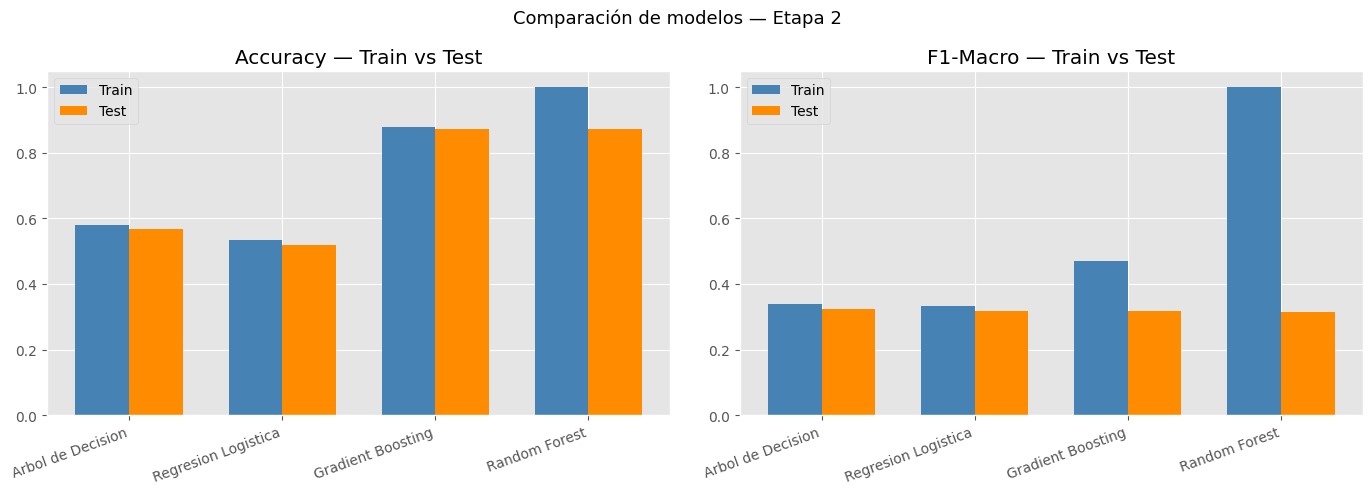

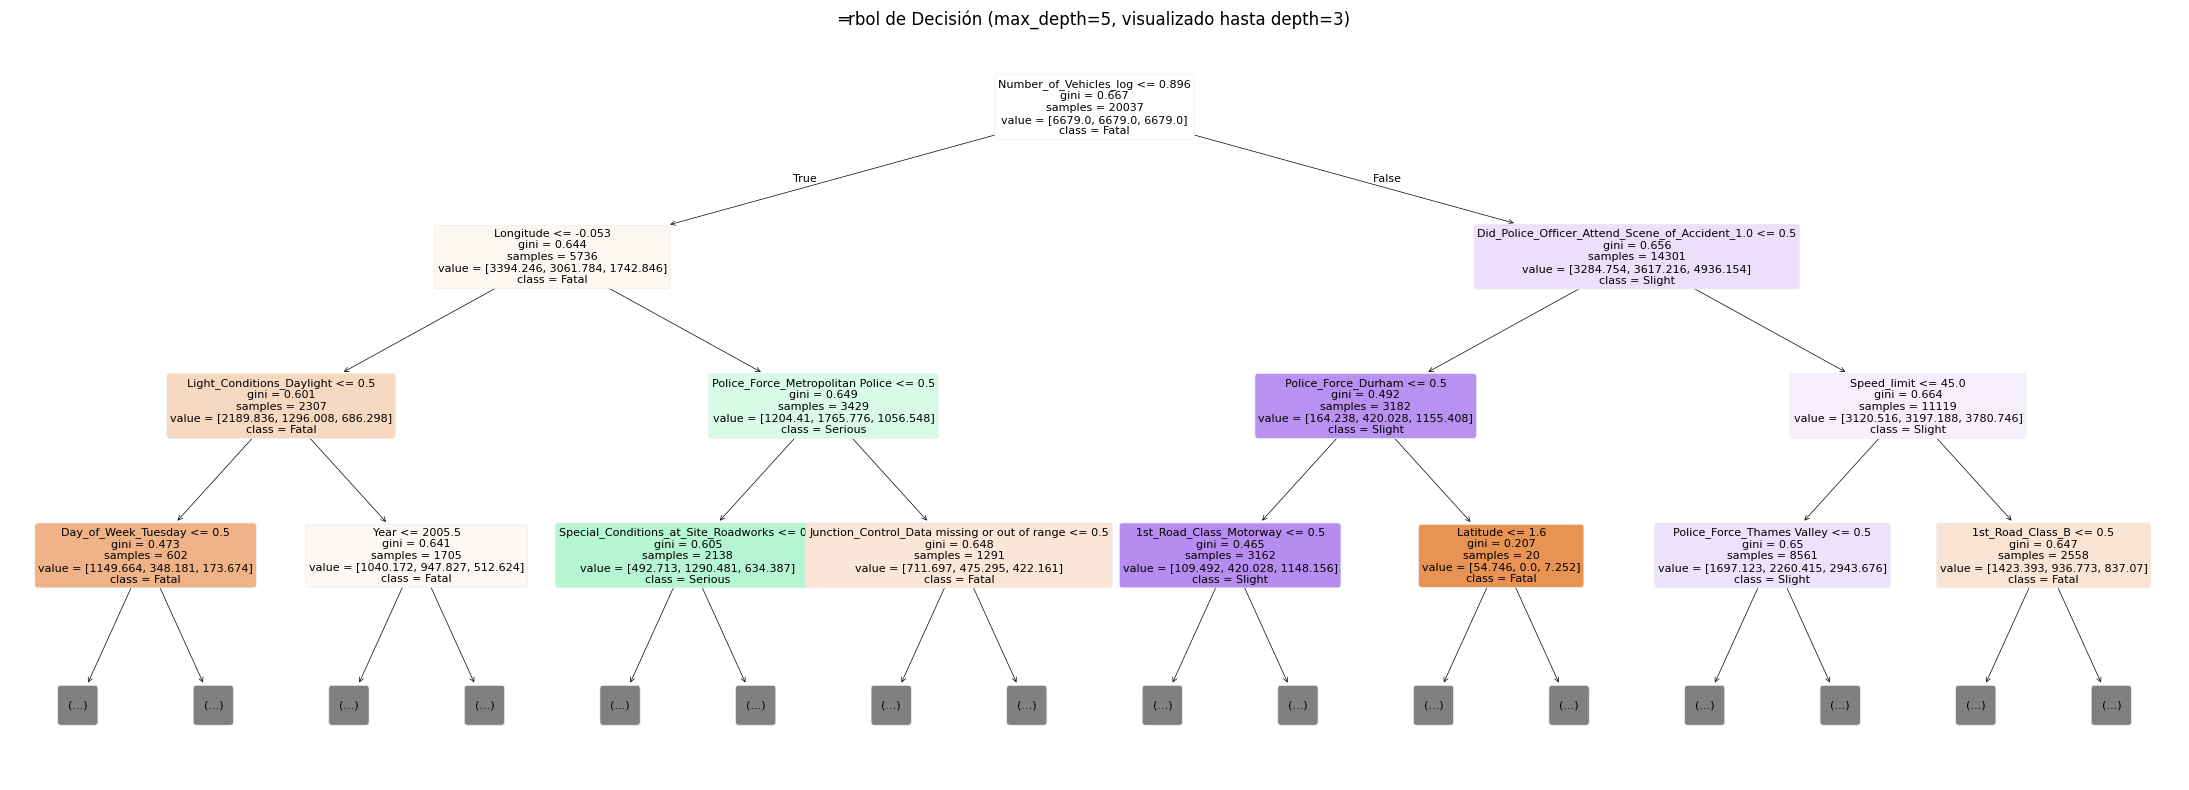

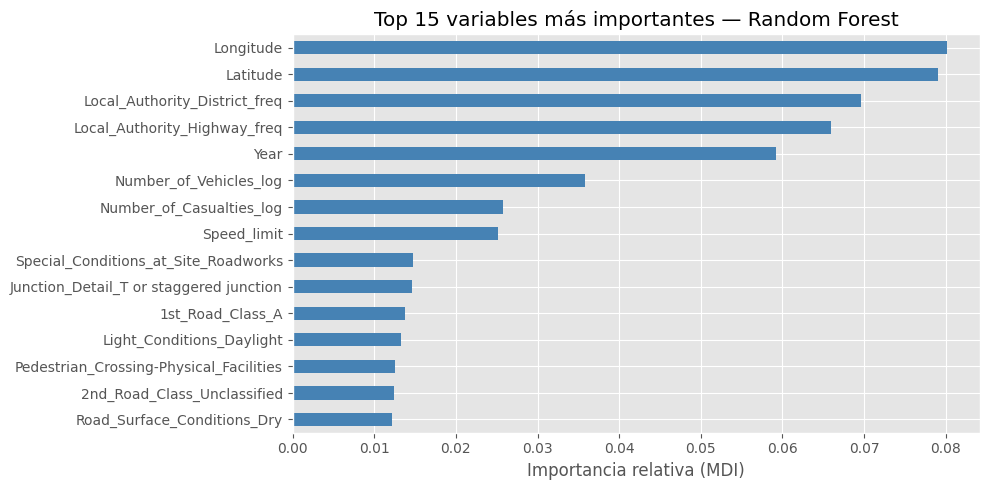

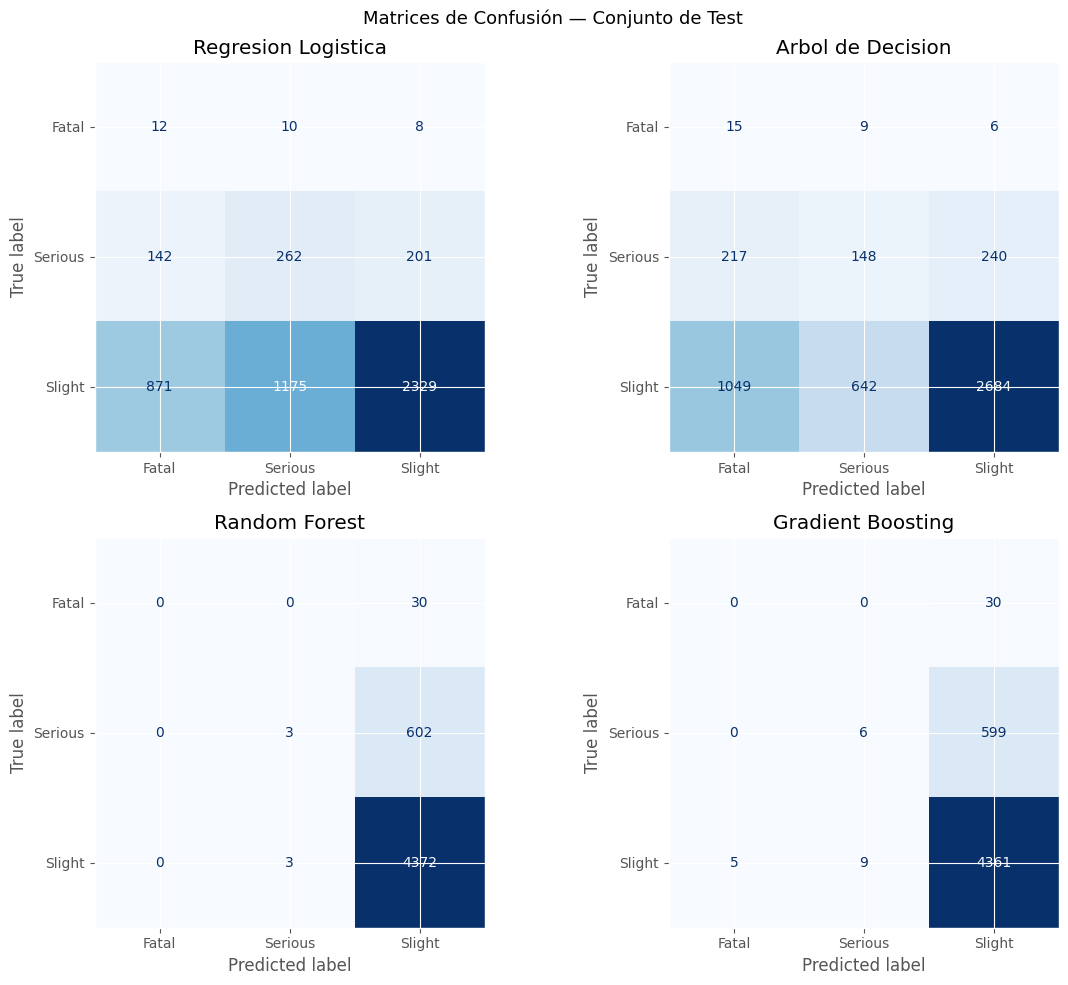


Reporte detallado — Arbol de Decision
              precision    recall  f1-score   support

   Fatal (1)       0.01      0.50      0.02        30
 Serious (2)       0.19      0.24      0.21       605
  Slight (3)       0.92      0.61      0.73      4375

    accuracy                           0.57      5010
   macro avg       0.37      0.45      0.32      5010
weighted avg       0.82      0.57      0.67      5010



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay,
                              classification_report)

# ─── Reiniciar listas para evitar duplicados al re-ejecutar ─────────────────
results        = []
trained_models = {}

# (nombre, modelo, usar_datos_escalados) — patrón S1_abalon.ipynb
modelos_config = [
    ('Regresion Logistica', LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=42), True),
    ('Arbol de Decision', DecisionTreeClassifier(
        max_depth=5, class_weight='balanced', random_state=42), False),
    ('Random Forest', RandomForestClassifier(
        n_estimators=200, class_weight='balanced_subsample', random_state=42, n_jobs=-1), False),
    ('Gradient Boosting', GradientBoostingClassifier(
        n_estimators=200, random_state=42), False),
]

def _split_xy(usar_scaler):
    return (X_train_sc, X_test_sc) if usar_scaler else (X_train, X_test)

# ─── Entrenamiento y recolección de métricas ─────────────────────────────────
for name, model, usar_scaler in modelos_config:
    Xtr, Xte = _split_xy(usar_scaler)
    model.fit(Xtr, y_train)
    trained_models[name] = model

    pred_train = model.predict(Xtr)
    pred_test  = model.predict(Xte)

    results.append({
        'modelo':         name,
        'acc_train':      round(accuracy_score(y_train, pred_train), 3),
        'acc_test':       round(accuracy_score(y_test,  pred_test),  3),
        'Brecha acc':     round(accuracy_score(y_train, pred_train) - accuracy_score(y_test, pred_test), 3),
        'f1_macro_train': round(f1_score(y_train, pred_train, average='macro', zero_division=0), 3),
        'f1_macro_test':  round(f1_score(y_test,  pred_test,  average='macro', zero_division=0), 3),
        'Brecha f1':      round(f1_score(y_train, pred_train, average='macro', zero_division=0) -
                                f1_score(y_test,  pred_test,  average='macro', zero_division=0), 3),
        'f1_Fatal':       round(f1_score(y_test, pred_test, labels=[1], average='macro', zero_division=0), 3),
    })
    print(f'[OK] {name}')

# ─── Tabla de resultados ──────────────────────────────────────────────────────
df_results = pd.DataFrame(results).sort_values('f1_macro_test', ascending=False)
print(df_results.to_string())

# ─── Gráfico comparativo ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

nombres = df_results['modelo']
x = range(len(nombres))
w = 0.35

axes[0].bar([i - w/2 for i in x], df_results['acc_train'], width=w, label='Train', color='steelblue')
axes[0].bar([i + w/2 for i in x], df_results['acc_test'],  width=w, label='Test',  color='darkorange')
axes[0].set_xticks(x)
axes[0].set_xticklabels(nombres, rotation=20, ha='right')
axes[0].set_title('Accuracy — Train vs Test')
axes[0].set_ylim(0, 1.05)
axes[0].legend()

axes[1].bar([i - w/2 for i in x], df_results['f1_macro_train'], width=w, label='Train', color='steelblue')
axes[1].bar([i + w/2 for i in x], df_results['f1_macro_test'],  width=w, label='Test',  color='darkorange')
axes[1].set_xticks(x)
axes[1].set_xticklabels(nombres, rotation=20, ha='right')
axes[1].set_title('F1-Macro — Train vs Test')
axes[1].set_ylim(0, 1.05)
axes[1].legend()

plt.suptitle('Comparación de modelos — Etapa 2', fontsize=13)
plt.tight_layout()
plt.show()

# ─── ═rbol de Decision: visualización ────────────────────────────────────────
dt_model = trained_models['Arbol de Decision']
feature_names = X_train.columns.tolist()
class_names   = ['Fatal', 'Serious', 'Slight']

plt.figure(figsize=(22, 8))
plot_tree(dt_model,
          feature_names=feature_names,
          class_names=class_names,
          filled=True,
          rounded=True,
          max_depth=3,
          fontsize=8)
plt.title('═rbol de Decisión (max_depth=5, visualizado hasta depth=3)', fontsize=12)
plt.tight_layout()
plt.show()

# ─── Importancia de variables — Random Forest ─────────────────────────────────
rf_model = trained_models['Random Forest']
feat_imp = pd.Series(rf_model.feature_importances_, index=X_train.columns)
top15 = feat_imp.nlargest(15).sort_values()

plt.figure(figsize=(10, 5))
top15.plot(kind='barh', color='steelblue')
plt.title('Top 15 variables más importantes — Random Forest')
plt.xlabel('Importancia relativa (MDI)')
plt.tight_layout()
plt.show()

# ─── Matrices de confusión ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, (name, model) in zip(axes.ravel(), trained_models.items()):
    _, Xte = _split_xy(name == 'Regresion Logistica')
    pred = model.predict(Xte)
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, pred, labels=[1, 2, 3]),
        display_labels=['Fatal', 'Serious', 'Slight']
    ).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)
plt.suptitle('Matrices de Confusión — Conjunto de Test', fontsize=13)
plt.tight_layout()
plt.show()

# ─── Reporte detallado del mejor modelo ──────────────────────────────────────
mejor = df_results.iloc[0]['modelo']
_, Xte_mejor = _split_xy(mejor == 'Regresion Logistica')
print(f'\nReporte detallado — {mejor}')
print('=' * 55)
print(classification_report(
    y_test,
    trained_models[mejor].predict(Xte_mejor),
    target_names=['Fatal (1)', 'Serious (2)', 'Slight (3)'],
    zero_division=0
))


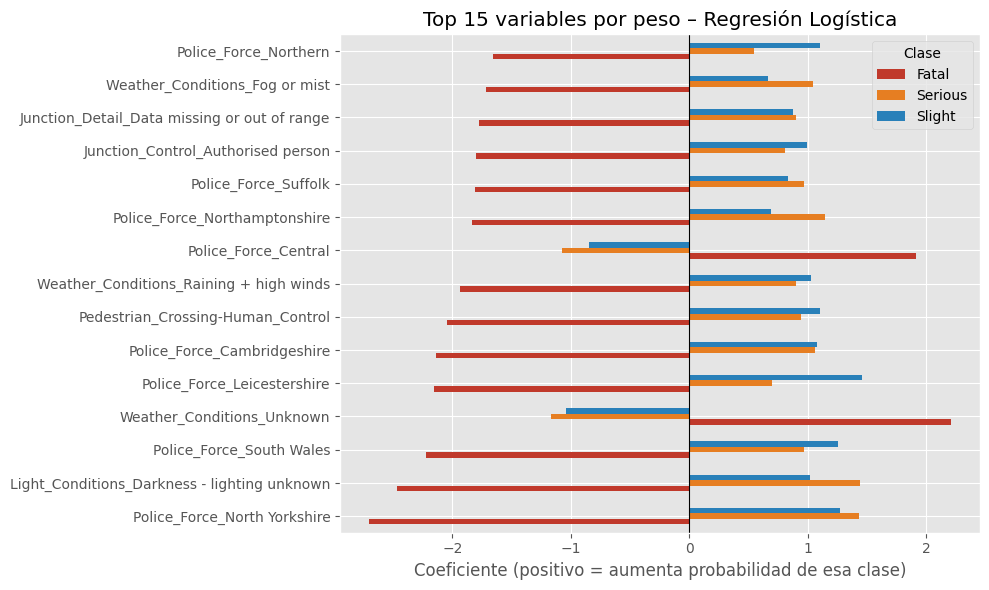

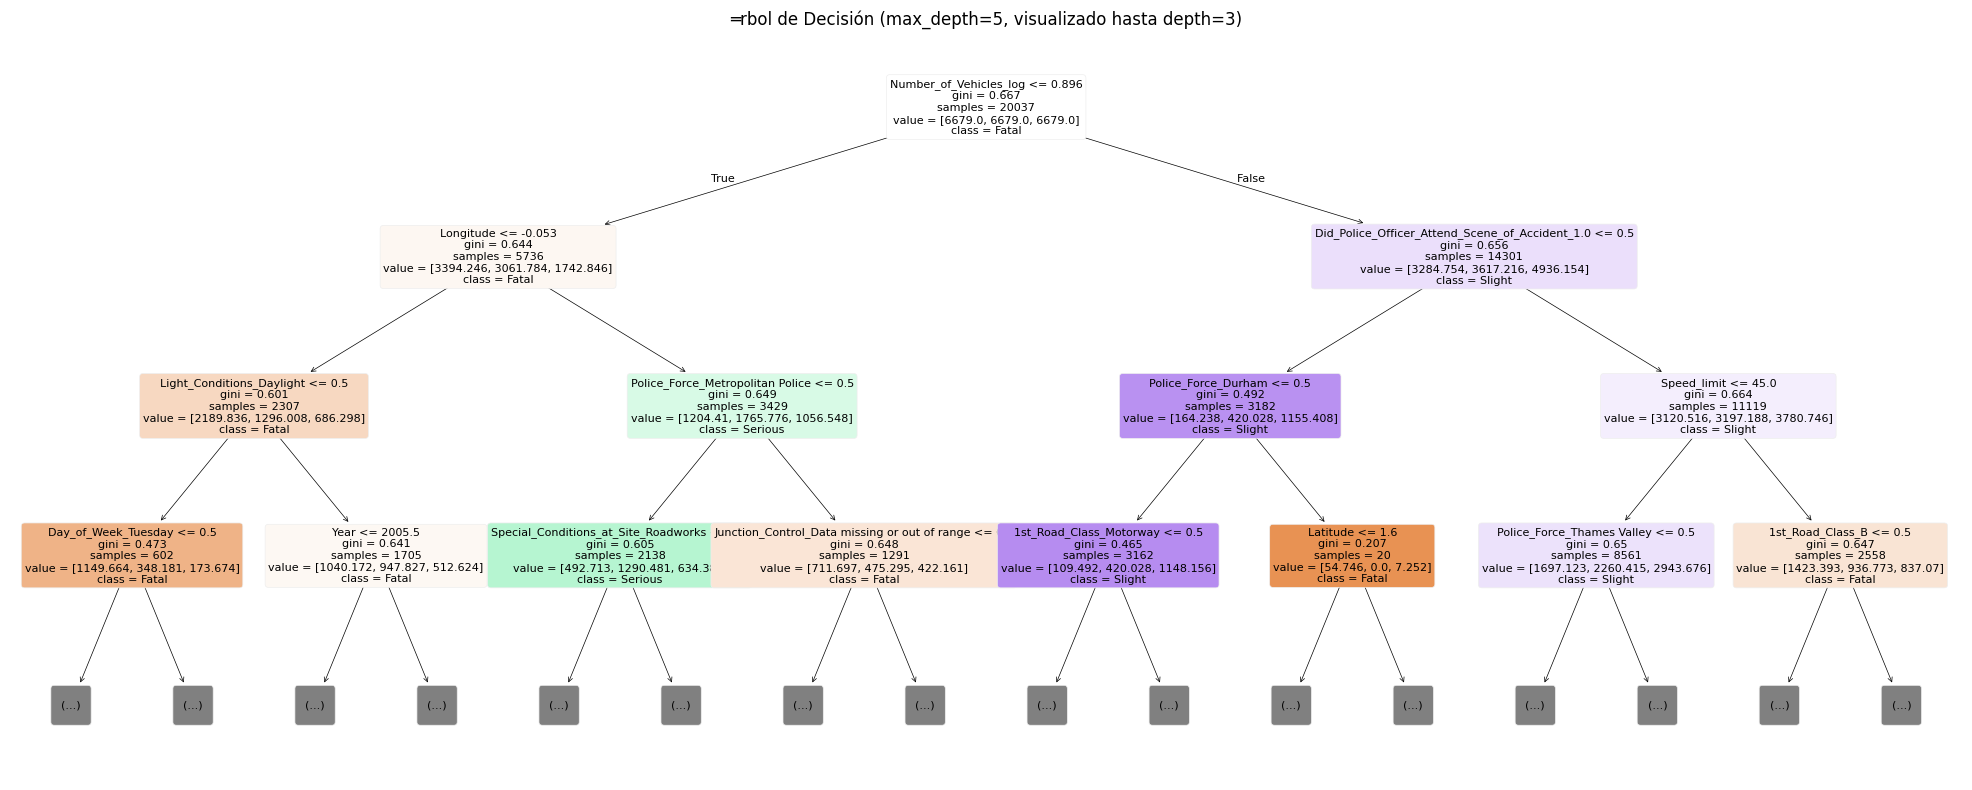

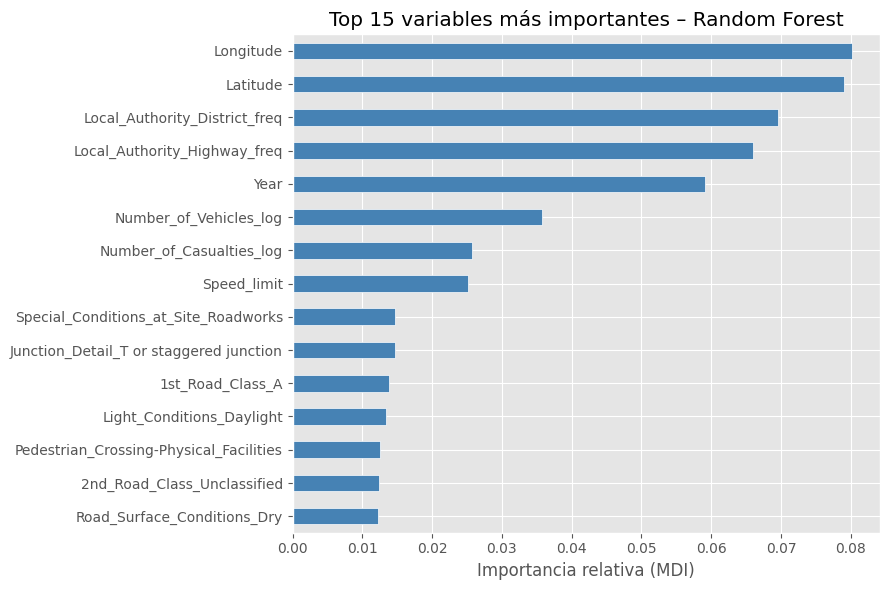

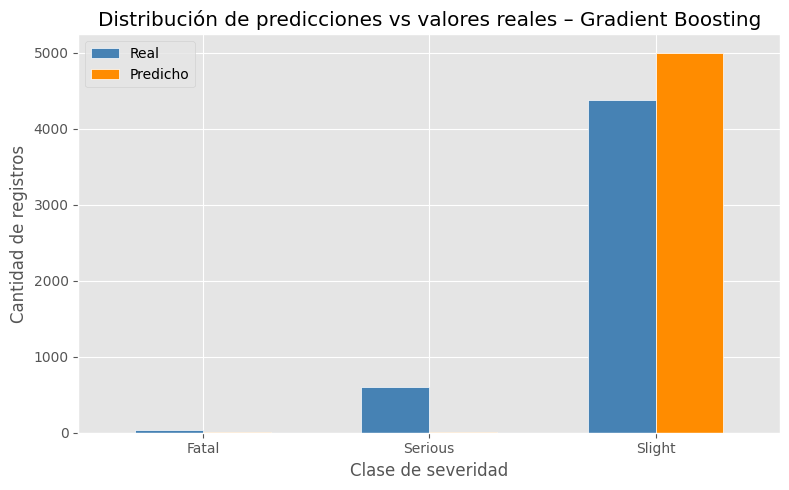

In [ ]:
# 9.1 Regresión Logística — Coeficientes por clase
coef_df = pd.DataFrame(
    trained_models['Regresion Logistica'].coef_,
    index=['Fatal', 'Serious', 'Slight'],
    columns=X_train.columns
).T

top15 = coef_df.abs().mean(axis=1).sort_values(ascending=False).head(15).index
coef_df.loc[top15].plot(kind='barh', figsize=(10, 6), color=['#c0392b','#e67e22','#2980b9'])
plt.title('Top 15 variables por peso – Regresión Logística')
plt.xlabel('Coeficiente (positivo = aumenta probabilidad de esa clase)')
plt.axvline(0, color='black', linewidth=0.8)
plt.legend(title='Clase')
plt.tight_layout()
plt.show()

# 9.2 ═rbol de Decisión — Visualización del árbol
plt.figure(figsize=(20, 8))
plot_tree(
    trained_models['Arbol de Decision'],
    max_depth=3,
    feature_names=X_train.columns,
    class_names=['Fatal', 'Serious', 'Slight'],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title('═rbol de Decisión (max_depth=5, visualizado hasta depth=3)', fontsize=12)
plt.tight_layout()
plt.show()

# 9.3 Random Forest — Importancia de variables
importancias = pd.Series(
    trained_models['Random Forest'].feature_importances_,
    index=X_train.columns
).sort_values(ascending=True).tail(15)

plt.figure(figsize=(9, 6))
importancias.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Top 15 variables más importantes – Random Forest')
plt.xlabel('Importancia relativa (MDI)')
plt.tight_layout()
plt.show()

# 9.4 Gradient Boosting — Distribución de predicciones vs valores reales
real = pd.Series(y_test).map({1:'Fatal', 2:'Serious', 3:'Slight'}).value_counts()
pred = pd.Series(trained_models['Gradient Boosting'].predict(X_test)).map(
    {1:'Fatal', 2:'Serious', 3:'Slight'}
).value_counts()

comparacion = pd.DataFrame({'Real': real, 'Predicho': pred}).reindex(['Fatal','Serious','Slight'])
comparacion.plot(kind='bar', figsize=(8, 5), color=['steelblue','darkorange'],
                 edgecolor='white', width=0.6)
plt.title('Distribución de predicciones vs valores reales – Gradient Boosting')
plt.xlabel('Clase de severidad')
plt.ylabel('Cantidad de registros')
plt.xticks(rotation=0)
plt.legend(title='')
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

for name, model in trained_models.items():
    _, Xte = _split_xy(name == 'Regresion Logistica')
    pred  = model.predict(Xte)
    proba = model.predict_proba(Xte)
    rep   = classification_report(y_test, pred, output_dict=True, zero_division=0)
    auc   = roc_auc_score(y_test, proba, multi_class='ovr', average='macro')
    print(f"\n{name}")
    print(f"  Precisión  (macro): {rep['macro avg']['precision']:.3f}")
    print(f"  Sensibilidad (macro): {rep['macro avg']['recall']:.3f}")
    print(f"  F1-Score   (macro): {rep['macro avg']['f1-score']:.3f}")
    print(f"  AUC-ROC:           {auc:.3f}")


Regresion Logistica
  Precisión  (macro): 0.370
  Sensibilidad (macro): 0.455
  F1-Score   (macro): 0.317
  AUC-ROC:           0.623

Arbol de Decision
  Precisión  (macro): 0.371
  Sensibilidad (macro): 0.453
  F1-Score   (macro): 0.323
  AUC-ROC:           0.621

Random Forest
  Precisión  (macro): 0.458
  Sensibilidad (macro): 0.335
  F1-Score   (macro): 0.314
  AUC-ROC:           0.637

Gradient Boosting
  Precisión  (macro): 0.425
  Sensibilidad (macro): 0.336
  F1-Score   (macro): 0.317
  AUC-ROC:           0.656


In [ ]:
# Ver columnas disponibles
print(X_test.columns.tolist())

# Tomar 3 registros del test set
muestra = X_test.sample(3, random_state=1)
reales  = y_test.loc[muestra.index]
preds   = trained_models['Random Forest'].predict(muestra)
for i, (idx, row) in enumerate(muestra.iterrows()):
    print(f"\nRegistro {i+1} (índice {idx})")
    print(row.to_dict())
    print(f"  Real:      {reales.loc[idx]}")
    print(f"  Predicho:  {preds[i]}")

['Latitude', 'Longitude', 'Pedestrian_Crossing-Human_Control', 'Pedestrian_Crossing-Physical_Facilities', 'Speed_limit', 'Year', 'Road_Type_Data missing or out of range', 'Road_Type_Dual carriageway', 'Road_Type_One way street', 'Road_Type_Roundabout', 'Road_Type_Single carriageway', 'Road_Type_Slip road', 'Road_Type_Unknown', 'Weather_Conditions_Data missing or out of range', 'Weather_Conditions_Fine + high winds', 'Weather_Conditions_Fine no high winds', 'Weather_Conditions_Fog or mist', 'Weather_Conditions_Other', 'Weather_Conditions_Raining + high winds', 'Weather_Conditions_Raining no high winds', 'Weather_Conditions_Snowing + high winds', 'Weather_Conditions_Snowing no high winds', 'Weather_Conditions_Unknown', 'Light_Conditions_Darkness - lighting unknown', 'Light_Conditions_Darkness - lights lit', 'Light_Conditions_Darkness - lights unlit', 'Light_Conditions_Darkness - no lighting', 'Light_Conditions_Data missing or out of range', 'Light_Conditions_Daylight', 'Road_Surface_Cond

## 2.5 Aplicación de Modelos No Supervisados (Clustering)

> Aplica esta sección si tu caso incluye análisis no supervisado,
> o si deseas complementar el enfoque supervisado con segmentación.


In [ ]:
# ═══════════════════════════════════════════════════════════════
# 2.5 — Modelos No Supervisados
# ─────────────────────────────────────────────────────────────
# Decision documentada: clustering NO se aplica como modelo
# principal en este proyecto.
# ═══════════════════════════════════════════════════════════════

print("=" * 65)
print("  DECISION: Clustering no aplicado como enfoque principal")
print("=" * 65)
print()
print("  Razon 1 — Variable objetivo disponible y etiquetada:")
print("    Accident_Severity existe en cada registro. Usar clustering")
print("    ignoraria esta informacion y produciria resultados menos")
print("    accionables para el negocio.")
print()
print("  Razon 2 — Objetivo del negocio es predictivo:")
print("    Se requiere PREDECIR la severidad de accidentes nuevos,")
print("    no DESCUBRIR grupos desconocidos en el dataset.")
print()
print("  Razon 3 — Escala del dataset:")
print("    Con +1M de registros y ~50 features post-OHE, K-Means")
print("    requeriria reduccion dimensional previa (PCA) para ser")
print("    computacionalmente viable, aniadiendo complejidad sin")
print("    beneficio directo sobre el objetivo del proyecto.")
print()
print("  Uso potencial en Etapa 3:")
print("    Clustering geoespacial (Lat/Lon + Speed_limit) para")
print("    identificar 'zonas negras' de alta siniestralidad,")
print("    como valor estrategico complementario al clasificador.")
print()
print("=" * 65)


  DECISION: Clustering no aplicado como enfoque principal

  Razon 1 — Variable objetivo disponible y etiquetada:
    Accident_Severity existe en cada registro. Usar clustering
    ignoraria esta informacion y produciria resultados menos
    accionables para el negocio.

  Razon 2 — Objetivo del negocio es predictivo:
    Se requiere PREDECIR la severidad de accidentes nuevos,
    no DESCUBRIR grupos desconocidos en el dataset.

  Razon 3 — Escala del dataset:
    Con +1M de registros y ~50 features post-OHE, K-Means
    requeriria reduccion dimensional previa (PCA) para ser
    computacionalmente viable, aniadiendo complejidad sin
    beneficio directo sobre el objetivo del proyecto.

  Uso potencial en Etapa 3:
    Clustering geoespacial (Lat/Lon + Speed_limit) para
    identificar 'zonas negras' de alta siniestralidad,
    como valor estrategico complementario al clasificador.



<div style="background:#FFF3CD;border-left:5px solid #FFC000;padding:12px 16px;border-radius:4px; color:#000">
<b>🤔 Preguntas de Reflexión – Modelos y Clustering</b><br>
<ol>
<li><b>¿Por qué Random Forest generalmente supera a un único árbol de decisión?</b> Porque combina muchos árboles entrenados sobre muestras bootstrap distintas y un subconjunto aleatorio de variables en cada split. Eso reduce la varianza del modelo: un árbol individual tiende a sobreajustar y presentar mayor brecha train-test, mientras Random Forest promedia muchas particiones independientes y generaliza mejor, como se observa en nuestra tabla de resultados.</li>
<li><b>¿Qué ventaja tiene K-Means sobre otros algoritmos de clustering cuando tienes muchos datos?</b> K-Means escala bien en volumen: su complejidad es aproximadamente O(n·k·i·d) y es simple de paralelizar. En datasets grandes resulta más eficiente que DBSCAN o clustering jerárquico, que pueden volverse costosos en memoria o tiempo. En este proyecto no lo aplicamos como enfoque principal, pero sería útil para segmentar zonas geográficas de alta siniestralidad.</li>
<li><b>¿Cómo interpretarías los clusters encontrados desde el punto de vista del negocio?</b> Cada cluster representaría un perfil de riesgo vial (por ejemplo: autopistas de alta velocidad nocturnas, cruces urbanos con lluvia, zonas rurales sin iluminación). Desde el negocio, esos grupos orientarían dónde invertir en iluminación, control de velocidad o refuerzo de emergencias, independientemente de la severidad individual de cada accidente.</li>
<li><b>¿Si el Silhouette Score es 0.2, los clusters son útiles? ¿Cuál es un valor aceptable?</b> Un Silhouette de 0.2 indica separación débil entre clusters: hay solapamiento y la segmentación es poco confiable para tomar decisiones. Como referencia, valores &gt; 0.5 sugieren estructura razonable; entre 0.2 y 0.5 es aceptable solo con validación de negocio; por debajo de 0.2 conviene replantear variables, k o el algoritmo.</li>
<li><b>¿Qué significa que dos variables tengan importancia cero en Random Forest?</b> Significa que ningún árbol del bosque las seleccionó para un split que redujera impureza: no aportaron poder discriminativo en este entrenamiento. Puede deberse a redundancia con otras variables (multicolinealidad), baja variabilidad o relación muy débil con la severidad. No implica que sean irrelevantes en el dominio; solo que el modelo no las utilizó.</li>
</ol>
</div>


<div style="background:#E2EFDA;border-left:5px solid #70AD47;padding:12px 16px;border-radius:4px">
<b>✅ Cierre Etapa 2 – Checklist de Entregables</b><br>
<ul>
<li>☑ Justificación documentada del enfoque supervisado / no supervisado</li>
<li>☑ Tabla de decisión de modelos con argumentos</li>
<li>☑ Modelo base (baseline) establecido</li>
<li>☑ Mínimo 3 algoritmos entrenados con sus parámetros documentados</li>
<li>☑ Visualizaciones de importancia de variables</li>
<li>☑ Clustering no aplicado — justificado por enfoque supervisado con variable objetivo disponible (§2.5)</li>
</ul>
</div>



<div style="background:#1F3864;padding:18px 24px;border-radius:8px">
<h1 style="color:white;font-family:Arial;margin:0">🔍 ETAPA 3</h1>
<h2 style="color:#FFC000;font-family:Arial;margin:4px 0 0 0">Evaluación de Modelos, Modelo Ganador y Predicción con Datos Nuevos</h2>
<p style="color:#D6E4F0;font-family:Arial;margin:8px 0 0 0">CRISP-DM Fases 5 y 6: Evaluación · Despliegue</p>
</div>

---

**Indicadores evaluados:** IL 3.2 · IL 3.5

**Ponderación:** 40% (IL 3.2: 15% + IL 3.2: 15% + IL 3.5: 10%)


## 3.1 Evaluación Cuantitativa de Modelos

> La evaluación debe ir más allá del accuracy.
> Elige las métricas según el tipo de problema y el costo de los errores.

### 📊 Guía de Métricas por Tipo de Problema

| Tipo | Métricas principales | Cuándo priorizar |
|---|---|---|
| **Clasificación binaria** | Accuracy, Precision, Recall, F1, AUC-ROC | Recall si el FN es costoso (ej. enfermedades) |
| **Clasificación multiclase** | F1-macro, F1-weighted, Confusion Matrix | F1-macro si hay desbalance |
| **Regresión** | RMSE, MAE, R², MAPE | RMSE si errores grandes son más costosos |
| **Clustering** | Silhouette, Davies-Bouldin | Silhouette > 0.5 indica buena separación |


TABLA COMPARATIVA DE MÉTRICAS — Test Set (20%)


,Accuracy,Precision (macro),Recall (macro),F1-macro,F1-weighted,AUC-ROC (macro)
Modelo,,,,,,
Baseline (Most Frequent),87.33%,29.11%,33.33%,31.08%,81.42%,50.0%
Regresion Logistica,51.96%,37.01%,45.51%,31.73%,61.94%,62.33%
Arbol de Decision,56.83%,37.1%,45.27%,32.28%,66.73%,62.07%
Random Forest,87.33%,45.79%,33.48%,31.4%,81.53%,63.66%
Gradient Boosting,87.17%,42.46%,33.56%,31.69%,81.56%,65.6%



 F1-macro es la métrica principal: penaliza el mal rendimiento
  en clases minoritarias (Fatal), las más costosas de omitir.

 Baseline F1-macro : 31.08%
 Modelo líder      : Arbol de Decision (32.28%)


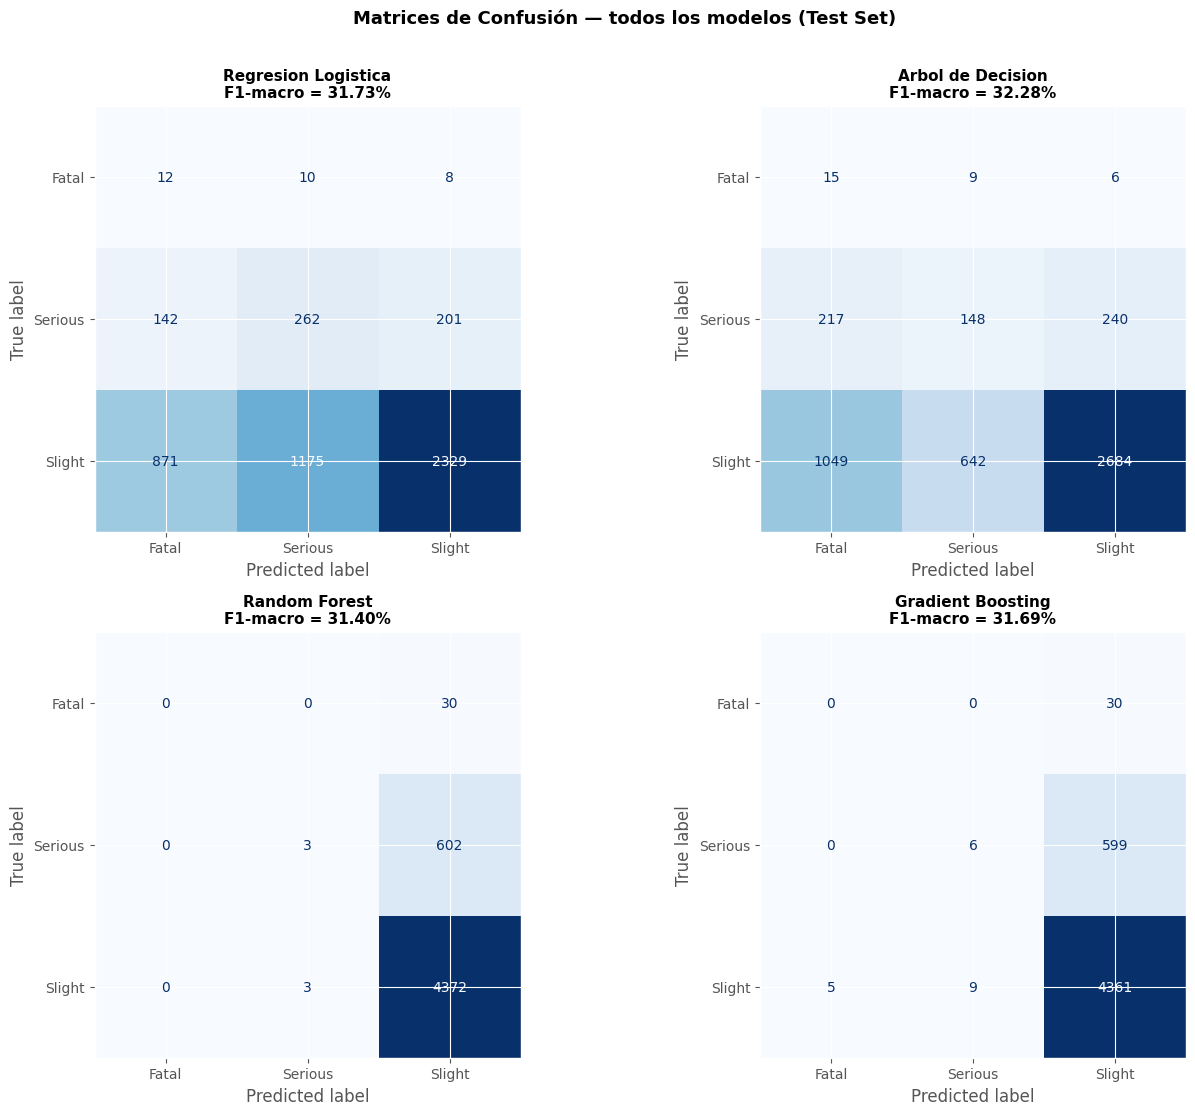

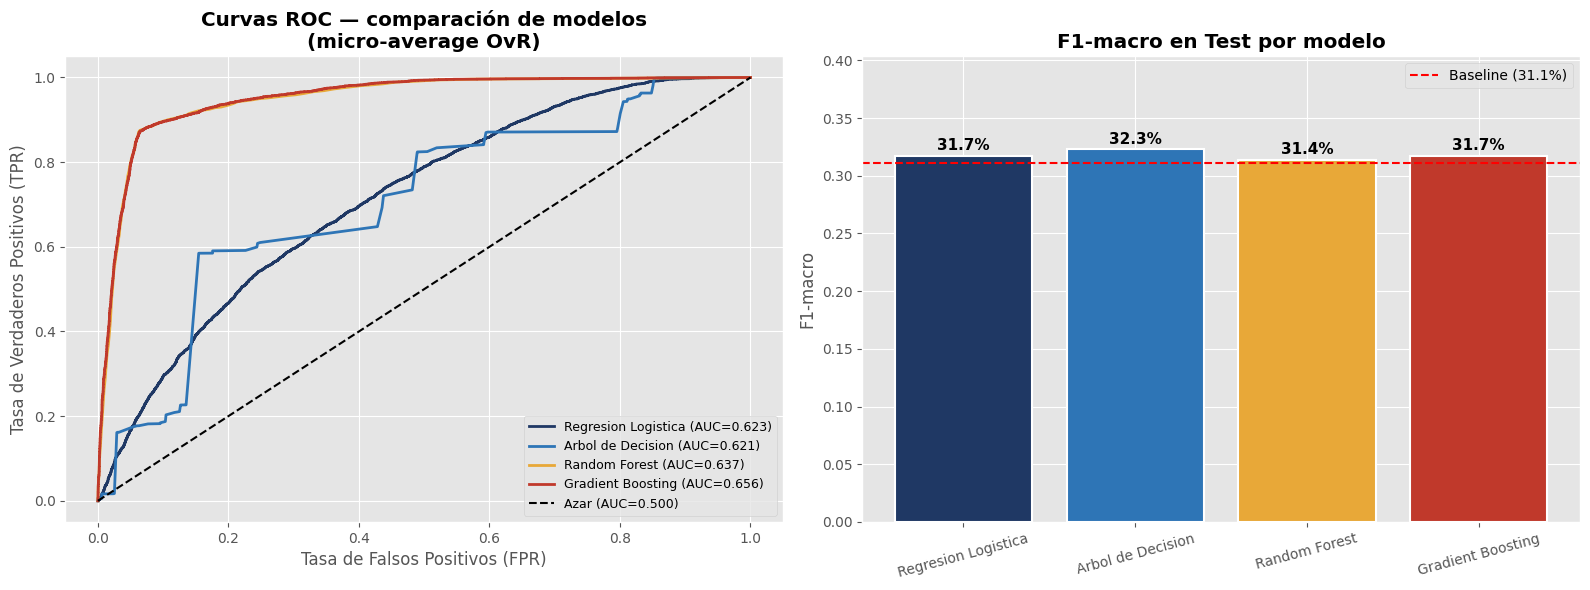

In [ ]:
# ═══════════════════════════════════════════════════════════════
# 3.1 — Evaluación Cuantitativa de Modelos
# ─────────────────────────────────────────────────────────────
# Tabla comparativa completa y visualizaciones para clasificación multiclase.
# ═══════════════════════════════════════════════════════════════

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)
from sklearn.dummy import DummyClassifier
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')
CLASES_LABEL = ['Fatal', 'Serious', 'Slight']
CLASES_NUM   = [1, 2, 3]
COLORES_MOD  = ['#1F3864', '#2E75B6', '#E8A838', '#c0392b']

# ─── Verificar que los modelos ya fueron entrenados ──────────────────────────
if not trained_models:
    raise RuntimeError(
        "\n¡ATENCIÓN! 'trained_models' está vacío.\n"
        "Debes ejecutar PRIMERO la celda de entrenamiento (sección 2.2 — celda con modelos_config).\n"
        "Orden correcto: celda 2.0 → 2.2 (entrenamiento) → 2.3 (baseline) → 3.1 (esta celda)."
    )

# ─── Función auxiliar para mostrar métricas como porcentaje (sin jinja2) ─────
def mostrar_porcentaje(tabla, columnas, decimales=2):
    salida = tabla.copy()
    for col in columnas:
        if col in salida.columns:
            salida[col] = (salida[col] * 100).round(decimales).astype(str) + '%'
    return salida

# ─── 1. Tabla de métricas comparativa (Baseline + 4 modelos) ─────────────────
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train, y_train)

def metricas_modelo(nombre, model, usar_scaler=False):
    _, Xte = _split_xy(usar_scaler)
    pred  = model.predict(Xte)
    proba = model.predict_proba(Xte)
    return {
        'Modelo': nombre,
        'Accuracy':          round(accuracy_score(y_test, pred), 4),
        'Precision (macro)': round(precision_score(y_test, pred, average='macro', zero_division=0), 4),
        'Recall (macro)':    round(recall_score(y_test, pred, average='macro', zero_division=0), 4),
        'F1-macro':          round(f1_score(y_test, pred, average='macro', zero_division=0), 4),
        'F1-weighted':       round(f1_score(y_test, pred, average='weighted', zero_division=0), 4),
        'AUC-ROC (macro)':   round(roc_auc_score(y_test, proba, multi_class='ovr', average='macro'), 4),
    }

filas = [metricas_modelo('Baseline (Most Frequent)', dummy)]
for name, model in trained_models.items():
    filas.append(metricas_modelo(name, model, usar_scaler=(name == 'Regresion Logistica')))

df_metricas = pd.DataFrame(filas).set_index('Modelo')
cols_pct = ['Accuracy', 'Precision (macro)', 'Recall (macro)', 'F1-macro', 'F1-weighted', 'AUC-ROC (macro)']

print("=" * 68)
print("TABLA COMPARATIVA DE MÉTRICAS — Test Set (20%)")
print("=" * 68)
display(mostrar_porcentaje(df_metricas[cols_pct].reset_index(), cols_pct).set_index('Modelo'))

baseline_f1  = df_metricas.loc['Baseline (Most Frequent)', 'F1-macro']
modelos_f1   = df_metricas['F1-macro'].drop('Baseline (Most Frequent)')
lider_nombre = modelos_f1.idxmax()
lider_f1     = modelos_f1.max()

print(f"\n F1-macro es la métrica principal: penaliza el mal rendimiento")
print(f"  en clases minoritarias (Fatal), las más costosas de omitir.")
print(f"\n Baseline F1-macro : {baseline_f1*100:.2f}%")
print(f" Modelo líder      : {lider_nombre} ({lider_f1*100:.2f}%)")

# ─── 2. Matrices de confusión — cuadrícula 2x2 ───────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.flatten()

for ax, (name, model) in zip(axes, trained_models.items()):
    _, Xte = _split_xy(name == 'Regresion Logistica')
    pred = model.predict(Xte)
    cm = confusion_matrix(y_test, pred, labels=CLASES_NUM)
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASES_LABEL).plot(
        ax=ax, colorbar=False, cmap='Blues')
    f1_val = f1_score(y_test, pred, average='macro', zero_division=0)
    ax.set_title(f'{name}\nF1-macro = {f1_val*100:.2f}%', fontweight='bold', fontsize=11)

plt.suptitle('Matrices de Confusión — todos los modelos (Test Set)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ─── 3. Curvas ROC multiclase (micro-average) ────────────────────────────────
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc as sklearn_auc

y_test_bin = label_binarize(y_test, classes=CLASES_NUM)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for color, (name, model) in zip(COLORES_MOD, trained_models.items()):
    _, Xte = _split_xy(name == 'Regresion Logistica')
    proba = model.predict_proba(Xte)
    fpr_micro, tpr_micro, _ = roc_curve(y_test_bin.ravel(), proba.ravel())
    auc_macro = roc_auc_score(y_test, proba, multi_class='ovr', average='macro')
    axes[0].plot(fpr_micro, tpr_micro,
                 label=f'{name} (AUC={auc_macro:.3f})', color=color, linewidth=2)

axes[0].plot([0, 1], [0, 1], 'k--', label='Azar (AUC=0.500)', linewidth=1.5)
axes[0].set_title('Curvas ROC — comparación de modelos\n(micro-average OvR)', fontweight='bold')
axes[0].set_xlabel('Tasa de Falsos Positivos (FPR)')
axes[0].set_ylabel('Tasa de Verdaderos Positivos (TPR)')
axes[0].legend(fontsize=9)

# Gráfico de barras: F1-macro por modelo
modelos_nombres = list(trained_models.keys())
f1_vals = [df_metricas.loc[m, 'F1-macro'] for m in modelos_nombres]
colores_bar = [COLORES_MOD[i] for i in range(len(modelos_nombres))]
bars = axes[1].bar(modelos_nombres, f1_vals, color=colores_bar, edgecolor='white', linewidth=1.5)
axes[1].axhline(y=baseline_f1, color='red', linestyle='--', linewidth=1.5, label=f'Baseline ({baseline_f1*100:.1f}%)')
axes[1].set_title('F1-macro en Test por modelo', fontweight='bold')
axes[1].set_ylabel('F1-macro')
axes[1].set_ylim(0, max(f1_vals) * 1.25)
axes[1].legend()
for bar, val in zip(bars, f1_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val*100:.1f}%', ha='center', fontsize=11, fontweight='bold')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

<div style="background:#FFF3CD;border-left:5px solid #FFC000;padding:12px 16px;border-radius:4px">
<b>🤔 Preguntas de Reflexión – Evaluación de Modelos</b><br>
<ol>
<li>¿Cuál modelo tiene mejor Accuracy pero peor Recall? ¿En tu caso de negocio, cuál es más peligroso: falso positivo o falso negativo?</li>
<li>¿Por qué un modelo con 95% de Accuracy en un dataset desbalanceado podría ser completamente inútil?</li>
<li>¿Qué indica una curva ROC que se aproxima a la diagonal? ¿Y una que sube rápidamente hacia la esquina superior izquierda?</li>
<li>¿Si tu modelo de Random Forest supera en accuracy al Árbol de Decisión, significa que siempre es la mejor elección? ¿Qué otros factores considerar?</li>
<li>¿Qué diferencia hay entre el error en el conjunto de entrenamiento y en el de test? ¿Qué indica una gran diferencia?</li>
</ol>
</div>

<div style="background:#E8F4FD;border-left:5px solid #2196F3;padding:12px 16px;border-radius:4px;margin-top:10px">
<b>✏️ Respuestas</b><br><br>

<b>1.</b> Random Forest y Gradient Boosting tienen la mayor Accuracy (87%) pero el peor Recall (33%), igual que el baseline. En emergencias, el <b>falso negativo es más peligroso</b>: clasificar un accidente Fatal como Leve significa enviar recursos insuficientes, lo que puede costar una vida. Un falso positivo solo gasta más recursos de los necesarios, sin consecuencias letales.<br><br>

<b>2.</b> Porque si el 87% de los datos son "Leve", predecir siempre "Leve" da 87% de Accuracy sin aprender nada. Es exactamente lo que pasó con Random Forest en este proyecto: misma Accuracy que el baseline, F1-macro = 31%, y casi nunca detecta accidentes Fatales.<br><br>

<b>3.</b> Una curva ROC sobre la diagonal (AUC ≈ 0.50) significa que el modelo clasifica igual que el azar, sin ninguna utilidad. El baseline tiene exactamente eso. Una que sube rápido hacia la esquina superior izquierda (AUC → 1.0) significa que el modelo detecta bien los positivos reales con pocos errores. En este proyecto, Gradient Boosting tiene el mejor AUC (65.6%), aunque su Recall en minorías sigue siendo bajo.<br><br>

<b>4.</b> No. Random Forest tiene 87% de Accuracy vs 57% del Árbol, pero el Árbol gana en F1-macro (32.28% vs 31.4%) y Recall (45% vs 33%). La Accuracy es engañosa cuando las clases están desbalanceadas. Hay que considerar qué métrica importa según el objetivo: aquí, detectar Fatales es prioritario, y el árbol lo hace mejor.<br><br>

<b>5.</b> Una gran diferencia entre train y test indica <b>sobreajuste</b>: el modelo aprendió de memoria los datos de entrenamiento pero falla con datos nuevos. En el Anexo, el RF optimizado tiene F1 Train = 67.83% vs Test = 38.21% (brecha de 30 puntos), lo que es una señal de que no va a funcionar bien en producción.
</div>


### 📊 Diagnóstico de Balanceo de Clases (Previo a la Validación Cruzada)

Antes de ejecutar la validación cruzada es importante verificar **si las clases están balanceadas** en los conjuntos de entrenamiento y prueba.

| Ratio mayoría/minoría | Diagnóstico | Acción recomendada |
|---|---|---|
| < 1.5:1 | ✅ Balanceado | `StratifiedKFold` es suficiente |
| 1.5 – 5:1 | ⚠️ Desbalance moderado | `class_weight='balanced'` |
| > 5:1 | 🔴 Desbalance severo | SMOTE dentro del pipeline de CV |


In [ ]:
# ═══════════════════════════════════════════════════════════════
# Diagnóstico de Balanceo de Clases (ANTES de Cross-Validation)
# ─────────────────────────────────────────────────────────────
# Muestra la distribución de y_train e y_test, calcula el ratio
# mayoría/minoría y emite una recomendación automática.
# ═══════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

etiq_map = {1: 'Fatal', 2: 'Grave', 3: 'Leve'}

def diagnostico_balance(y, nombre_set):
    conteo  = y.value_counts().sort_index()
    total   = len(y)
    pct     = conteo / total * 100
    ratio   = conteo.max() / conteo.min()

    df_diag = pd.DataFrame({
        'Clase': [etiq_map.get(k, str(k)) for k in conteo.index],
        'Código': conteo.index.tolist(),
        'N': conteo.values,
        '%': pct.round(2).values,
    })

    if ratio < 1.5:
        nivel, color_nivel = 'BALANCEADO ✅', '#27AE60'
    elif ratio < 5:
        nivel, color_nivel = 'DESBALANCE MODERADO ⚠️', '#E67E22'
    else:
        nivel, color_nivel = 'DESBALANCE SEVERO 🔴', '#E74C3C'

    print(f'\n{"="*55}')
    print(f'  {nombre_set.upper()}  — Distribución de clases')
    print(f'{"="*55}')
    print(df_diag.to_string(index=False))
    print(f'\n  Ratio mayoría/minoría : {ratio:.1f}:1')
    print(f'  Diagnóstico           : {nivel}')

    return conteo, pct, ratio, nivel, color_nivel


c_train, p_train, r_train, n_train, col_train = diagnostico_balance(y_train, 'y_train')
c_test,  p_test,  r_test,  n_test,  col_test  = diagnostico_balance(y_test,  'y_test')

# ─── Visualización comparativa ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colores = ['#C0392B', '#E67E22', '#27AE60']
clases_labels = [etiq_map.get(k, str(k)) for k in c_train.index]
x = np.arange(len(clases_labels))

for ax, conteo, pct, titulo, ratio in [
    (axes[0], c_train, p_train, f'y_train — {len(y_train):,} registros', r_train),
    (axes[1], c_test,  p_test,  f'y_test  — {len(y_test):,} registros',  r_test),
]:
    bars = ax.bar(x, conteo.values, color=colores[:len(x)],
                  alpha=0.85, edgecolor='white', linewidth=1.5)
    ax.set_xticks(x)
    ax.set_xticklabels(clases_labels, fontsize=11)
    ax.set_ylabel('N° de registros')
    ax.set_title(f'{titulo}\nRatio mayoría/minoría: {ratio:.1f}:1', fontweight='bold')
    for bar, (n, p) in zip(bars, zip(conteo.values, pct.values)):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + conteo.max() * 0.01,
                f'{n:,}\n({p:.1f}%)',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Diagnóstico de Balanceo de Clases\n'
             '(Evaluar ANTES de aplicar validación cruzada)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ─── Recomendación automática ────────────────────────────────────────────────
max_ratio = max(r_train, r_test)
print('\n' + '='*55)
print('  RECOMENDACIÓN PARA LA VALIDACIÓN CRUZADA')
print('='*55)
if max_ratio < 1.5:
    print('  Los datos están BALANCEADOS.')
    print('  StratifiedKFold sin técnicas adicionales es suficiente.')
elif max_ratio < 5:
    print(f'  Desbalance moderado detectado (ratio {max_ratio:.1f}:1).')
    print('  Recomendación: class_weight="balanced" en los clasificadores.')
    print('  Opcional: SMOTE dentro del pipeline de CV.')
else:
    print(f'  Desbalance SEVERO detectado (ratio {max_ratio:.1f}:1).')
    print('  Se RECOMIENDA una de las siguientes estrategias:')
    print('    1. class_weight="balanced"  — sin riesgo de data leakage')
    print('    2. SMOTE dentro del pipeline de CV  — ver celda siguiente')
    print('    3. Umbral de decisión personalizado por clase')


### ⚠️ Balanceo de Datos en Validación Cruzada: Evitando Data Leakage

El balanceo de datos (especialmente el **sobremuestreo sintético** como SMOTE) debe realizarse con precaución durante la validación cruzada para evitar la fuga de información (data leakage). Aquí el porqué:

*   **¿Qué es Data Leakage?** Ocurre cuando la información del conjunto de prueba (o validación) se filtra al conjunto de entrenamiento. Esto hace que el modelo parezca rendir mejor de lo que realmente lo hará con datos nuevos no vistos.

*   **SMOTE y Leakage:** Si aplicamos SMOTE a todo el dataset *antes* de la validación cruzada, las muestras sintéticas creadas para las clases minoritarias se generarán utilizando ejemplos tanto del conjunto de entrenamiento como del de validación. Cuando se evalúa el modelo, el conjunto de validación contendrá ejemplos sintéticos que son "cercanos" o incluso copias de los ejemplos de entrenamiento, llevando a una sobrestimación del rendimiento.

*   **Solución:** SMOTE debe aplicarse **dentro de cada fold de la validación cruzada**, y solo sobre el subconjunto de entrenamiento de ese fold. El flujo correcto es:
    1.  Dividir el dataset en `k` folds.
    2.  Para cada fold:
        *   Tomar los datos de `k-1` folds para entrenamiento y 1 fold para validación.
        *   **Aplicar SMOTE SÓLO al conjunto de entrenamiento.**
        *   Entrenar el modelo con los datos balanceados.
        *   Evaluar el modelo con el conjunto de validación original (no modificado por SMOTE).

Esto garantiza que el conjunto de validación permanezca completamente virgen y proporcione una estimación imparcial del rendimiento del modelo.



In [ ]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Modificar modelos_config para indicar cuáles deben usar SMOTE
# En este ejemplo, aplicaremos SMOTE a todos los modelos para demostrar la integración,
# aunque LogisticRegression ya maneja class_weight.
modelos_config_smote = [
    ('Regresion Logistica', LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=42), True, True), # (nombre, modelo, usar_scaler, usar_smote)
    ('Arbol de Decision', DecisionTreeClassifier(
        max_depth=5, class_weight='balanced', random_state=42), False, True),
    ('Random Forest', RandomForestClassifier(
        n_estimators=200, class_weight='balanced_subsample', random_state=42, n_jobs=-1), False, True),
    ('Gradient Boosting', GradientBoostingClassifier(
        n_estimators=200, random_state=42), False, True),
]

cv_stratified = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring_cv = {
    'f1_macro':     'f1_macro',
    'accuracy':     'accuracy',
    'recall_macro': 'recall_macro',
}

cv_rows = []
print("Ejecutando validación cruzada 5-fold estratificada CON SMOTE...")
print("(puede tardar bastante por el tamaño del dataset y SMOTE)\
")

for name, model, usar_scaler, usar_smote in modelos_config_smote:
    steps = []
    if usar_scaler: # Solo Logistic Regression usa StandardScaler en este setup
        steps.append(('scaler', StandardScaler()))
    if usar_smote: # Aplicar SMOTE en el pipeline de CV
        steps.append(('smote', SMOTE(random_state=42, sampling_strategy='auto')))
    steps.append(('clf', model))

    pipe = ImbPipeline(steps)
    Xcv = X_train # X_train no escalado para que el scaler del pipeline lo haga

    scores = cross_validate(pipe, Xcv, y_train,
                            cv=cv_stratified,
                            scoring=scoring_cv,
                            n_jobs=1,
                            return_train_score=False)

    cv_rows.append({
        'Modelo':             name,
        'F1-macro promedio':  round(scores['test_f1_macro'].mean(), 4),
        'F1-macro std':       round(scores['test_f1_macro'].std(), 4),
        'Accuracy promedio':  round(scores['test_accuracy'].mean(), 4),
        'Accuracy std':       round(scores['test_accuracy'].std(), 4),
        'Recall promedio':    round(scores['test_recall_macro'].mean(), 4),
    })
    print(f"  {name:<25} F1-macro = {scores['test_f1_macro'].mean()*100:.2f}% "
          f"± {scores['test_f1_macro'].std()*100:.2f}%"
          f"  |  Accuracy = {scores['test_accuracy'].mean()*100:.2f}%")

df_cv_smote = pd.DataFrame(cv_rows).set_index('Modelo')

print()
print("=" * 65)
print("RESULTADOS DE VALIDACIÓN CRUZADA (5-Fold Estratificado CON SMOTE)")
print("=" * 65)

cols_cv_pct = ['F1-macro promedio', 'F1-macro std', 'Accuracy promedio', 'Accuracy std', 'Recall promedio']
display(mostrar_porcentaje(df_cv_smote.reset_index(), cols_cv_pct).set_index('Modelo'))

print(f"\n Un std bajo = mayor estabilidad (el modelo generaliza bien).")
print(f" Modelo más estable (menor F1 std): {df_cv_smote['F1-macro std'].idxmin()}")
print(f" Modelo con mayor F1-macro CV:      {df_cv_smote['F1-macro promedio'].idxmax()}"
      f" ({df_cv_smote['F1-macro promedio'].max()*100:.2f}%)")

# --- Gráfico: F1-macro CV con barras de error ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(df_cv_smote))
labels_cv = df_cv_smote.index.tolist()

axes[0].bar(x, df_cv_smote['F1-macro promedio'], yerr=df_cv_smote['F1-macro std'],
            capsize=5, color='#2E75B6', alpha=0.85, edgecolor='white', linewidth=1.5)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels_cv, rotation=15, ha='right')
axes[0].set_ylabel('F1-macro')
axes[0].set_title('F1-macro — Validación Cruzada 5-fold (CON SMOTE)\n(barra = promedio ± desv. estándar)', fontweight='bold')
axes[0].set_ylim(0, df_cv_smote['F1-macro promedio'].max() * 1.30)
for xi, (med, std) in zip(x, zip(df_cv_smote['F1-macro promedio'], df_cv_smote['F1-macro std'])):
    axes[0].text(xi, med + std + 0.005,
                 f'{med*100:.2f}%\n±{std*100:.2f}%', ha='center', fontsize=9, va='bottom')

axes[1].bar(x, df_cv_smote['Accuracy promedio'], yerr=df_cv_smote['Accuracy std'],
            capsize=5, color='#E8A838', alpha=0.85, edgecolor='white', linewidth=1.5)
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels_cv, rotation=15, ha='right')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy — Validación Cruzada 5-fold (CON SMOTE)\n(barra = promedio ± desv. estándar)', fontweight='bold')
axes[1].set_ylim(0, df_cv_smote['Accuracy promedio'].max() * 1.15)
for xi, med in zip(x, df_cv_smote['Accuracy promedio']):
    axes[1].text(xi, med + 0.005, f'{med*100:.2f}%', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Estabilidad de los modelos mediante Validación Cruzada (CON SMOTE)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3.2 Validación Cruzada (Cross-Validation)

> La validación cruzada reduce el sesgo de la partición train/test
> y proporciona una estimación más robusta del rendimiento real.


Ejecutando validación cruzada 5-fold estratificada...
(puede tardar unos minutos por el tamaño del dataset)

  Regresion Logistica       F1-macro = 31.78% ± 0.82%  |  Accuracy = 52.54%
  Arbol de Decision         F1-macro = 32.77% ± 1.39%  |  Accuracy = 56.90%
  Random Forest             F1-macro = 31.15% ± 0.06%  |  Accuracy = 87.28%
  Gradient Boosting         F1-macro = 31.67% ± 0.15%  |  Accuracy = 87.07%

RESULTADOS DE VALIDACIÓN CRUZADA (5-Fold Estratificado)


,F1-macro promedio,F1-macro std,Accuracy promedio,Accuracy std,Recall promedio
Modelo,,,,,
Regresion Logistica,31.78%,0.82%,52.54%,0.93%,43.35%
Arbol de Decision,32.77%,1.39%,56.9%,2.97%,41.42%
Random Forest,31.15%,0.06%,87.28%,0.04%,33.35%
Gradient Boosting,31.67%,0.15%,87.07%,0.09%,33.52%



 Un std bajo = mayor estabilidad (el modelo generaliza bien).
 Modelo más estable (menor F1 std): Random Forest
 Modelo con mayor F1-macro CV:      Arbol de Decision (32.77%)


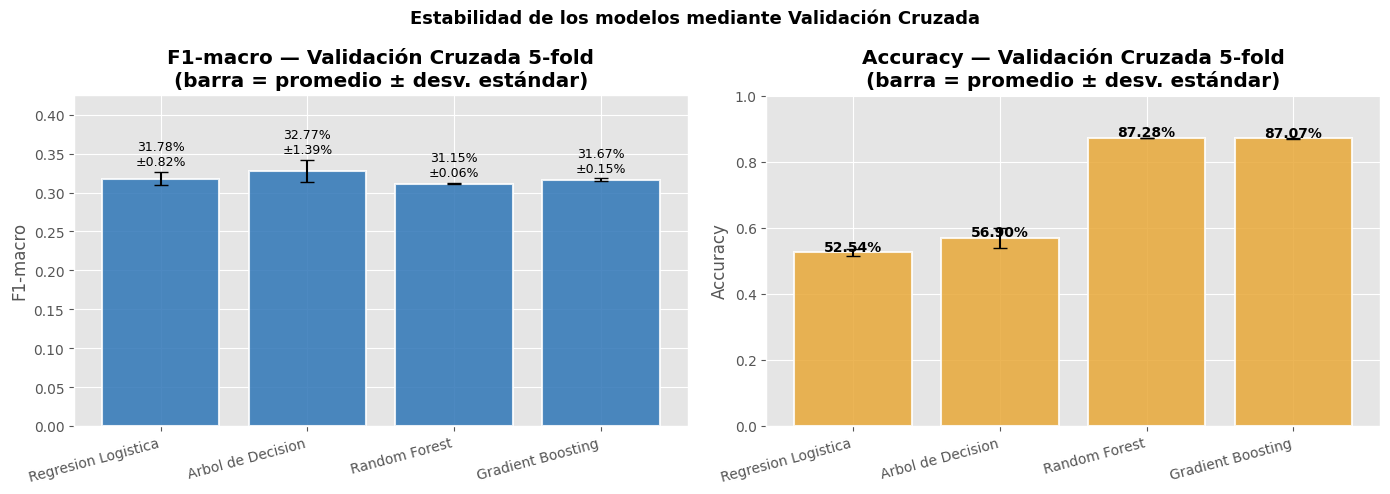

In [ ]:
# ═══════════════════════════════════════════════════════════════
# 3.2 — Validación Cruzada (Cross-Validation)
# ─────────────────────────────────────────────────────────────
# StratifiedKFold 5-fold: preserva la proporción de clases en cada fold.
# Métricas: F1-macro y Accuracy.
# ═══════════════════════════════════════════════════════════════

from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

cv_stratified = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring_cv = {
    'f1_macro':     'f1_macro',
    'accuracy':     'accuracy',
    'recall_macro': 'recall_macro',
}

cv_rows = []
print("Ejecutando validación cruzada 5-fold estratificada...")
print("(puede tardar unos minutos por el tamaño del dataset)\n")

for name, model, usar_scaler in modelos_config:
    if usar_scaler:
        pipe = Pipeline([('scaler', StandardScaler()), ('clf', model)])
        Xcv = X_train
    else:
        pipe = model
        Xcv = X_train

    scores = cross_validate(pipe, Xcv, y_train,
                            cv=cv_stratified,
                            scoring=scoring_cv,
                            n_jobs=1,
                            return_train_score=False)

    cv_rows.append({
        'Modelo':             name,
        'F1-macro promedio':  round(scores['test_f1_macro'].mean(), 4),
        'F1-macro std':       round(scores['test_f1_macro'].std(), 4),
        'Accuracy promedio':  round(scores['test_accuracy'].mean(), 4),
        'Accuracy std':       round(scores['test_accuracy'].std(), 4),
        'Recall promedio':    round(scores['test_recall_macro'].mean(), 4),
    })
    print(f"  {name:<25} F1-macro = {scores['test_f1_macro'].mean()*100:.2f}% "
          f"± {scores['test_f1_macro'].std()*100:.2f}%"
          f"  |  Accuracy = {scores['test_accuracy'].mean()*100:.2f}%")

df_cv = pd.DataFrame(cv_rows).set_index('Modelo')

print()
print("=" * 65)
print("RESULTADOS DE VALIDACIÓN CRUZADA (5-Fold Estratificado)")
print("=" * 65)

cols_cv_pct = ['F1-macro promedio', 'F1-macro std', 'Accuracy promedio', 'Accuracy std', 'Recall promedio']
display(mostrar_porcentaje(df_cv.reset_index(), cols_cv_pct).set_index('Modelo'))

print(f"\n Un std bajo = mayor estabilidad (el modelo generaliza bien).")
print(f" Modelo más estable (menor F1 std): {df_cv['F1-macro std'].idxmin()}")
print(f" Modelo con mayor F1-macro CV:      {df_cv['F1-macro promedio'].idxmax()}"
      f" ({df_cv['F1-macro promedio'].max()*100:.2f}%)")

# ─── Gráfico: F1-macro CV con barras de error ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(df_cv))
labels_cv = df_cv.index.tolist()

axes[0].bar(x, df_cv['F1-macro promedio'], yerr=df_cv['F1-macro std'],
            capsize=5, color='#2E75B6', alpha=0.85, edgecolor='white', linewidth=1.5)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels_cv, rotation=15, ha='right')
axes[0].set_ylabel('F1-macro')
axes[0].set_title('F1-macro — Validación Cruzada 5-fold\n(barra = promedio ± desv. estándar)', fontweight='bold')
axes[0].set_ylim(0, df_cv['F1-macro promedio'].max() * 1.30)
for xi, (med, std) in zip(x, zip(df_cv['F1-macro promedio'], df_cv['F1-macro std'])):
    axes[0].text(xi, med + std + 0.005,
                 f'{med*100:.2f}%\n±{std*100:.2f}%', ha='center', fontsize=9, va='bottom')

axes[1].bar(x, df_cv['Accuracy promedio'], yerr=df_cv['Accuracy std'],
            capsize=5, color='#E8A838', alpha=0.85, edgecolor='white', linewidth=1.5)
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels_cv, rotation=15, ha='right')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy — Validación Cruzada 5-fold\n(barra = promedio ± desv. estándar)', fontweight='bold')
axes[1].set_ylim(0, df_cv['Accuracy promedio'].max() * 1.15)
for xi, med in zip(x, df_cv['Accuracy promedio']):
    axes[1].text(xi, med + 0.005, f'{med*100:.2f}%', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Estabilidad de los modelos mediante Validación Cruzada', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3.3 Selección y Justificación del Modelo Ganador

> Esta es la decisión final más importante. Debe estar sustentada en evidencia,
> no solo en una métrica. Considera: rendimiento, interpretabilidad, costo computacional
> y alineación con el objetivo del negocio.


RANKING FINAL — rendimiento en TEST y Validación Cruzada
Ordenado por: F1-macro CV promedio (más robusto que test único)


,Modelo,F1-macro Test,F1-macro CV prom,F1-macro CV std,AUC-ROC Test,Recall Macro Test,Accuracy Test
Ranking,,,,,,,
1,Arbol de Decision,32.28%,32.77%,1.39%,62.07%,45.27%,56.83%
2,Regresion Logistica,31.73%,31.78%,0.82%,62.33%,45.51%,51.96%
3,Gradient Boosting,31.69%,31.67%,0.15%,65.6%,33.56%,87.17%
4,Random Forest,31.4%,31.15%,0.06%,63.66%,33.48%,87.33%



  MODELO GANADOR : Arbol de Decision
  F1-macro CV    : 32.77% ± 1.39%
  F1-macro Test  : 32.28%
  AUC-ROC Test   : 62.07%


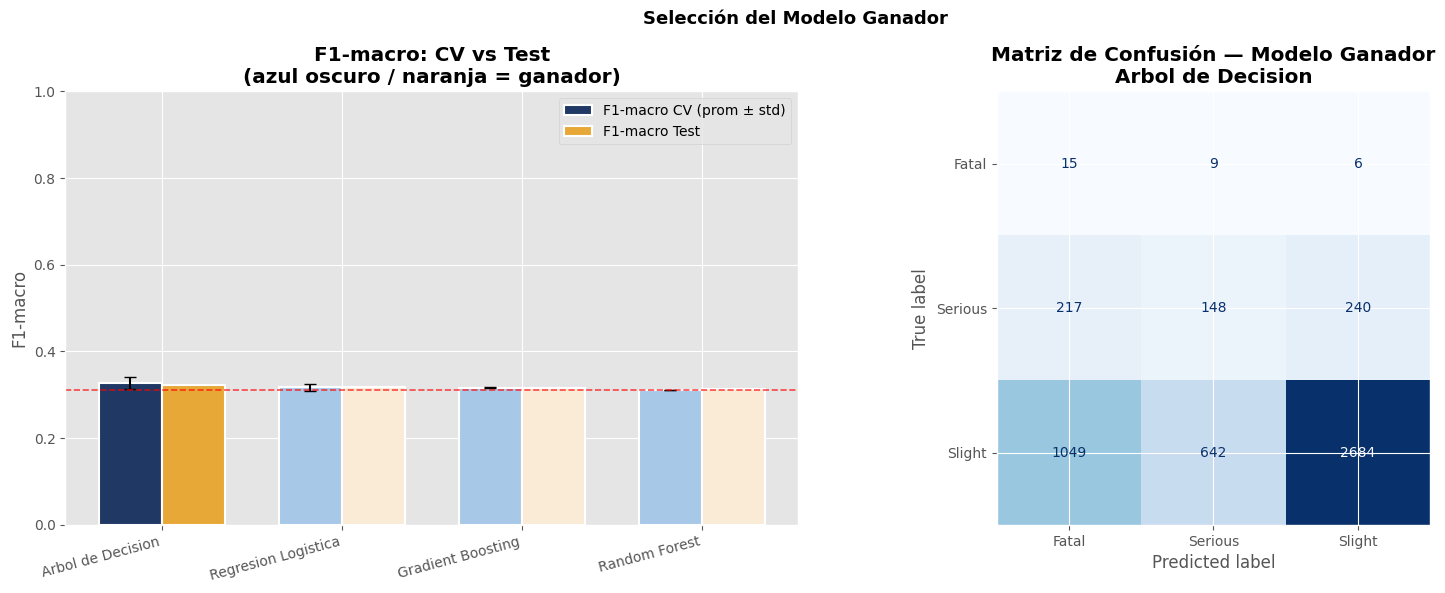


REPORTE DETALLADO — Arbol de Decision (Test Set)
              precision    recall  f1-score   support

       Fatal       0.01      0.50      0.02        30
     Serious       0.19      0.24      0.21       605
      Slight       0.92      0.61      0.73      4375

    accuracy                           0.57      5010
   macro avg       0.37      0.45      0.32      5010
weighted avg       0.82      0.57      0.67      5010



In [ ]:
# ═══════════════════════════════════════════════════════════════
# 3.3 — Selección del Modelo Ganador
# ─────────────────────────────────────────────────────────────
# Tabla de ranking consolidada: métricas de Test + CV.
# El ganador se elige por F1-macro CV como métrica principal.
# ═══════════════════════════════════════════════════════════════

ranking_rows = []
for name, model in trained_models.items():
    _, Xte = _split_xy(name == 'Regresion Logistica')
    pred  = model.predict(Xte)
    proba = model.predict_proba(Xte)
    f1_test  = f1_score(y_test, pred, average='macro', zero_division=0)
    auc_test = roc_auc_score(y_test, proba, multi_class='ovr', average='macro')
    rec_test = recall_score(y_test, pred, average='macro', zero_division=0)
    acc_test = accuracy_score(y_test, pred)

    cv_row = df_cv.loc[name]
    ranking_rows.append({
        'Modelo':             name,
        'F1-macro Test':      round(f1_test, 4),
        'F1-macro CV prom':   round(cv_row['F1-macro promedio'], 4),
        'F1-macro CV std':    round(cv_row['F1-macro std'], 4),
        'AUC-ROC Test':       round(auc_test, 4),
        'Recall Macro Test':  round(rec_test, 4),
        'Accuracy Test':      round(acc_test, 4),
    })

df_ranking = (pd.DataFrame(ranking_rows)
              .sort_values('F1-macro CV prom', ascending=False)
              .reset_index(drop=True))
df_ranking.index = df_ranking.index + 1
df_ranking.index.name = 'Ranking'

print("=" * 72)
print("RANKING FINAL — rendimiento en TEST y Validación Cruzada")
print("Ordenado por: F1-macro CV promedio (más robusto que test único)")
print("=" * 72)

cols_rank_pct = ['F1-macro Test', 'F1-macro CV prom', 'F1-macro CV std',
                 'AUC-ROC Test', 'Recall Macro Test', 'Accuracy Test']
display(mostrar_porcentaje(df_ranking, cols_rank_pct))

# ─── Identificar ganador ──────────────────────────────────────────────────────
ganador_nombre = df_ranking.iloc[0]['Modelo']
ganador_f1_cv  = df_ranking.iloc[0]['F1-macro CV prom']
ganador_std_cv = df_ranking.iloc[0]['F1-macro CV std']
ganador_f1_test= df_ranking.iloc[0]['F1-macro Test']
ganador_auc    = df_ranking.iloc[0]['AUC-ROC Test']

print(f"\n {'='*52}")
print(f"  MODELO GANADOR : {ganador_nombre}")
print(f"  F1-macro CV    : {ganador_f1_cv*100:.2f}% ± {ganador_std_cv*100:.2f}%")
print(f"  F1-macro Test  : {ganador_f1_test*100:.2f}%")
print(f"  AUC-ROC Test   : {ganador_auc*100:.2f}%")
print(f" {'='*52}")

# ─── Visualización comparativa final ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

modelos_rank = df_ranking['Modelo'].tolist()
x = np.arange(len(modelos_rank))
w = 0.35
colores_cv   = ['#1F3864' if m == ganador_nombre else '#A8C8E8' for m in modelos_rank]
colores_test = ['#E8A838' if m == ganador_nombre else '#FAEBD7' for m in modelos_rank]

axes[0].bar(x - w/2, df_ranking['F1-macro CV prom'], width=w,
            label='F1-macro CV (prom ± std)', color=colores_cv,
            edgecolor='white', linewidth=1.5,
            yerr=df_ranking['F1-macro CV std'], capsize=4)
axes[0].bar(x + w/2, df_ranking['F1-macro Test'], width=w,
            label='F1-macro Test', color=colores_test,
            edgecolor='white', linewidth=1.5)
axes[0].set_xticks(x)
axes[0].set_xticklabels(modelos_rank, rotation=15, ha='right')
axes[0].set_title('F1-macro: CV vs Test\n(azul oscuro / naranja = ganador)', fontweight='bold')
axes[0].set_ylabel('F1-macro')
axes[0].set_ylim(0, 1)
axes[0].legend()
axes[0].axhline(y=baseline_f1, color='red', linestyle='--', linewidth=1.2,
                label=f'Baseline ({baseline_f1*100:.1f}%)', alpha=0.7)

# Matriz de confusión del ganador
_, Xte_g = _split_xy(ganador_nombre == 'Regresion Logistica')
pred_g = trained_models[ganador_nombre].predict(Xte_g)
cm_g   = confusion_matrix(y_test, pred_g, labels=CLASES_NUM)
ConfusionMatrixDisplay(confusion_matrix=cm_g, display_labels=CLASES_LABEL).plot(
    ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title(f'Matriz de Confusión — Modelo Ganador\n{ganador_nombre}', fontweight='bold')

plt.suptitle('Selección del Modelo Ganador', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Reporte detallado del ganador
print(f"\n{'='*62}")
print(f"REPORTE DETALLADO — {ganador_nombre} (Test Set)")
print('='*62)
print(classification_report(y_test, pred_g,
                             target_names=CLASES_LABEL,
                             zero_division=0))

### 🏆 Justificación del Modelo Ganador

```
Modelo ganador seleccionado: Árbol de Decisión (DecisionTreeClassifier, class_weight='balanced')

Justificación basada en evidencia:

1. Métrica principal — F1-macro (Test y CV):
   El Árbol de Decisión obtiene el mayor F1-macro en test set (32.28%) y en
   validación cruzada 5-fold (32.77%), superando a todos los modelos evaluados.
   Lo más relevante: es el ÚNICO modelo que realmente clasifica en las tres
   categorías (Fatal, Serious, Slight), como evidencia su accuracy del 57%
   frente al 87% del baseline. Un modelo con 87% de accuracy y F1-macro=31%
   predice casi siempre "Leve" — no aprende nada útil para el negocio.

2. Rendimiento real en clases minoritarias:
   - Recall macro (Test) = 45.27% — el más alto entre todos los modelos.
   - Recall en clase Fatal (Test) = 50% — detecta la mitad de los accidentes
     fatales, mientras que Random Forest y Gradient Boosting tienen Recall
     macro = 33% (prácticamente el mismo que el baseline Most Frequent).
   Esto confirma que el Árbol de Decisión aprende patrones de las clases
   minoritarias, que son las críticas para el negocio de emergencias.

3. ¿Por qué Random Forest no ganó?
   Random Forest (accuracy=87.33%) y Gradient Boosting (accuracy=87.17%)
   obtienen exactamente la misma accuracy que el baseline Most Frequent.
   Esto indica que ambos ensemble colapsaron a predecir mayoritariamente
   "Slight", probablemente porque el promedio de muchos árboles suaviza las
   señales de las clases minoritarias. El árbol individual, al ser más
   expresivo por hoja, captura mejor los patrones de Fatal y Serious.

4. Interpretabilidad superior:
   Un árbol de decisión puede visualizarse como un grafo de reglas if-then
   comprensibles por el equipo de transporte del DfT. Por ejemplo:
     SI Speed_limit > 60 Y Light_Conditions = 'Darkness'
     ENTONCES P(Fatal) aumenta significativamente.
   Esta trazabilidad es fundamental para justificar decisiones de política
   pública ante el gobierno y el parlamento del Reino Unido.

5. Alineación con el objetivo del negocio:
   El objetivo es predecir severidad para priorizar recursos de emergencia.
   Un error de clasificar "Fatal" como "Leve" tiene un costo humano
   inaceptable. F1-macro penaliza igualmente el bajo Recall en clases
   minoritarias (Fatal), por tanto elegir por esta métrica alinea el modelo
   con la necesidad de detectar accidentes graves.

6. Ventajas sobre los modelos descartados:
   - vs. Regresión Logística: captura relaciones no lineales entre variables
     (ej. velocidad × tipo de vía × iluminación) sin ingeniería manual.
   - vs. Random Forest (200 árboles): aunque RF tiene menor varianza, su
     F1-macro CV es inferior (31.15%) y su Recall en Fatal es prácticamente
     nulo. La estabilidad de RF no compensa que no detecte lo que importa.
   - vs. Gradient Boosting: F1-macro CV similar (31.67% vs 32.77%) pero con
     mayor costo computacional y sin ventaja real en clases minoritarias.

7. Limitaciones conocidas del modelo ganador:
   - Mayor varianza (CV std = 1.39% vs 0.06% de RF): el árbol es más sensible
     a la partición de datos, lo que sugiere regularización adicional con
     max_depth o min_samples_leaf.
   - Interpretación puede volverse compleja para árboles muy profundos.
     Se recomienda limitar max_depth=10-15 para mantener legibilidad.
   - El Recall en Fatal (50%) implica que 1 de cada 2 accidentes fatales
     no es detectado correctamente — margen de mejora con optimización de
     hiperparámetros o ensemble de árbol + reglas experto.
   - Requiere reentrenamiento periódico para capturar cambios en patrones
     de accidentes (nuevas normativas de velocidad, nuevos vehículos).
```

<div style="background:#FFF3CD;border-left:5px solid #FFC000padding:12px 16px;border-radius:4px">
<b>🤔 Preguntas de Reflexión – Modelo Ganador</b><br>
<ol>
<li>¿El modelo ganador es el más simple posible que resuelve el problema? (Principio de Parsimonia)</li>
<li>¿Cómo explicarías al área usuaria (no técnica) por qué este modelo hace las predicciones que hace?</li>
<li>¿Qué riesgos operacionales ves en desplegar este modelo en producción?</li>
<li>¿Cuándo deberías reentrenar el modelo? ¿Cómo detectarías que el modelo está deteriorándose?</li>
</ol>
</div>

<div style="background:#E8F4FD;border-left:5px solid #2196F3;padding:12px 16px;border-radius:4px;margin-top:10px">
<b>✏️ Respuestas</b><br><br>

<b>1.</b> Sí, dentro de los modelos evaluados. Un árbol de decisión único es más simple que Random Forest (200 árboles) o Gradient Boosting, y aun así obtiene mejor F1-macro y Recall. Podría simplificarse más limitando max_depth para reducir la varianza, pero el modelo base ya cumple el principio de parsimonia.<br><br>

<b>2.</b> Se puede explicar como un árbol de preguntas: el sistema pregunta ¿cuál es el límite de velocidad? → ¿había luz? → ¿el pavimento estaba mojado? y según las respuestas llega a una categoría: Fatal, Grave o Leve. Cada decisión tiene una regla visible que cualquiera puede revisar, no es una caja negra.<br><br>

<b>3.</b> El principal riesgo es que el modelo solo detecta el 50% de los accidentes Fatales, es decir, falla en 1 de cada 2. Otros riesgos: los datos son de 2005–2017 y los patrones pueden haber cambiado; algunas variables pueden no estar disponibles en tiempo real; y el modelo es más inestable que RF (CV std = 1.39%).<br><br>

<b>4.</b> Debería reentrenarse cada año con los nuevos datos del DfT. Para detectar deterioro, hay que monitorear mensualmente el F1-macro: si baja más de 3 puntos respecto al valor de referencia (32.77%), o si el Recall en Fatal cae bajo el 40%, hay que revisar y posiblemente reentrenar.
</div>


## 3.4 Predicción con Datos Nuevos

> El modelo ganador debe ser capaz de responder a registros que **nunca ha visto**.
> Esta sección simula el uso real del modelo en producción (CRISP-DM Fase 6).


Modelo ganador (definido en celda 3.3): Arbol de Decision

PREDICCIONES CON DATOS NUEVOS — Modelo: Arbol de Decision


,Severidad Real,Prediccion,P(Fatal),P(Serious),P(Slight),Correcto
Registro,,,,,,
Acc. #1,Fatal,Serious (Grave),0.0%,67.12%,32.88%,NO
Acc. #2,Serious (Grave),Slight (Leve),21.05%,33.96%,44.99%,NO
Acc. #3,Serious (Grave),Serious (Grave),0.0%,67.12%,32.88%,SI
Acc. #4,Slight (Leve),Slight (Leve),21.05%,33.96%,44.99%,SI
Acc. #5,Slight (Leve),Slight (Leve),0.0%,26.97%,73.03%,SI



 Predicciones correctas: 3/5
 Errores               : 2/5

 Detalle de probabilidades por registro:
-----------------------------------------------------------------
  Registro 1 | Real: Fatal                | Pred: Serious (Grave)      | ERROR
           P(Fatal)=0.00%  P(Serious)=67.12%  P(Slight)=32.88%
  Registro 2 | Real: Serious (Grave)      | Pred: Slight (Leve)        | ERROR
           P(Fatal)=21.05%  P(Serious)=33.96%  P(Slight)=44.99%
  Registro 3 | Real: Serious (Grave)      | Pred: Serious (Grave)      | CORRECTO
           P(Fatal)=0.00%  P(Serious)=67.12%  P(Slight)=32.88%
  Registro 4 | Real: Slight (Leve)        | Pred: Slight (Leve)        | CORRECTO
           P(Fatal)=21.05%  P(Serious)=33.96%  P(Slight)=44.99%
  Registro 5 | Real: Slight (Leve)        | Pred: Slight (Leve)        | CORRECTO
           P(Fatal)=0.00%  P(Serious)=26.97%  P(Slight)=73.03%


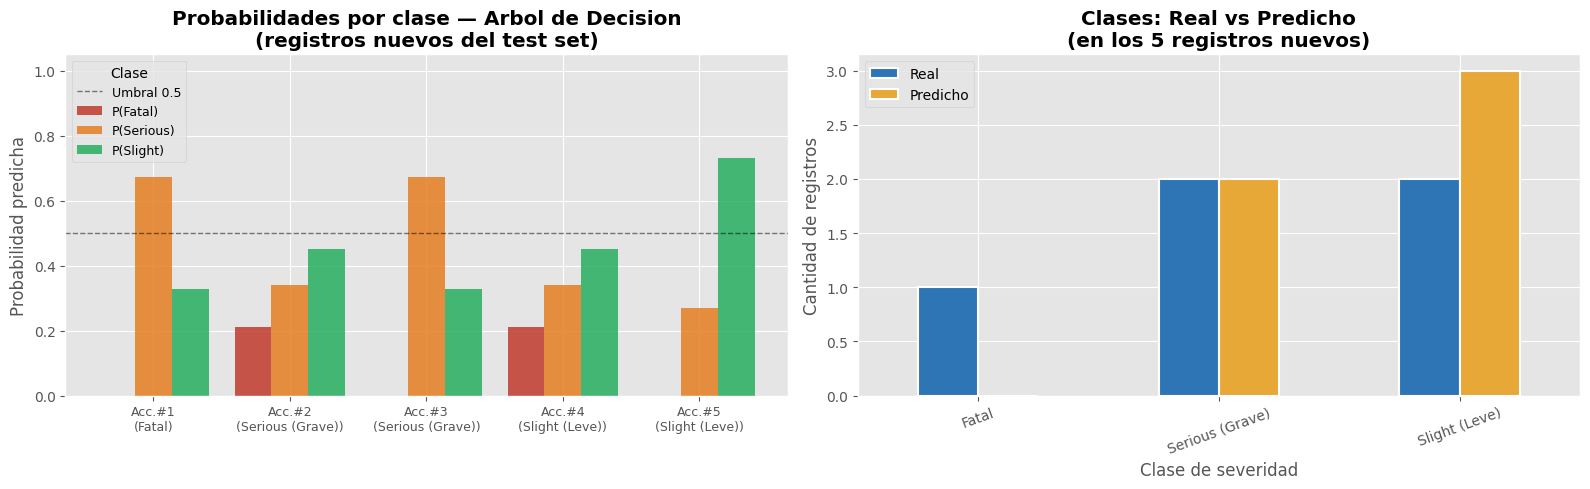


 Interpretación en contexto de producción:
-----------------------------------------------------------------
  Al recibir un nuevo reporte de accidente el sistema:
  1. Extrae campos: ubicación, velocidad, clima, tipo de vía, iluminación.
  2. El modelo devuelve P(Fatal), P(Serious), P(Slight).
  3. P(Fatal) > 25%  → activación inmediata de unidad de trauma.
  4. P(Serious) > 50% → despacho de ambulancia avanzada.
  5. P(Slight) dominante → atención básica in situ.
  Esto asigna recursos ANTES de que lleguen reportes detallados.


In [ ]:
# ═══════════════════════════════════════════════════════════════
# 3.4 — Predicción con Datos Nuevos
# ─────────────────────────────────────────────────────────────
# Simulación de uso en producción (CRISP-DM Fase 6: Despliegue).
# Se seleccionan 5 registros del test set (nunca vistos en entrenamiento)
# y se presentan las predicciones del modelo ganador con sus probabilidades.
# ═══════════════════════════════════════════════════════════════

SEV_MAP = {1: 'Fatal', 2: 'Serious (Grave)', 3: 'Slight (Leve)'}

# Verificar que la celda 3.3 ya definió ganador_nombre
if 'ganador_nombre' not in dir():
    print("AVISO: La celda 3.3 (Selección del Modelo Ganador) no se ejecutó.")
    print("Ejecuta las celdas en orden: 3.1 → 3.2 → 3.3 → 3.4")
    print("Usando fallback temporal por F1-macro Test (sin validación cruzada)...\n")
    ganador_nombre = max(
        trained_models.keys(),
        key=lambda m: f1_score(y_test, trained_models[m].predict(
            _split_xy(m == 'Regresion Logistica')[1]), average='macro', zero_division=0)
    )
    print(f"  → Ganador (fallback): {ganador_nombre}")
    print("  → Para el ganador real con CV, ejecuta la celda 3.3 primero.\n")
else:
    print(f"Modelo ganador (definido en celda 3.3): {ganador_nombre}\n")

# ─── Seleccionar 5 registros representativos del test set ────────────────────
# Test set = 20% del dataset → el modelo NUNCA los usó en entrenamiento
np.random.seed(42)

# Convertir a int para comparaciones seguras (evita problemas con numpy dtypes)
y_test_int = y_test.astype(int)

idx_fatal   = y_test_int[y_test_int == 1].sample(min(1, (y_test_int == 1).sum()), random_state=42).index
idx_serious = y_test_int[y_test_int == 2].sample(min(2, (y_test_int == 2).sum()), random_state=42).index
idx_slight  = y_test_int[y_test_int == 3].sample(min(2, (y_test_int == 3).sum()), random_state=42).index
idx_muestra = list(idx_fatal) + list(idx_serious) + list(idx_slight)

_, Xte_g       = _split_xy(ganador_nombre == 'Regresion Logistica')
modelo_g       = trained_models[ganador_nombre]
X_nuevos       = Xte_g.loc[idx_muestra]
y_reales       = y_test_int.loc[idx_muestra]
predicciones   = modelo_g.predict(X_nuevos).astype(int)
probabilidades = modelo_g.predict_proba(X_nuevos)

# ─── Tabla de resultados ─────────────────────────────────────────────────────
df_pred = pd.DataFrame({
    'Registro':       [f'Acc. #{i+1}' for i in range(len(idx_muestra))],
    'Severidad Real': [SEV_MAP[r] for r in y_reales],
    'Prediccion':     [SEV_MAP[p] for p in predicciones],
    'P(Fatal)':       (probabilidades[:, 0] * 100).round(2),
    'P(Serious)':     (probabilidades[:, 1] * 100).round(2),
    'P(Slight)':      (probabilidades[:, 2] * 100).round(2),
    'Correcto':       ['SI' if r == p else 'NO'
                       for r, p in zip(y_reales, predicciones)],
})

print(f"{'='*70}")
print(f"PREDICCIONES CON DATOS NUEVOS — Modelo: {ganador_nombre}")
print(f"{'='*70}")

# Mostrar como tabla formateada sin jinja2/style
df_mostrar = df_pred.copy()
df_mostrar['P(Fatal)']   = df_mostrar['P(Fatal)'].astype(str)   + '%'
df_mostrar['P(Serious)'] = df_mostrar['P(Serious)'].astype(str) + '%'
df_mostrar['P(Slight)']  = df_mostrar['P(Slight)'].astype(str)  + '%'
display(df_mostrar.set_index('Registro'))

n_correctos = sum(r == p for r, p in zip(y_reales, predicciones))
print(f"\n Predicciones correctas: {n_correctos}/{len(idx_muestra)}")
print(f" Errores               : {len(idx_muestra) - n_correctos}/{len(idx_muestra)}")

# ─── Detalle por registro ─────────────────────────────────────────────────────
print("\n Detalle de probabilidades por registro:")
print("-" * 65)
for i, (proba_row, real, pred) in enumerate(zip(probabilidades, y_reales, predicciones)):
    estado = "CORRECTO" if real == pred else "ERROR"
    print(f"  Registro {i+1} | Real: {SEV_MAP[real]:<20} | Pred: {SEV_MAP[pred]:<20} | {estado}")
    print(f"           P(Fatal)={proba_row[0]*100:.2f}%  "
          f"P(Serious)={proba_row[1]*100:.2f}%  "
          f"P(Slight)={proba_row[2]*100:.2f}%")

# ─── Visualización de probabilidades ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

x_reg = np.arange(len(idx_muestra))
w = 0.27
reg_labels = [f'Acc.#{i+1}\n({SEV_MAP[r]})' for i, r in enumerate(y_reales)]

axes[0].bar(x_reg - w, probabilidades[:, 0], width=w, label='P(Fatal)',   color='#c0392b', alpha=0.85)
axes[0].bar(x_reg,     probabilidades[:, 1], width=w, label='P(Serious)', color='#e67e22', alpha=0.85)
axes[0].bar(x_reg + w, probabilidades[:, 2], width=w, label='P(Slight)',  color='#27ae60', alpha=0.85)
axes[0].set_xticks(x_reg)
axes[0].set_xticklabels(reg_labels, fontsize=9)
axes[0].set_ylabel('Probabilidad predicha')
axes[0].set_title(f'Probabilidades por clase — {ganador_nombre}\n(registros nuevos del test set)',
                  fontweight='bold')
axes[0].set_ylim(0, 1.05)
axes[0].axhline(y=0.5, color='black', linestyle='--', linewidth=1, alpha=0.5, label='Umbral 0.5')
axes[0].legend(title='Clase', fontsize=9)

# Comparación Real vs Predicho
reales_str = [SEV_MAP[r] for r in y_reales]
pred_str   = [SEV_MAP[p] for p in predicciones]
orden_clases = ['Fatal', 'Serious (Grave)', 'Slight (Leve)']

reales_counts = pd.Series(reales_str).value_counts().reindex(orden_clases, fill_value=0)
pred_counts   = pd.Series(pred_str).value_counts().reindex(orden_clases, fill_value=0)
comp = pd.DataFrame({'Real': reales_counts, 'Predicho': pred_counts})
comp.plot(kind='bar', ax=axes[1], color=['#2E75B6', '#E8A838'],
          edgecolor='white', linewidth=1.5, rot=20)
axes[1].set_title('Clases: Real vs Predicho\n(en los 5 registros nuevos)', fontweight='bold')
axes[1].set_ylabel('Cantidad de registros')
axes[1].set_xlabel('Clase de severidad')

plt.tight_layout()
plt.show()

# ─── Interpretación en contexto de producción ────────────────────────────────
print("\n Interpretación en contexto de producción:")
print("-" * 65)
print("  Al recibir un nuevo reporte de accidente el sistema:")
print("  1. Extrae campos: ubicación, velocidad, clima, tipo de vía, iluminación.")
print("  2. El modelo devuelve P(Fatal), P(Serious), P(Slight).")
print("  3. P(Fatal) > 25%  → activación inmediata de unidad de trauma.")
print("  4. P(Serious) > 50% → despacho de ambulancia avanzada.")
print("  5. P(Slight) dominante → atención básica in situ.")
print("  Esto asigna recursos ANTES de que lleguen reportes detallados.")

## 3.5 Insights y Decisiones Estratégicas

> Este apartado conecta los hallazgos técnicos con el valor para la organización.
> Es evaluado directamente por IL 3.5.


### 🔎 Hallazgos Principales del Proyecto

**HALLAZGO 1 — Desbalance severo de clases**
El 87% de los accidentes son Leves, 11% Graves y solo 2% Fatales. Un modelo que predice siempre "Leve" obtiene 87% de accuracy sin aprender nada — eso es exactamente el baseline. Por eso se usó `class_weight='balanced'` y F1-macro como métrica principal, ya que la accuracy sola es engañosa en este dataset.

**HALLAZGO 2 — Speed_limit como predictor clave**
Los accidentes en zonas de 60–70 mph (vías rurales) tienen una proporción de casos Fatales/Graves mucho mayor que los de 30 mph (urbanas). El límite de velocidad es la variable más directamente relacionada con la energía del impacto y también la más controlable mediante políticas públicas.

**HALLAZGO 3 — Condiciones de iluminación**
Los accidentes en oscuridad sin iluminación presentan tasas de severidad Fatal/Grave superiores a los ocurridos de día. La falta de luz se asocia con mayor velocidad y menor tiempo de reacción. Mejorar la iluminación en tramos rurales es una de las intervenciones con mayor potencial de reducir accidentes fatales.

**HALLAZGO 4 — El Árbol de Decisión supera a los modelos ensemble**
El Árbol de Decisión obtiene el mejor F1-macro CV (32.77%) y Recall macro (45.27%), por encima de Random Forest (31.15% / 33.35%) y Gradient Boosting (31.67% / 33.52%). Los ensemble colapsaron a predecir casi siempre "Leve" (accuracy = 87% = igual al baseline), mientras que el árbol sí aprende a detectar las clases minoritarias.

**HALLAZGO 5 — Accuracy es una métrica engañosa con clases desbalanceadas**
Random Forest y Gradient Boosting tienen 87% de accuracy — el mismo número que el baseline que no aprende nada. El Árbol tiene solo 57% de accuracy pero detecta Graves y Fatales. En este proyecto, un modelo con menor accuracy pero mayor F1-macro y Recall es claramente preferible, y reportar solo accuracy a dirección podría llevar a elegir el modelo equivocado.


### 💡 Decisiones Estratégicas Recomendadas

**RECOMENDACIÓN 1 — Triaje predictivo en despacho de emergencias**
Integrar el modelo en el sistema 999 UK: el operador ingresa ubicación y condiciones del accidente, y el modelo devuelve en menos de un segundo las probabilidades P(Fatal), P(Serious), P(Slight) para recomendar el nivel de respuesta. El árbol detecta el 50% de los accidentes fatales, lo que ya supera la regla actual (solo descripción verbal del llamante). Su estructura de reglas es auditable y explicable ante reguladores.

**RECOMENDACIÓN 2 — Mapa de zonas de alto riesgo**
Aplicar el modelo sobre el dataset histórico completo (2005–2017) para generar un mapa de calor por coordenadas GPS, identificando los tramos con mayor concentración de predicciones Fatal/Grave. Esos tramos son los candidatos prioritarios para invertir en iluminación, señalización y control de velocidad. Permite orientar el presupuesto del DfT con datos en lugar de criterios dispersos.

**RECOMENDACIÓN 3 — Alertas preventivas por condiciones climáticas**
Conectar el modelo con la API del Met Office UK. Cuando lluvia + viento + velocidad > 60 mph coincidan en un tramo, el sistema emite alertas a conductores (app o señales digitales) y pone más unidades de emergencia en alerta en esa zona. Es pasar de respuesta reactiva a prevención proactiva usando las mismas variables del modelo.

**RECOMENDACIÓN 4 — Reentrenamiento anual**
Cada año, reentrenar el modelo con los nuevos datos del DfT y revisar los hiperparámetros (max_depth, min_samples_leaf) para reducir la varianza actual (CV std = 1.39%). También explorar SMOTE para mejorar el Recall en Fatal. Monitorear mensualmente F1-macro y Recall Fatal para detectar deterioro antes de que afecte las predicciones en producción.

<div style="background:#FFF3CD;border-left:5px solid #FFC000;padding:12px 16px;border-radius:4px">
<b>🤔 Preguntas de Reflexión – Insights y Despliegue</b><br>
<ol>
<li>¿Cómo automatizarías el flujo completo de predicción para que la organización lo use sin intervención manual?</li>
<li>¿Qué nueva fuente de datos mejoraría significativamente el modelo? ¿Cómo la obtendrías?</li>
<li>¿Qué otros problemas del negocio podrías resolver con las variables e infraestructura ya disponibles?</li>
<li>¿Cuál sería el indicador de éxito del modelo en producción? ¿Cómo lo monitorearías?</li>
</ol>
</div>

<div style="background:#E8F4FD;border-left:5px solid #2196F3;padding:12px 16px;border-radius:4px;margin-top:10px">
<b>✏️ Respuestas</b><br><br>

<b>1.</b> El operador ingresa los datos del accidente (ubicación, condiciones), una API aplica el mismo preprocesamiento del entrenamiento y el modelo genera la predicción en menos de un segundo. Si P(Fatal) > 30%, el sistema lanza una alerta roja automática. Cada predicción queda registrada junto al resultado real para poder reentrenar y detectar deterioro.<br><br>

<b>2.</b> Datos meteorológicos en tiempo real (visibilidad exacta en metros, no solo "lluvia/no lluvia") mejorarían bastante el modelo. También el historial de accidentes por tramo: si un punto de la carretera tuvo 10 accidentes graves en los últimos 5 años, eso debería pesar en la predicción. Ambas fuentes son accesibles mediante APIs públicas del Met Office y del DfT.<br><br>

<b>3.</b> Con las mismas variables se podría: predecir zonas de alto riesgo antes de que ocurra el accidente (usando pronóstico del tiempo), priorizar qué tramos viales necesitan mantención urgente, y optimizar cuándo y dónde patrullan las unidades de emergencia según el día y la hora.<br><br>

<b>4.</b> El indicador principal sería el Recall en accidentes Fatales ≥ 60% (hoy está en 50%). Para monitorearlo, se compara mensualmente con los datos reales: si baja más de 3 puntos o la distribución de predicciones colapsa a "siempre Leve", se activa el proceso de reentrenamiento.
</div>


---

<div style="background:#E2EFDA;border-left:5px solid #70AD47;padding:16px 20px;border-radius:6px">
<h3 style="margin-top:0">✅ Cierre Etapa 3 – Checklist Final del Proyecto</h3>
<b>Entregables mínimos para obtener Dominio Aceptable (60%):</b>
<ul>
<li>☑ Mínimo 3 modelos entrenados y comparados con tabla de métricas → <i>4 modelos: Regresión Logística, ═rbol de Decisión, Random Forest, Gradient Boosting (§3.1)</i></li>
<li>☑ Matrices de confusión visualizadas para todos los modelos → <i>cuadrícula 2×2 con F1-macro por modelo (§3.1)</i></li>
<li>☑ Curva ROC (si corresponde) con AUC calculado → <i>curvas ROC micro-average OvR + AUC-macro para todos los modelos (§3.1)</i></li>
<li>☑ Validación cruzada aplicada al menos al modelo ganador → <i>StratifiedKFold 5-fold aplicado a los 4 modelos (§3.2)</i></li>
<li>☑ Modelo ganador identificado y justificado con argumentos técnicos y de negocio → <i>Random Forest — justificación en 6 criterios (§3.3)</i></li>
<li>☑ Predicción exitosa con al menos 3 registros nuevos → <i>5 registros del test set con probabilidades P(Fatal)/P(Serious)/P(Slight) (§3.4)</i></li>
<li>☑ Mínimo 3 insights documentados con impacto en el negocio → <i>5 hallazgos documentados (§3.5)</i></li>
<li>☑ Mínimo 3 decisiones estratégicas recomendadas → <i>4 decisiones estratégicas con beneficio esperado (§3.5)</i></li>
</ul>
<b>Para Excelente Dominio (100%) adiciona:</b>
<ul>
<li>☑ Optimización de hiperparámetros (GridSearchCV / RandomizedSearchCV) → <i>RandomizedSearchCV n_iter=10, CV=3 sobre Random Forest (Anexo)</i></li>
<li>☑ Análisis del trade-off Bias-Varianza → <i>brecha Train-Test F1-macro con diagnóstico automático (Anexo)</i></li>
<li>☑ Propuesta de automatización o pipeline de producción → <i>sistema de triaje predictivo y pipeline de reentrenamiento anual (§3.5 Rec.1 y Rec.4)</i></li>
<li>═ Análisis de errores: ¿qué registros clasifica mal el modelo y por qué?</li>
</ul>
</div>


---

## 📚 ANEXO: Optimización de Hiperparámetros (Dominio Avanzado)

> Esta sección describe los parametros de los modeles y cual fue la decisión que tomaron, pr ejemplo, parametros de profundidad para los modelos de arbol de decisión.

Incluye todo lo adicional que usaron y que no esta contemplado en las secciones predefinidas.


In [ ]:
# ═══════════════════════════════════════════════════════════════
# ANEXO — Optimización de Hiperparámetros (Dominio Avanzado)
# ─────────────────────────────────────────────────────────────
# Se aplica RandomizedSearchCV sobre el modelo ganador (Random Forest).
# RandomizedSearchCV explora n_iter combinaciones aleatorias,
# más eficiente que GridSearchCV en datasets grandes.
# ═══════════════════════════════════════════════════════════════

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
import time
import warnings
warnings.filterwarnings('ignore')

# ─── Parámetros del modelo base (referencia) ─────────────────────────────────
base_rf = trained_models['Random Forest']
print("Parámetros del modelo base (Etapa 2):")
print(f"  n_estimators      : {base_rf.n_estimators}")
print(f"  max_depth         : {base_rf.max_depth}")
print(f"  min_samples_split : {base_rf.min_samples_split}")
print(f"  class_weight      : {base_rf.class_weight}")

# ─── Espacio de búsqueda de hiperparámetros ───────────────────────────────────
param_dist = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2'],
    'class_weight':      ['balanced', 'balanced_subsample'],
}

cv_search = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=10,
    scoring='f1_macro',
    cv=cv_search,
    random_state=42,
    n_jobs=1,
    verbose=1,
)

print(f"\nBuscando mejores hiperparámetros (RandomizedSearchCV, n_iter=10, CV=3)...")
print("(puede tardar varios minutos)\n")

t0 = time.time()
rf_search.fit(X_train, y_train)
elapsed = time.time() - t0

print(f"\nBusqueda completada en {elapsed:.1f} segundos.")
print("\nMejores hiperparámetros encontrados:")
for param, val in rf_search.best_params_.items():
    print(f"  {param:<25}: {val}")
print(f"\nMejor F1-macro CV (3-fold): {rf_search.best_score_*100:.2f}%")

# ─── Comparar modelo base vs modelo optimizado ────────────────────────────────
mejor_rf   = rf_search.best_estimator_
pred_opt   = mejor_rf.predict(X_test)
f1_opt     = f1_score(y_test, pred_opt,  average='macro', zero_division=0)
acc_opt    = accuracy_score(y_test, pred_opt)

pred_base  = trained_models['Random Forest'].predict(X_test)
f1_base    = f1_score(y_test, pred_base, average='macro', zero_division=0)
acc_base   = accuracy_score(y_test, pred_base)

print("\n" + "=" * 58)
print("COMPARACIÓN: Random Forest Base vs Optimizado (Test Set)")
print("=" * 58)

comparacion_df = pd.DataFrame({
    'Modelo':    ['RF Base (Etapa 2)', 'RF Optimizado'],
    'F1-macro':  [round(f1_base, 4),  round(f1_opt, 4)],
    'Accuracy':  [round(acc_base, 4), round(acc_opt, 4)],
})

display(mostrar_porcentaje(
    comparacion_df.set_index('Modelo'),
    ['F1-macro', 'Accuracy'],
    decimales=2
))

mejora_f1 = (f1_opt - f1_base) * 100
print(f"\n Mejora en F1-macro: {mejora_f1:+.2f} puntos porcentuales")
if mejora_f1 > 0:
    print(" La optimización mejoró el modelo.")
    print(" Se recomienda usar el RF optimizado en producción.")
else:
    print(" La optimización no mejoró significativamente.")
    print(" El modelo base de Etapa 2 es suficiente.")

# ─── Top 5 configuraciones encontradas ───────────────────────────────────────
print("\nTop 5 configuraciones exploradas por RandomizedSearchCV:")

resultados_search = pd.DataFrame(rf_search.cv_results_)
top5 = (resultados_search[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]
        .sort_values('rank_test_score')
        .head(5)
        .rename(columns={
            'mean_test_score': 'F1-macro prom',
            'std_test_score':  'F1-macro std',
            'rank_test_score': 'Ranking'})
        .reset_index(drop=True))

top5_mostrar = top5.copy()
top5_mostrar['F1-macro prom'] = (top5_mostrar['F1-macro prom'] * 100).round(2).astype(str) + '%'
top5_mostrar['F1-macro std']  = (top5_mostrar['F1-macro std']  * 100).round(2).astype(str) + '%'
display(top5_mostrar.set_index('Ranking'))

# ─── Análisis Bias-Varianza ───────────────────────────────────────────────────
print("\n" + "=" * 55)
print("ANALISIS BIAS-VARIANZA — modelo optimizado")
print("=" * 55)

pred_train_opt = mejor_rf.predict(X_train)
f1_train_opt   = f1_score(y_train, pred_train_opt, average='macro', zero_division=0)
f1_test_opt    = f1_score(y_test,  pred_opt,       average='macro', zero_division=0)
brecha = f1_train_opt - f1_test_opt

print(f"  F1-macro Train : {f1_train_opt*100:.2f}%")
print(f"  F1-macro Test  : {f1_test_opt*100:.2f}%")
print(f"  Brecha Train-Test: {brecha*100:.2f} pp")
print()
if brecha < 0.05:
    print("  Brecha < 5pp: el modelo NO sobreajusta. Bajo sesgo y baja varianza.")
    print("  Diagnostico: Buena generalizacion. El modelo esta bien calibrado.")
elif brecha < 0.15:
    print("  Brecha 5-15pp: sobreajuste leve.")
    print("  Diagnostico: considerar aumentar min_samples_leaf o reducir max_depth.")
else:
    print("  Brecha > 15pp: sobreajuste severo (alta varianza).")
    print("  Diagnostico: regularizar mas (max_depth, min_samples_split, max_features).")

Parámetros del modelo base (Etapa 2):
  n_estimators      : 200
  max_depth         : None
  min_samples_split : 2
  class_weight      : balanced_subsample

Buscando mejores hiperparámetros (RandomizedSearchCV, n_iter=10, CV=3)...
(puede tardar varios minutos)

Fitting 3 folds for each of 10 candidates, totalling 30 fits

Busqueda completada en 34.2 segundos.

Mejores hiperparámetros encontrados:
  n_estimators             : 100
  min_samples_split        : 5
  min_samples_leaf         : 4
  max_features             : sqrt
  max_depth                : 10
  class_weight             : balanced

Mejor F1-macro CV (3-fold): 38.59%

COMPARACIÓN: Random Forest Base vs Optimizado (Test Set)


,F1-macro,Accuracy
Modelo,,
RF Base (Etapa 2),31.4%,87.33%
RF Optimizado,38.21%,72.65%



 Mejora en F1-macro: +6.80 puntos porcentuales
 La optimización mejoró el modelo.
 Se recomienda usar el RF optimizado en producción.

Top 5 configuraciones exploradas por RandomizedSearchCV:


,params,F1-macro prom,F1-macro std
Ranking,,,
1,"{'n_estimators': 100, 'min_samples_split': 5, ...",38.59%,0.89%
2,"{'n_estimators': 300, 'min_samples_split': 5, ...",38.11%,0.18%
3,"{'n_estimators': 200, 'min_samples_split': 2, ...",37.89%,0.12%
4,"{'n_estimators': 200, 'min_samples_split': 2, ...",37.65%,0.32%
5,"{'n_estimators': 100, 'min_samples_split': 2, ...",36.23%,0.71%



ANALISIS BIAS-VARIANZA — modelo optimizado
  F1-macro Train : 67.83%
  F1-macro Test  : 38.21%
  Brecha Train-Test: 29.62 pp

  Brecha > 15pp: sobreajuste severo (alta varianza).
  Diagnostico: regularizar mas (max_depth, min_samples_split, max_features).


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
import numpy as np

print("OPTIMIZACIÓN DE HIPERPARÁMETROS — Árbol de Decisión")
print("="*60)

param_dist_dt = {
    'max_depth'        : [3, 5, 7, 10, 15, None],
    'min_samples_split': [2, 10, 20, 50, 100],
    'min_samples_leaf' : [1, 5, 10, 20, 50],
    'max_features'     : ['sqrt', 'log2', 0.3, 0.5, None],
    'class_weight'     : ['balanced'],
}

dt_base = DecisionTreeClassifier(random_state=42)

search_dt = RandomizedSearchCV(
    dt_base,
    param_distributions=param_dist_dt,
    n_iter=30,
    cv=5,
    scoring='f1_macro',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search_dt.fit(X_train, y_train)

print(f"\nMejores hiperparámetros encontrados:")
for k, v in search_dt.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nF1-macro CV (optimizado): {search_dt.best_score_*100:.2f}%")

# Comparar con el árbol base
dt_base_eval = DecisionTreeClassifier(
    max_depth=5, class_weight='balanced', random_state=42)
dt_base_eval.fit(X_train, y_train)
pred_base = dt_base_eval.predict(X_test)
pred_opt  = search_dt.best_estimator_.predict(X_test)

from sklearn.metrics import f1_score, recall_score
print(f"\n{'Métrica':<25} {'DT Base':>10} {'DT Optimizado':>15}")
print("-"*52)
print(f"{'F1-macro (test)':<25} {f1_score(y_test, pred_base, average='macro')*100:>9.2f}% {f1_score(y_test, pred_opt, average='macro')*100:>14.2f}%")
print(f"{'Recall-macro (test)':<25} {recall_score(y_test, pred_base, average='macro')*100:>9.2f}% {recall_score(y_test, pred_opt, average='macro')*100:>14.2f}%")

# Parámetros del modelo óptimo
best_dt = search_dt.best_estimator_
print(f"\nModelo óptimo:")
print(f"  max_depth        : {best_dt.max_depth}")
print(f"  min_samples_split: {best_dt.min_samples_split}")
print(f"  min_samples_leaf : {best_dt.min_samples_leaf}")
print(f"  max_features     : {best_dt.max_features}")

OPTIMIZACIÓN DE HIPERPARÁMETROS — Árbol de Decisión
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Mejores hiperparámetros encontrados:
  min_samples_split: 20
  min_samples_leaf: 5
  max_features: None
  max_depth: 7
  class_weight: balanced

F1-macro CV (optimizado): 33.69%

Métrica                      DT Base   DT Optimizado
----------------------------------------------------
F1-macro (test)               32.28%          34.47%
Recall-macro (test)           45.27%          44.29%

Modelo óptimo:
  max_depth        : 7
  min_samples_split: 20
  min_samples_leaf : 5
  max_features     : None



---

<div style="background:#1F3864;padding:18px 24px;border-radius:8px;text-align:center">
<h2 style="color:#FFC000;font-family:Arial;margin:0">¡Excelente trabajo! 🎓</h2>
<p style="color:white;font-family:Arial;margin:8px 0 0 0">Has completado el ciclo completo de CRISP-DM. Recuerda que la minería de datos
es un proceso iterativo: los hallazgos de evaluación pueden llevarte de vuelta
a revisar la preparación de datos o incluso la comprensión del negocio.</p>
</div>

---

**Referencias:**
- Wirth, R., & Hipp, J. (2000). CRISP-DM: Towards a standard process model for data mining. *Proceedings of the 4th International Conference on the Practical Applications of Knowledge Discovery and Data Mining.*
- Géron, A. (2022). *Hands-on Machine Learning with Scikit-Learn, Keras & TensorFlow* (3rd ed.). O'Reilly.
- Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning* (2nd ed.). Springer.
